In [1]:
#import user modules
#--- MATPLOTLIB
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.markers import MarkerStyle
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd

import sys
my_path = "../../Python/"
if my_path not in sys.path:
    sys.path.append(my_path)
 
for place in sys.path: 
    print(place)

from fit_funcs import *
from entropy import *

import costfun.costfun as cost
import utils.figures as fig_help
import utils.tools as tools
from RandomMatrixTheory import goe
from tools import *

import importlib as imp
def reload_modules():
    imp.reload(cost)
    imp.reload(fig_help)

import itertools
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
latex_engine = 'xelatex'
latex_elements = {'preamble':r'\usepackage{physics}'}

%matplotlib inline
colors_ls = (list(mcolors.TABLEAU_COLORS)[:200])
colors_ls_cyc = itertools.cycle(colors_ls)

markers_ls = ['o','s','v', 'D', '<', 'X', '^', '*', '+']
markers = itertools.cycle(markers_ls)

#--- NUMERICAL LIBS
import numpy as np
import itertools
import math
import random
from cmath import nan
import h5py   


# SCIPY LIBS
import scipy.stats as statistics
from scipy.special import binom
from scipy.special import erfinv
from scipy.special import erf
from scipy.special import digamma
from scipy.special import polygamma
from scipy.special import gamma as gamma_fun
from scipy.special import lambertw
from scipy.special import voigt_profile
from scipy.optimize import curve_fit as fit
from scipy.signal import savgol_filter
from scipy import integrate
from scipy import fft
from scipy.interpolate import UnivariateSpline as InterpolateSpline
from scipy.interpolate import make_interp_spline as make_spline
from scipy.interpolate import splrep, splev
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import FancyArrowPatch

# OTHER
import warnings
warnings.filterwarnings('ignore')
from joblib import Parallel, delayed
import copy
import os
from os import sep as kPSep
from os.path import exists

DIM = 1
modello = 'RP'


def base_dir(model, d, BC = 0):
    """
    Base directory for input model for d-dimension
    """
    dirx = f"../results/{model}/" + (f"" if model == 'PLRB' or model == 'RP' else  f"dim={d}/") + ( '' if model == 'RP' else (f"PBC/" if BC else f"OBC/") )
    return dirx

print(base_dir(modello, DIM))
%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}

/Users/rafal.swietek/Projects/CODES/QHamSolver/XXZ/Jupyter_Python
/Users/rafal.swietek/opt/anaconda3/lib/python39.zip
/Users/rafal.swietek/opt/anaconda3/lib/python3.9
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/lib-dynload

/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/aeosa
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/locket-0.2.1-py3.9.egg
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/IPython/extensions
/Users/rafal.swietek/.ipython
../../Python/
../results/RP/


### saver of test data

In [216]:
#!/usr/bin/python -u

#--- MATPLOTLIB
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.markers import MarkerStyle
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd

import sys
my_path = "../../Python/"
if my_path not in sys.path:
    sys.path.append(my_path)
 
for place in sys.path: 
    print(place)

import costfun.costfun as cost
import utils.figures as fig_help
import utils.tools as tools
from tools import *

import importlib as imp
def reload_modules():
    imp.reload(cost)
    imp.reload(fig_help)

import itertools
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
latex_engine = 'xelatex'
latex_elements = {'preamble':r'\usepackage{physics}'}

colors_ls = (list(mcolors.TABLEAU_COLORS)[:120])
colors_ls_cyc = itertools.cycle(colors_ls)
markers_ls = ['o','s','v', 'D', '<', 'X', '^', '*', '+']
markers = itertools.cycle(markers_ls)

#--- NUMERICAL LIBS
import numpy as np
import itertools
import math
import random
from cmath import nan
import h5py   


# SCIPY LIBS
import scipy.stats as statistics
from scipy.special import binom
from scipy.special import erfinv
from scipy.special import digamma
from scipy.special import polygamma
from scipy.special import lambertw
from scipy.optimize import curve_fit as fit
from scipy.signal import savgol_filter
from scipy import integrate
from scipy import fft
 
# OTHER
import warnings
warnings.filterwarnings('ignore')
from joblib import Parallel, delayed
import copy
import os
from os import sep as kPSep
from os.path import exists



from joblib import Parallel, delayed


if __name__ == '__main__':
    modello = 'RP'
    L = 20
    wx = 0.7
    J1 = 1
    delta1=0.55
    BC = 0
    hz = 0.0

    BC = 0

    prefix = '../results/disorder/OBC/Spectrals_SzSz/' if BC else '../results/disorder/PBC/Spectrals_SzSz/'
    # prefix_out = '../results/disorder/OBC/Spectrals_SzSz_test/' if BC else '../results/disorder/PBC/Spectrals_SzSz_test/'
    # prefix = '../results/disorder/OBC/Spectrals_energy_current/'
    prefix = '../results_fgr2/disorder/PBC/energy_current/'
    # prefix = '../results_fgr/disorder/ABC/Spectrals_kinetic/'
    # hz = 1 if BC else 0

    DIM = 1
    num_realis = 100
    
    L = 12
    sizes = np.arange(10, 13, 2)
    
    nuus = np.array([500, 0.1, 0.25, 0.5, 1.0])
    
    depsilon = 0.1
    energy_density = np.arange(0.05, 0.95, 0.04)
    # print(sizes, alfa_vals, energy_density)

    def loop_body(L, wx):
        dim = int( binom(L, L // 2) ) if L < 20 else 500

        num = min([1000, dim//5]) if L < 20 else 500
        E = np.zeros((dim))
        S = np.zeros((L + 1, num))
        S_site = np.zeros((L + 1, num))
        S_info = np.zeros((num))


        gap_ratios = np.zeros((dim-2))
        weight_ratios = np.zeros((dim-2))
        sites = np.zeros((L))
        
        omegax = np.zeros( (10 * (L)) )
        energy_density = np.arange(0.05, 0.95, 0.02)
        bins = np.arange(0.04, 0.95, 0.02)
        spec_fun = np.zeros( (energy_density.size, omegax.size-1) )
        spec_fun_typ = np.zeros( (energy_density.size, omegax.size-1) )
        element_count = np.zeros( (energy_density.size, omegax.size-1) )
        int_spec_fun = np.zeros( (energy_density.size, omegax.size-1) )
        
        wx = np.round(wx, 6)
        
        DOS          = np.zeros( (energy_density.size) )
        count        = np.zeros( (energy_density.size) )
        count_typ    = np.zeros( (energy_density.size) )
        susc_E       = np.zeros( (energy_density.size) )
        susc_E_r     = np.zeros( (energy_density.size) )
        susc_E_typ   = np.zeros( (energy_density.size) )
        susc_E_r_typ = np.zeros( (energy_density.size) )
        
        gaps_dens   = np.zeros((energy_density.size))
       	weight_dens = np.zeros((energy_density.size))
        wH_dens     = np.zeros((energy_density.size))
        wH_typ_dens = np.zeros((energy_density.size))
        
        susc = np.zeros((dim))
        susc_r = np.zeros((dim))
        average_energies = np.zeros((dim))
        average_energy_densities = np.zeros((dim))
        tot_spin = np.zeros((dim))
        tot_spin_var = np.zeros((dim))
        diag_mat_av = np.zeros((dim))
        diag_mat_var = np.zeros((dim))
        
        
        fractions = np.array( [0.05, 0.1, 0.2, 0.5, 1] )
        wH_frac    = np.zeros(fractions.shape)
        wH_typ_frac= np.zeros(fractions.shape)
        SUSC       = np.zeros(fractions.shape)
        SUSC_R     = np.zeros(fractions.shape)
        TYP_SUSC   = np.zeros(fractions.shape)
        TYP_SUSC_R = np.zeros(fractions.shape)
        e_to_e_fluct = np.zeros(fractions.shape)
        e_to_e_outlier = np.zeros(fractions.shape)
        
        times = np.zeros((5000))
        quench = np.zeros((5000))
        autocorr = np.zeros((5000))

        print( prefix + info_dis(L=L, J1=J1, delta1=delta1, w=wx), flush=True )
        counter = 0
        energy = []
        stddev = []
        bandwidth = []
        realizations = []
        quenchE = []
        E_gap = []
        level_spacing = []
        HSnorm = 0

        DE = 0; DE_abs = 0;
        MC = 0; MC_abs = 0;
        deltaQ = 0;
        temporal_fluct = 0;

        for real in range(num_realis):
            name = prefix + 'realisation=%d/'%real + info_dis(L=L, J1=J1, delta1=delta1, w=wx, hz=hz) + '.hdf5'
            if exists(name):
                try:
                    with h5py.File(name, "r") as file:
                        # CHECK IF ALL DATA IN FILE
                        _var_names = ['energy_density', 'omegas', 'spectral_fun', 'log(_spectral_fun_typ)', 'element_count', 'susc', 'energies', 'susc_reg']
                        for _name_var in _var_names:
                            _name_var_funt = _name_var;
                            xx = np.array(file.get(_name_var)[0])

                        # REGULAR AGP NORMS
                        _susc   = np.array(file.get('susc')[0])
                        _susc_r = np.array(file.get('susc_reg')[0])
#                        print(_susc.size, dim, num)
                        if _susc.size != dim:
                            continue;

                        energy_density = np.array(file.get('energy_density')[0])
                        
                        omegax = np.array(file.get('omegas')[0])
                        spec_fun += np.array(file.get('spectral_fun'))
                        int_spec_fun += np.array(file.get('integrated_spectral_fun'))
                        spec_fun_typ += np.array(file.get('log(_spectral_fun_typ)'))
                        element_count += np.array(file.get('element_count'))
                        counter += 1
                        
                        realizations.append(real)
                            
                        E = np.array(file.get('energies')[0])
                        E_gap.append(E[1] - E[0])

                        permut = np.argsort( np.array(E) )
                        E = E[permut]
                        #print(np.array(file.get('entropy')).shape)
                        # if BC:
                        #     S += np.array(file.get('entropy'))
                        #     S_site += np.array(file.get('single_site_entropy'))
                        #     S_info += np.array(file.get('von Neumann participation entropy')[0])

                        gaps = np.diff(E)
                        dim = E.size
                        E_av = np.mean(E)
                        idx = np.argmin( np.abs(E - E_av) )
                        if len(level_spacing) + dim < 536870910:
                            level_spacing = [*level_spacing, *gaps]


                        dE = E[-1] - E[0]
                        Ex = (E - E[0]) / dE
                        energy = [*energy, *Ex]
                        
                        bandwidth.append(dE)
                        stddev.append(np.std(E))
                        average_energies += E
                        average_energy_densities += Ex
                        
                        # TIME DYNAMICS
                        _diag_mat = np.array(file.get('diag_mat'))[0]
                        Cn = np.abs( np.array(file.get('coefficients'), dtype=complex)[0] ) if L < 20 else np.zeros((dim))
                        x = np.sum( np.abs(Cn)**2 * _diag_mat )
                        DE += x
                        DE_abs += np.abs(x)


                        diag_mat_av += _diag_mat
                        diag_mat_var += _diag_mat**2

                        idx1 = np.argmin( np.abs(E - (E_av - 0.05)) )
                        idx2 = np.argmin( np.abs(E - (E_av + 0.05)) )
                        y = np.mean(_diag_mat[idx1 : idx2])
                        MC += y
                        MC_abs += np.abs(y)
                        deltaQ += np.abs(x - y)

                        tot_spin_init = np.array(file.get('tot_spin_init'))[0]
                        # HSnorm = np.array(file.get('HSnorm'))[0]
                        quenchE.append( np.array(file.get('quench_energy'))[0] )

                        times = np.array(file.get('times'))[0]
                        Q = np.array(file.get('quench'))[0] if L < 20 else np.zeros((5000))
                        temporal_fluct += tools.get_fluctuations(Q * Q[0], bucket_size=50)**2
                        quench += np.abs(Q)
                        autocorr += tot_spin_init * Q

                        abcd = np.sqrt(1 + 4 * _diag_mat * np.sqrt(HSnorm)) / 2. - 0.5
                        tot_spin += abcd
                        tot_spin_var += abcd**2

                        # REGULAR AGP NORMS
                        _susc   = np.array(file.get('susc')[0])
                        _susc_r = np.array(file.get('susc_reg')[0])
                        susc   += _susc
                        susc_r += _susc_r
                        for iif, frac in enumerate(fractions):
                            my_min = idx - int(frac * dim / 2)
                            if my_min < 0 or frac > 0.99: my_min = 0
                            
                            my_max = idx + int(frac * dim / 2)
                            if my_max >= dim or frac > 0.99: my_max = dim-1

                            wH_frac[iif] += np.mean( gaps[my_min : my_max] if frac < 1 else gaps)
                            wH_typ_frac[iif] += np.exp( np.mean( np.log(gaps[my_min : my_max] if frac < 1 else gaps) ))
                            SUSC[iif] += np.mean( _susc[my_min : my_max] if frac < 1 else _susc)
                            SUSC_R[iif] += np.mean( _susc_r[my_min : my_max] if frac < 1 else _susc_r)
                            TYP_SUSC[iif] += np.exp(np.mean( np.log(_susc[my_min : my_max] if frac < 1 else _susc[1:]) ))
                            TYP_SUSC_R[iif] += np.exp(np.mean( np.log(_susc_r[my_min : my_max] if frac < 1 else _susc_r[1:]) ))

                            e_to_e_fluct[iif] += np.mean( np.abs(np.diff( _diag_mat[my_min : my_max] if frac < 1 else _diag_mat )) )
                            e_to_e_outlier[iif] += np.max( np.abs(np.diff(_diag_mat[my_min : my_max] if frac < 1 else _diag_mat )) )


                        # SPECTRAL STATISTICS
                        ratio_tmp = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
                        gap_ratios += ratio_tmp

                        weight_ratio_tmp = np.log(1 + np.exp( np.diff(np.log(gaps)) ) )
                        weight_ratios += weight_ratio_tmp

                        # AGP FINITE ENERGY DENSITY
                        for ii, epsx in enumerate(energy_density):
                            eps = epsx * dE + E[0]
                            idx1 = np.argmin( np.abs(E - (eps - depsilon)) )
                            idx2 = np.argmin( np.abs(E - (eps + depsilon)) )
                            if idx2 - idx1 < 2:
                                idx1 -= 5
                                idx2 += 5
                            if idx1 < 0:     idx1 = 0
                            if idx2 > dim-1: idx2 = dim
                            count[ii]        += idx2 - idx1
                            count_typ[ii]    += np.log(idx2 - idx1)
                            susc_E[ii]       += np.mean( _susc[idx1 : idx2])
                            susc_E_r[ii]     += np.mean( _susc_r[idx1 : idx2])
                            susc_E_typ[ii]   += np.exp( np.mean( np.log(_susc[idx1 : idx2]) ) )
                            susc_E_r_typ[ii] += np.exp( np.mean( np.log(_susc_r[idx1 : idx2]) ) )

                            weight_dens[ii]    += np.mean(weight_ratio_tmp[idx1 : min(idx2, len(weight_ratio_tmp)) ])
                            gaps_dens[ii]    += np.mean(ratio_tmp[idx1 : min(idx2, len(ratio_tmp)) ])
                            wH_dens[ii]      += np.mean(gaps[idx1 : min(idx2, len(gaps)) ])
                            wH_typ_dens[ii]  += np.exp( np.mean( np.log(gaps[idx1 : min(idx2, len(gaps)) ]) ))
                        

                except (OSError, TypeError) as e:
                    print("FAILED AT: ", _name_var_funt, "\tCorrupted file!", name, flush=True)
                    print("\t\tERROR", e, flush=True)

        # DENSITY OF STATES
        DOS, _ = np.histogram( np.array(energy), bins = bins, density=True)
        DOS = DOS * dim

        lvl_spacing, lvl_spacing_bins = np.histogram( np.array(level_spacing), bins = 250, density=True)
        lvl_spacing_log, lvl_spacing_bins_log = np.histogram( np.log(np.array(level_spacing)), bins = 250, density=True)
        print(L, wx, counter, flush=True)
        if counter > 0:
            name = prefix + info_dis(L=L, J1=J1, delta1=delta1, w=wx, hz=hz) + '.hdf5'
            stddev = np.array(stddev)
            bandwidth = np.array(bandwidth)
            E_gap = np.array(E_gap)

            hf = h5py.File(name, 'w')
            hf['depsilon'] = depsilon
            hf['realisations'] = counter
            hf['diagonal ensemble'] = DE / counter
            hf['diagonal ensemble abs'] = DE_abs / counter
            hf['microcanonical ensemble'] = MC / counter
            hf['microcanonical ensemble abs'] = MC_abs / counter
            hf['deltaQ'] = deltaQ / counter
            # hf['HSnorm'] = HSnorm


            
            hf.create_dataset('fractions', fractions.shape, data = fractions)
            hf.create_dataset('wH', wH_frac.shape, data = wH_frac / counter)
            hf.create_dataset('wH_typ', wH_typ_frac.shape, data = wH_typ_frac / counter)
            
            hf.create_dataset('SUSC', SUSC.shape, data = SUSC / counter)
            hf.create_dataset('SUSC_R', SUSC_R.shape, data = SUSC_R / counter)
            hf.create_dataset('TYP_SUSC', TYP_SUSC.shape, data = TYP_SUSC / counter)
            hf.create_dataset('TYP_SUSC_R', TYP_SUSC_R.shape, data = TYP_SUSC_R / counter)
            hf.create_dataset('e_to_e_fluct', e_to_e_fluct.shape, data = e_to_e_fluct / counter)
            hf.create_dataset('e_to_e_outlier', e_to_e_outlier.shape, data = e_to_e_outlier / counter)
            
            hf.create_dataset('stddev', stddev.shape, data = stddev)
            hf.create_dataset('bandwidth', bandwidth.shape, data = bandwidth)
            hf.create_dataset('E_gap', E_gap.shape, data = E_gap)
            
            hf.create_dataset('susc', susc.shape, data = susc)
            hf.create_dataset('susc_r', susc_r.shape, data = susc_r)
            hf.create_dataset('average energies', average_energies.shape, data = average_energies / counter)
            hf.create_dataset('average energy density', average_energy_densities.shape, data = average_energy_densities / counter)
            hf.create_dataset('total spin', tot_spin.shape, data = tot_spin / counter)
            hf.create_dataset('total spin variance', tot_spin.shape, data = tot_spin_var / counter - (tot_spin / counter)**2 )
            hf.create_dataset('gap_ratios', gap_ratios.shape, data = gap_ratios / counter)
            hf.create_dataset('weight_ratios', weight_ratios.shape, data = weight_ratios / counter)

            hf.create_dataset('diag_mat', diag_mat_av.shape, data = diag_mat_av / counter)
            hf.create_dataset('diag_mat variance', diag_mat_var.shape, data = diag_mat_var / counter - (diag_mat_av / counter)**2 )
            

            hf.create_dataset('lvl_spacing/dist', lvl_spacing.shape,              data = lvl_spacing)
            hf.create_dataset('lvl_spacing/bins', lvl_spacing_bins.shape,         data = lvl_spacing_bins)
            hf.create_dataset('lvl_spacing/dist_log', lvl_spacing_log.shape,      data = lvl_spacing_log)
            hf.create_dataset('lvl_spacing/bins_log', lvl_spacing_bins_log.shape, data = lvl_spacing_bins_log)

            hf.create_dataset('DOS', 	        DOS.shape, 	          data = DOS)
            hf.create_dataset('count', 	        count.shape, 	      data = count)
            hf.create_dataset('count_typ', 	    count_typ.shape, 	  data = np.exp(count_typ / counter))
            hf.create_dataset('susc_E', 	    susc_E.shape, 	      data = susc_E)
            hf.create_dataset('susc_E_r', 	    susc_E_r.shape, 	  data = susc_E_r)
            hf.create_dataset('susc_E_typ', 	susc_E_typ.shape, 	  data = susc_E_typ)
            hf.create_dataset('susc_E_r_typ', 	susc_E_r_typ.shape,   data = susc_E_r_typ)
            hf.create_dataset('energy_density', energy_density.shape, data = energy_density)
            
            hf.create_dataset('weight_density', weight_dens.shape, data = weight_dens / counter)
            hf.create_dataset('gap_ratio_density', gaps_dens.shape, data = gaps_dens / counter)
            hf.create_dataset('wH_density',        wH_dens.shape,   data = wH_dens / counter)
            hf.create_dataset('wH_typ_density',    wH_typ_dens.shape,   data = wH_typ_dens / counter)
            
            hf.create_dataset('omegas', 	   omegax.shape, data = omegax)
            hf.create_dataset('element_count', element_count.shape, data = element_count)
            hf.create_dataset('spec_fun',      spec_fun.shape, data = spec_fun / element_count)
            hf.create_dataset('int_spec_fun',  int_spec_fun.shape, data = int_spec_fun / counter)
            hf.create_dataset('spec_fun_typ',  spec_fun_typ.shape, data = np.exp(spec_fun_typ / element_count))

            # hf.create_dataset('times',    times.shape,   data = times)
            # hf.create_dataset('quench',    quench.shape,   data = quench / counter)
            # hf.create_dataset('autocorr',   autocorr.shape,   data = autocorr / counter)
            # hf.create_dataset('temporal fluctuations', temporal_fluct.shape, data = temporal_fluct / counter)

            hf.create_dataset('entropies', S.shape, data = S / counter)
            hf.create_dataset('single_site_entropy', S_site.shape, data = S_site / counter)
            hf.create_dataset('von Neumann participation entropy', S_info.shape, data = S_info / counter)

            hf.close()

    L=10
    wx = 0.0
    # for L in [8, 10, 12]:
    #     loop_body(L, wx)
    for wx in np.arange(0.35, 0.76, 0.05):
        loop_body(L, wx)
    # for L in sizes:
    #     Parallel(n_jobs=alfa_vals.size)(delayed(loop_body)(L, alfa) for alfa in alfa_vals)

/Users/rafal.swietek/Projects/CODES/QHamSolver/XXZ/Jupyter_Python
/Users/rafal.swietek/opt/anaconda3/lib/python39.zip
/Users/rafal.swietek/opt/anaconda3/lib/python3.9
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/lib-dynload

/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/aeosa
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/locket-0.2.1-py3.9.egg
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/IPython/extensions
/Users/rafal.swietek/.ipython
../../Python/
../results_fgr2/disorder/PBC/energy_current/_L=10,J1=1,J2=0,d1=0.55,d2=0,hz=0,w=0.35,pb=0
10 0.35 100
../results_fgr2/disorder/PBC/energy_current/_L=10,J1=1,J2=0,d1=0.55,d2=0,hz=0,w=0.4,pb=0
10 0.4 100
../results_fgr2/disorder/PBC/energy_current/_L=10,J1=1,J2=0,d1=0.55,d2=0,hz=0,w=0.45,pb=0
10 0.45 100
../results_fgr2/disorder/PBC/energy_current/_L=10,J1=1,J2=0,d1=0.55,d2=0,hz=0,w=0.5,pb=0
10 0.5 100
../results_fgr2/disorde

## TESTIES

In [ ]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 12
w = 2
J = 1
delta=0.55
op=0
wx=0.2

RESCALE = 0
BC = 1
use_gap_or_weight = 1

prefix = '../results_fgr/disorder/OBC/Spectrals_SzSz/'

for r in range(10):
    name = prefix + 'realisation=%d/'%r + info_dis(L=L, J1=J, delta1=delta, w=wx, hz=hz) + '.hdf5'
    if exists(name):
        with h5py.File(name, "r") as file:
            E = np.array(file.get('E0'))[0]
            _, indices, counts = np.unique(np.round(E, 14), return_index=True, return_counts=True)
            # if (E[counts>1]).size > 0:
            # print( )
            gaps = np.diff(E)
            ratio_tmp = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
            print(r, E[ indices[counts>1]], np.mean(ratio_tmp))
    else:
        print(name)
            

0 [] 0.3846595484046128
1 [] 0.3846595484046128
2 [] 0.3846595484046128
3 [] 0.3846595484046128
4 [] 0.3846595484046128
5 [] 0.3846595484046128
6 [] 0.3846595484046128
7 [] 0.3846595484046128
8 [] 0.3846595484046128
9 [] 0.3846595484046128


No handles with labels found to put in legend.


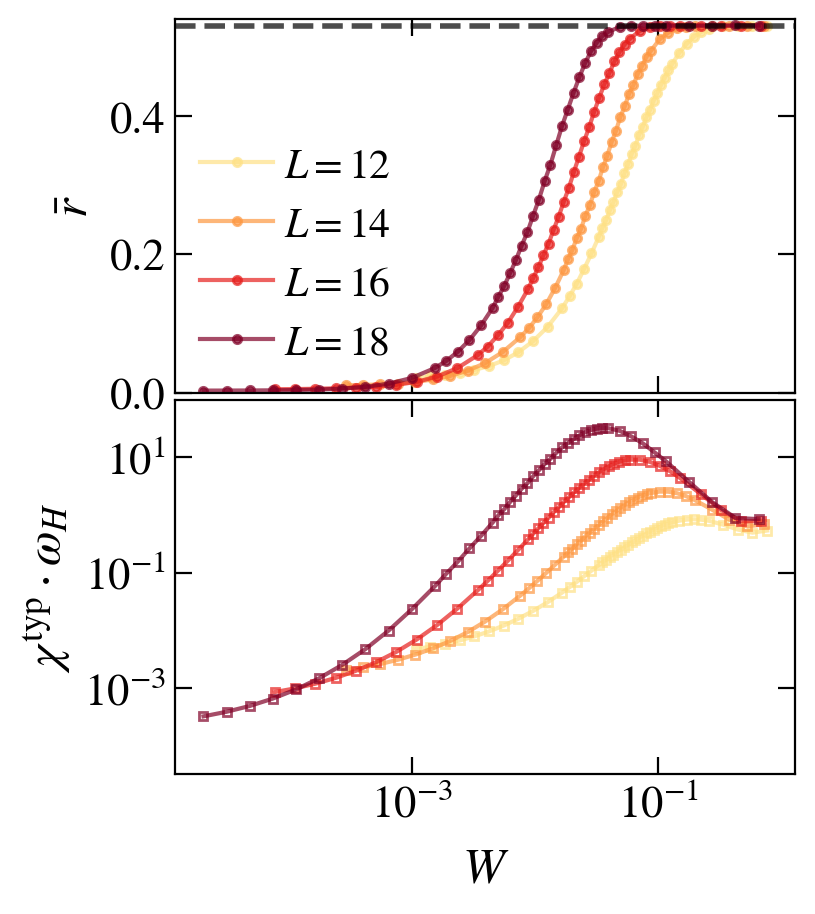

In [10]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
delta=0.55
op=0
hz=0

ADD_CURRENT = 0
RESCALE = 1
BC = 0
use_gap_or_weight = 1

prefix = '../results_fgr/disorder/OBC/Spectrals_SzSz/' if BC else '../results_fgr_D/disorder/PBC/Spectrals_SzSz/'
# prefix = '../results_fgr/disorder/ABC/Spectrals_kinetic/'
if ADD_CURRENT: prefix = '../results_fgr/disorder/PBC/Spectrals_SzSz/'


sizes = np.arange(12, 17 if ADD_CURRENT else 19, 2)

DIM = 1
fig, axis = plt.subplots( nrows=2, ncols=1, figsize=(4,5), dpi = 200, sharex=True, sharey=False)

L = 15
eps = 0.5

wx_vals2 = np.arange(0.04, 0.81, 0.04) if BC else np.sort( np.array([*np.arange(0.04, 1.01, 0.04), *np.arange(0.22, 0.61, 0.04), *np.arange(0.31, 0.51, 0.02)]) )
# wx_vals2 = np.array([*np.arange(-0.25, -0.01, 0.05), *np.arange(0.0, 0.76, 0.05)])
# if ADD_CURRENT: 
# wx_vals2 = np.arange(0.02, 0.81, 0.02)

norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.2, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])

r_cut = 0.515 if use_gap_or_weight else 0.18
if ADD_CURRENT: r_cut = 0.592

agp_max_yax = np.zeros(sizes.shape)
agp_max = np.zeros(sizes.shape)
r_drift = np.zeros(sizes.shape)
AGPs = []
for iiL, L in enumerate(sizes):
    dim = int( binom(L, L//2) )

    col = s_m.to_rgba(L)
    wx_vals = wx_vals2
    gap_ratio = np.zeros(wx_vals.shape);    gap_ratio.fill(np.nan);
    agp = np.zeros(wx_vals.shape);    agp.fill(np.nan);
    realis = np.zeros(wx_vals.shape);    realis.fill(np.nan);
    
    sigma_num = np.zeros(wx_vals.shape)
    for iiw, wx in enumerate(wx_vals):
        
        name = prefix + info_dis(L=L, J1=J, delta1=delta, w=wx, hz=hz) + '.hdf5'
        if exists(name):
            with h5py.File(name, "r") as file:
                wH = np.array(file.get('wH'))[-2]
                Ex = np.array(file.get('average energies'))
                Eav = np.mean(Ex)
                idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - Eav))
                
                num = dim//2
                # num = min([500, dim//10])
                if L < 20: gap_ratio[iiw] = np.mean(np.array(file.get('gap_ratios'))[idx - num//2 : idx + num//2]) if use_gap_or_weight else 1-np.mean( np.array(file.get('weight_ratios'))[idx - num//2 : idx + num//2])
                else:      gap_ratio[iiw] = np.mean(np.array(file.get('gap_ratios'))) if use_gap_or_weight else 1-np.mean( np.array(file.get('weight_ratios')))
                # gap_ratio[iiw] = np.mean(np.array(file.get('gap_ratios'))) if use_gap_or_weight else 1-np.mean( np.array(file.get('weight_ratios')))
                # agp[iiL] = np.array(file.get('SUSC_R'))[-2] * wH
                agp[iiw] = np.array(file.get('TYP_SUSC_R'))[-2] * wH# if L < 20 else np.array(file.get('TYP_SUSC_R'))[-2] * wH
                # agp[iiw] = np.array(file.get('SUSC_R'))[-2] * wH
                # agp[iiw] = np.array(file.get('susc'))[0]
                
                realis[iiw] = np.array(file.get('realisations'))
                sigma_num[iiw] = np.mean( np.array(file.get('stddev')) )
                # sigma_num[iiw] = np.mean( np.array(file.get('bandwidth')) )
        else:
            print(name)
    
    gap_ratio = gap_ratio[~np.isinf(agp)]
    wx_vals = wx_vals[~np.isinf(agp)]
    agp = agp[~np.isinf(agp)]
    # print(L, agp)
    
    sigma = sigma_num#np.sqrt( (2 + delta**2 )/4 + dim**(-2*wx_vals) / 3) / 2 * np.sqrt(L)
    # xx = binom(L, L//2)**(-wx_vals) if RESCALE else wx_vals# + np.log(1/0.3413 * sigma) / (2*np.log( binom(L, L//2) ))
    xx = binom(L, L//2)**(-wx_vals) if RESCALE else wx_vals #+ np.log(L) / (2*np.log( binom(L, L//2) ))
    
    axis[0].plot(xx, gap_ratio, color=col, marker='o', alpha=0.7, markersize=3, label=r"$L=%d$"%L)#, lw=0)
    if L < 20: axis[1].plot(xx, agp, color=col, markerfacecolor='None', marker='s', alpha=0.7, markersize=3)

    xx = wx_vals[wx_vals > 0.05]
    
    sigma = sigma_num[wx_vals > 0.05]#np.sqrt( (2 + delta**2 )/4 + dim**(-2*xx) / 3) / 2 * np.sqrt(L)
    # xx = xx + np.log(1/0.3413 * sigma) / (2*np.log( binom(L, L//2) ))
    # xx = xx + np.log(L) / (2*np.log( binom(L, L//2) ))
    yy = agp[wx_vals > 0.05]
    AGPs.append(yy)
    
    indices = np.arange( max([np.argmax(yy) - 5, 0]), min([np.argmax(yy) + 7,xx.size]), 1)
    x = np.linspace(xx[indices][0], xx[indices][-1], 1000)
    f = splrep(xx[indices], yy[indices], k=5, s=0)
    yy = splev(x, f)
    agp_max[iiL] = x[np.argmax(yy)]
    agp_max_yax[iiL] = yy[np.argmax(yy)]
    
    yy = gap_ratio[wx_vals > 0.05]
    idx = np.argmin(np.abs(yy - 0.515))
    indices = np.arange( max([idx - 5, 0]), min([idx + 10, xx.size]), 1)
    f = splrep(xx[indices], yy[indices], k=5, s=0)
    yy = splev(x, f)
    r_drift[iiL] = x[np.argmin(np.abs(yy - r_cut))]
    # axis[0].plot(x, yy, color=col, alpha=0.7)

    # axis[0].axhline(y = 0.7 / (binom(L, L//2))**(0.5), xmin = 0.7, color=col)
axis[1].set_ylim(min(agp) / 10, max(agp) * 3)
# AGPs = np.array(AGPs)
# agp_cross = np.zeros( (sizes.size-1))    
# for iiL, L in enumerate(sizes[1:]):
#     xx = wx_vals[wx_vals > 0.1]
#     idx = np.argmin(np.abs(AGPs[iiL+1] - AGPs[iiL]))
#     indices = np.arange( max([idx - 10, 0]), min([idx + 7, xx.size]), 1)
#     x = np.linspace(xx[indices][0], xx[indices][-1], 1000)
#     yy1 = AGPs[iiL]
#     yy2 = AGPs[iiL+1]
#     f = splrep(xx[indices], yy1[indices], k=5, s=0)
#     yy1 = splev(x, f)
#     f = splrep(xx[indices], yy2[indices], k=5, s=0)
#     yy2 = splev(x, f)
#     agp_cross[iiL] = x[np.argmin(np.abs(yy2 - yy1))]
 
fig_help.set_plot_elements(axis[0], ylabel=r"$\bar{r}$" if use_gap_or_weight else r"$\bar{q}$", xlabel=r"", font_size=16, set_legend=0, xscale='log' if RESCALE else 'linear', yscale='linear')# if BC else 'log')
fig_help.set_plot_elements(axis[1], ylabel=r"$\chi^{\rm typ}\cdot\omega_H$", xlabel=r"$W$" if RESCALE else r"$\lambda$", font_size=16, set_legend=1, xscale='log' if RESCALE else 'linear', yscale='log')
fig_help.set_legend(axis[0], fontsize=15, loc='lower left')

axis[0].set_ylim(0.38 if BC else 0., 0.54)
if ADD_CURRENT: axis[0].set_ylim(0.37, 0.61)

if not use_gap_or_weight: axis[0].set_ylim(0., 0.2)

axis[0].axhline(y=0.5308, ls='--', color='k', lw=2, alpha=0.7)

if not RESCALE: 
    axis[0].axhline(y=r_cut, ls='-.', color='gray', lw=1, alpha=0.7)

    axis[0].axvline(x=0.5, ls='-', color='green', lw=1)
    axis[1].axvline(x=0.5, ls='-', color='green', lw=1)

    axis[0].set_xlim(0, 0.8)

    inset = axis[1].inset_axes([0.12, 0.02, 0.4, 0.47])
    # inset.scatter(1/sizes, agp_max, marker='o', color='red')
    # inset.scatter(1/sizes, r_drift, marker='s', color='blue')
    # inset.scatter(1/sizes[1:], agp_cross, marker='v', color='green')

    def beta_c_fit(L, C, a):
        # return (np.log(2) - np.log(1/4**L * (C**2 * L + C * np.sqrt(L) * np.sqrt(4**(L+1) * a + C**2 * L)))) / (L * np.log(4))
        # return (np.log(2) - np.log(1/4**L * (C**2 * L**5 + C * np.sqrt(L**5) * np.sqrt(4**(L+1) * a + C**2 * L**5)))) / (L * np.log(4))
        # return 0.5 - C * np.exp(-a * L)
        # return a + C / (2*np.log( binom(L, L//2) ))
        return a + C / L# - np.log(np.sqrt( (2 + delta**2 )/4 + 2**(-2*L*xx) / 3) / 2 / 0.3413) / (2*np.log(binom(L, L//2)))
        # return 0.5 + np.log(C) / (2*np.log( binom(L, L//2) ))
        # return 0.5 + 1 / (2*L) - 1/2 * np.log(a * L) / (L * np.log(4))


    # # LOG = 1
    def plot_fit_inset(x, y, mar = 'o', col = 'red'):
        pars, pconv, fit_info, msg, _ = fit(beta_c_fit,
                            xdata = x,
                            ydata = y,
                            full_output=True, maxfev=10000)
        x_den = np.linspace(0, 1/(min(x)-1), 20000)
        # x_den = np.linspace(min(x)-1, max(x)+1, 10000)
        inset.scatter(1/x, y, marker=mar, color=col)
        inset.plot(x_den, beta_c_fit(1/x_den, *pars), color=col, ls='-', lw=2, alpha=0.7)
        # print(y, beta_c_fit(x, *pars))
        print(*pars)
        
        return pars
        # inset.plot(x_den, )
    # pars = plot_fit_inset(sizes[sizes<20], agp_max[sizes<20], mar='o', col='red')

    def fit_height(L, a, b):
        return a * binom(L, L//2)**(b)

    pars2, pconv2, _, _, _ = fit(fit_height,
                            xdata = sizes,
                            ydata = agp_max_yax,
                            full_output=True, maxfev=10000)

    Ls = np.linspace(12, 50, 10000)
    x = beta_c_fit(Ls, *pars)
    y = fit_height(Ls, *pars2)
    axis[1].scatter(agp_max, agp_max_yax, marker='o', color='k', alpha=0.8, s=30)
    axis[1].plot(x, y, ls='-', lw=2, color='k', alpha=0.8)
    # print(x, y)

    plot_fit_inset(sizes, r_drift, mar='s', col='blue')
    # inset.scatter(sizes[1:], agp_cross, marker='v', color='green')(1/sizes[1:], agp_cross, marker='v', color='green')

    fig_help.set_plot_elements(inset, ylabel=r"$\lambda_c$", xlabel=r"$1/L$", font_size=12, set_legend=True, xscale='linear', yscale='linear')
    inset.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: "%g"%x ))
    inset.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: "%g"%x ))

    inset.xaxis.set_label_coords(0.2, 1.05)
    inset.yaxis.set_label_coords(-0.06, 0.46)

    inset.set_xlim(0, 1/(min(sizes)-0.5))
    # inset.set_xlim(min(sizes)-0.5, max(sizes)+0.5)
    inset.set_ylim(None, 0.51)

    inset.xaxis.set_ticks_position('top')
    inset.xaxis.set_label_position('top')
    # inset.yaxis.set_ticks_position('right')
    # inset.yaxis.set_label_position('right')

fig.subplots_adjust(wspace = 0.02, hspace=0.02)

In [21]:
np.arccos(1 / np.sqrt(3)) / np.pi

0.3040867239846963

No handles with labels found to put in legend.


[0.05 0.09 0.13 0.17 0.21 0.25 0.29 0.33 0.37 0.41 0.45 0.49 0.53 0.57
 0.61 0.65 0.69 0.73 0.77 0.81 0.85 0.89 0.93]
[0.04, 0.04, 0.04, 0.19663663663663664, 0.24264264264264263, 0.2245945945945946, 0.23615615615615615, 0.28144144144144145, 0.283963963963964, 0.2763963963963964, 0.2986486486486487, 0.3117917917917918, 0.31207207207207205, 0.30534534534534535, 0.30534534534534535, 0.2992492492492493, 0.29459459459459464, 0.28234234234234235, 0.2616816816816817, 0.2684084084084084, 0.2841441441441442, 0.04, 0.04]


(0.05, 0.95)

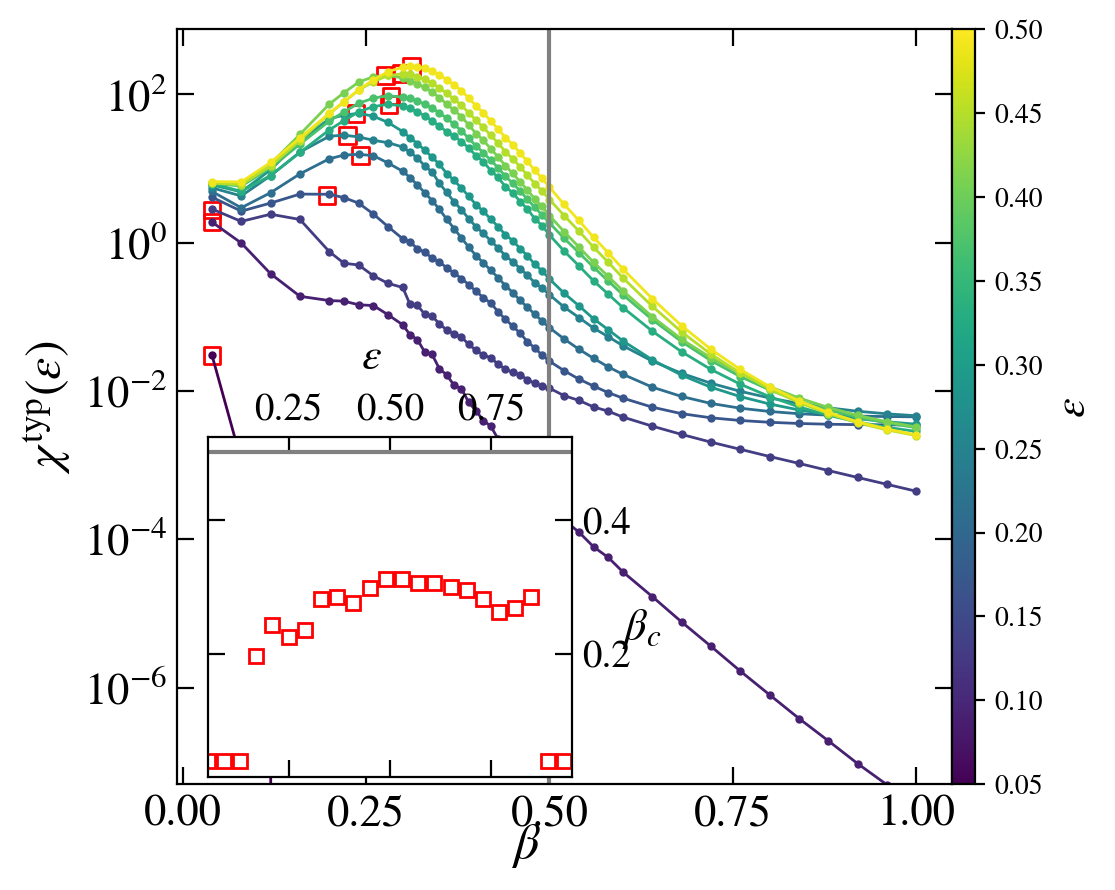

In [16]:

L = 18
w = 2
J = 1
delta=0.55
op=0

BC = 0

prefix = '../results_fgr/disorder/OBC/Spectrals_SzSz/' if BC else '../results_fgr/disorder/PBC/Spectrals_SzSz/'
hz = 0

sizes = np.arange(12, 18, 2)

wx_vals2 = np.arange(0.04, 0.81, 0.04) if BC else np.sort( np.array([*np.arange(0.04, 1.01, 0.04), *np.arange(0.22, 0.61, 0.04), *np.arange(0.31, 0.51, 0.02)]) )


dim = 2**L
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 200)

inset = axis.inset_axes([0.04, 0.01, 0.47, 0.45])

depsilon = 0.05
_eps_ = np.arange(depsilon, 1.0-depsilon, 0.04)
_eps_ = _eps_[_eps_ <= 0.95]
_eps_ = _eps_[_eps_ >= 0.02]

s_m_a = matplotlib.cm.ScalarMappable(cmap='coolwarm', norm= matplotlib.colors.Normalize(vmin=min(wx_vals2), vmax=max(wx_vals2) ))
s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm= matplotlib.colors.Normalize(vmin=min(_eps_), vmax=0.5 ))
# s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm= matplotlib.colors.Normalize(vmin=0.5, vmax=max(_eps_) ))
s_m.set_array([])

alfa_c = []
alfa_c2 = []
agp_c = []
for jj in range(_eps_.size):
    eps = _eps_[jj]
    col2 = s_m.to_rgba(eps)
    # print(eps)
    agp      = np.zeros((wx_vals2.size)); agp.fill(np.nan)
    
    num = 20
    agp_GSinv   = np.zeros((num, wx_vals2.size)); agp_GSinv.fill(np.nan)
    for ii, wx in enumerate(wx_vals2):
        alfa = np.round(wx, 2)
        col = s_m_a.to_rgba(alfa)
        # eta = 2 / (2 - gx)
        name = prefix + info_dis(L=L, J1=J, delta1=delta, w=wx, hz=hz) + '.hdf5'
        if exists(name):
            with h5py.File(name, "r") as file:
                E = np.array(file.get('energy_density')) #[window//2:-window//2]
                wH = np.array(file.get('wH_density'))
                # print(E)
                
                R = np.array(file.get('realisations'))
                DOS = np.array(file.get('DOS'))
                DOS = DOS / max(DOS) * dim
                idx_05 = min(range(len(E)), key=lambda i: abs(E[i] - 0.5))
                idx2 = min(range(len(E)), key=lambda i: abs(E[i] - eps))
                
                norm = DOS
                
                count = np.array(file.get('count')) / R
                _agp = np.array(file.get('susc_E_r_typ')) / R
                
                # _agp = _agp / norm
                agp[ii] = _agp[idx2] / count[idx2]
        else:
            print(name)
    
    norm = dim#max(agp2)#matelem**2 / wH**2
    if eps <= 0.5:
        axis.plot(wx_vals2, agp, color=col2, marker='o', markersize=2, lw=1)
    
    idx = np.argmax(agp)
    
    # agp = agp[wx_vals2>0.1]
    x = wx_vals2#[wx_vals2>0.1]
    indices = np.arange(max(np.argmax(agp) - 5,0), min(np.argmax(agp) + 6, agp.size-1), 1)
    x = np.linspace(x[indices][0], x[indices][-1], 1000)
    f = splrep(wx_vals2[indices], agp[indices], k=3, s=5)
    agp = splev(x, f)
    idx = np.argmax(agp)
    alfa_c.append(x[idx])
    if eps <= 0.5:
        alfa_c2.append(x[idx])
        agp_c.append(agp[idx])
    
    # if eps <= 0.5:
    #     axis.plot(x, agp, color=col2, alpha=0.5)
    
    # if eps <= 0.5:
    #     axis.plot(x, agp, color=col2, lw=4, alpha=0.35)
print(_eps_)
print(alfa_c)
inset.plot(_eps_, alfa_c,  marker='s', color='red', ls='--', markersize=5, lw=0, markerfacecolor='None')#, label=r"$L=%d$"%(L))
# z = np.linspace(0, 1, 1000)
# inset.plot(z, 2 - 8 * (z - 0.5)**2, ls='--', color='k')
# a = 1.05
# b = 0.45
# alfac = g_crit#1 / np.sqrt(2)
# x = np.linspace(0.13, 0.87, 1000)
# inset.plot(x, alfac * np.exp(a**2 * (x - 0.5)**2 / 4 / b*2), color='k', ls='--', lw=2, label=r"$L=\infty$")
axis.scatter(alfa_c2, agp_c, marker='s', color='red', facecolor='None')

axis.xaxis.set_label_coords(.45, -0.05)

axis.axvline(x=0.5, ls='-', c='gray')
# axis.axvline(x=alfa_crit,    ls=':', c='k')
# axis.set_xlim(0, 1)
ylab = r"$\chi^{\rm typ}(\epsilon)$"
fig_help.set_plot_elements(axis, ylabel=ylab, xlabel=r"$\beta$", font_size=16, set_legend=False, xscale='linear', yscale='log')
axis.set_ylim(5e-8, None)


cbar_ax = axis.inset_axes([1., 0.0, 0.03, 1])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'vertical')
cbar.set_label(r"$\epsilon$", fontsize=16)
cbar_ax.yaxis.set_ticks_position('right')
cbar_ax.yaxis.set_label_position('right')

inset.xaxis.set_label_position("top")
inset.xaxis.set_label_coords(.45, 1.2)
inset.xaxis.tick_top()

inset.yaxis.set_label_position("right")
# inset.yaxis.set_label_coords(1.24, 0.59)
inset.yaxis.tick_right()
fig_help.set_plot_elements(inset, ylabel=r"$\\beta_c^*$", xlabel=r"$\epsilon$", font_size=14, set_legend=False, xscale='linear', yscale='linear')
fig_help.set_legend(inset, fontsize=12, loc='lower center')

# inset.set_yticks([1, 1.2, 1.4, 1.6, 1.8, 2.0])

inset.set_ylabel(r"$\beta_c$", rotation=0, fontsize=16)

inset.axhline(y=0.5,    ls='-', color='gray')
# inset.axhline(y=2, ls='-', color='gray')
# inset.set_ylim(0.0, 2.05)
inset.set_xlim(0.05, 0.95)

# fig.savefig("PLOTS_FADING/Fig_max_chaos_mobility.pdf", bbox_inches = 'tight', pad_inches=0.02)

In [27]:
for L in np.arange(8, 15, 1):
    print(L, int(binom(L, L//2)**2 / 2 / L) )

8 306
9 882
10 3175
11 9702
12 35574
13 113256
14 420665


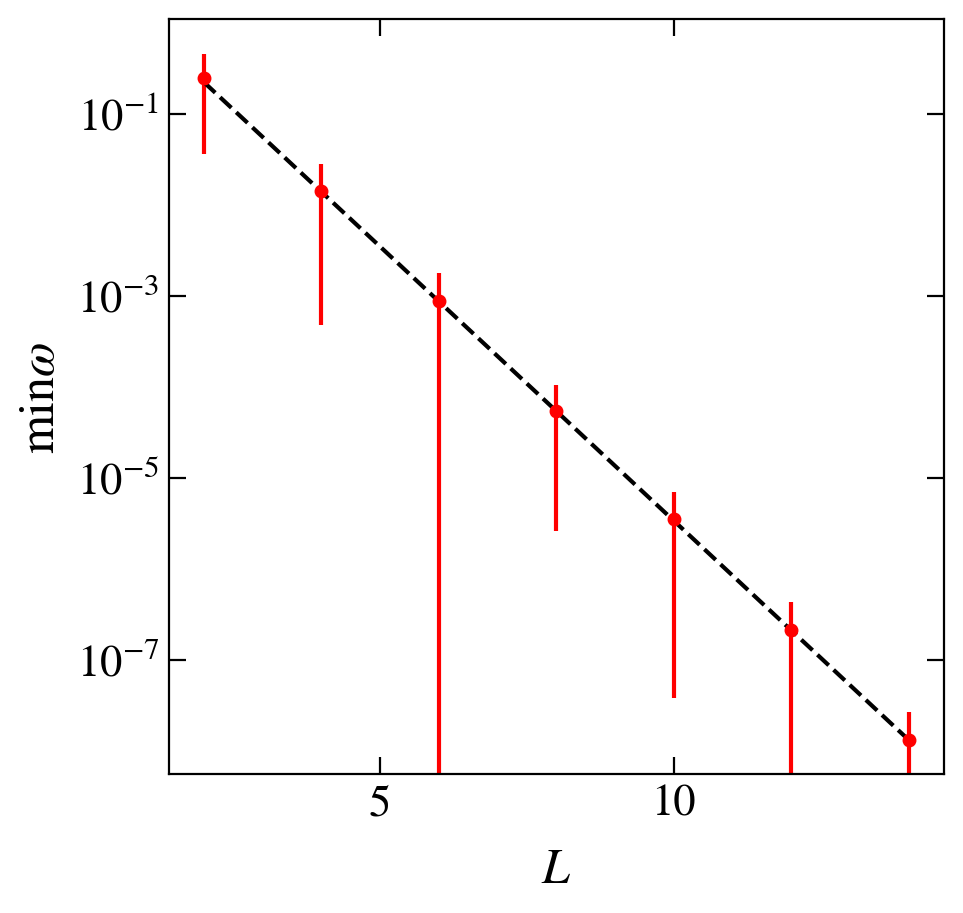

In [434]:
import numpy as np

def min_pairwise_spacing(samples):
    samples = np.sort(samples)
    gaps = np.diff(samples)
    return gaps.min()

def simulate(D, sigma=1.0, mu=0.0, trials=20000):
    mins = np.empty(trials)
    for t in range(trials):
        x = np.random.normal(loc=mu, scale=sigma, size=D)
        mins[t] = min_pairwise_spacing(x)
    return mins

Ls = np.arange(2, 15, 2)
sigma = 1.0
mins = np.zeros((Ls.size))
mins_var = np.zeros((Ls.size))
for iid, L in enumerate(Ls):
    D = 2**L
    x = simulate(D, sigma=sigma, trials=1000)
    mins[iid] = x.mean()
    mins_var[iid] = x.std()

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 200)

# axis.scatter(Ls, mins, color='red')
axis.errorbar(Ls, mins, yerr=mins_var, fmt='o', color='red', markersize=4)

axis.plot(Ls, 2*sigma*np.sqrt(np.pi)/(2**Ls)**2, color='k', ls='--')

fig_help.set_plot_elements(axis, ylabel=r"$\min{\omega}$", xlabel=r"$L$", font_size=16, set_legend=False, xscale='linear', yscale='log')
# print("sim mean:", mins.mean())
# print("asymptotic approx:", sigma*np.sqrt(2*np.pi)/D**2)


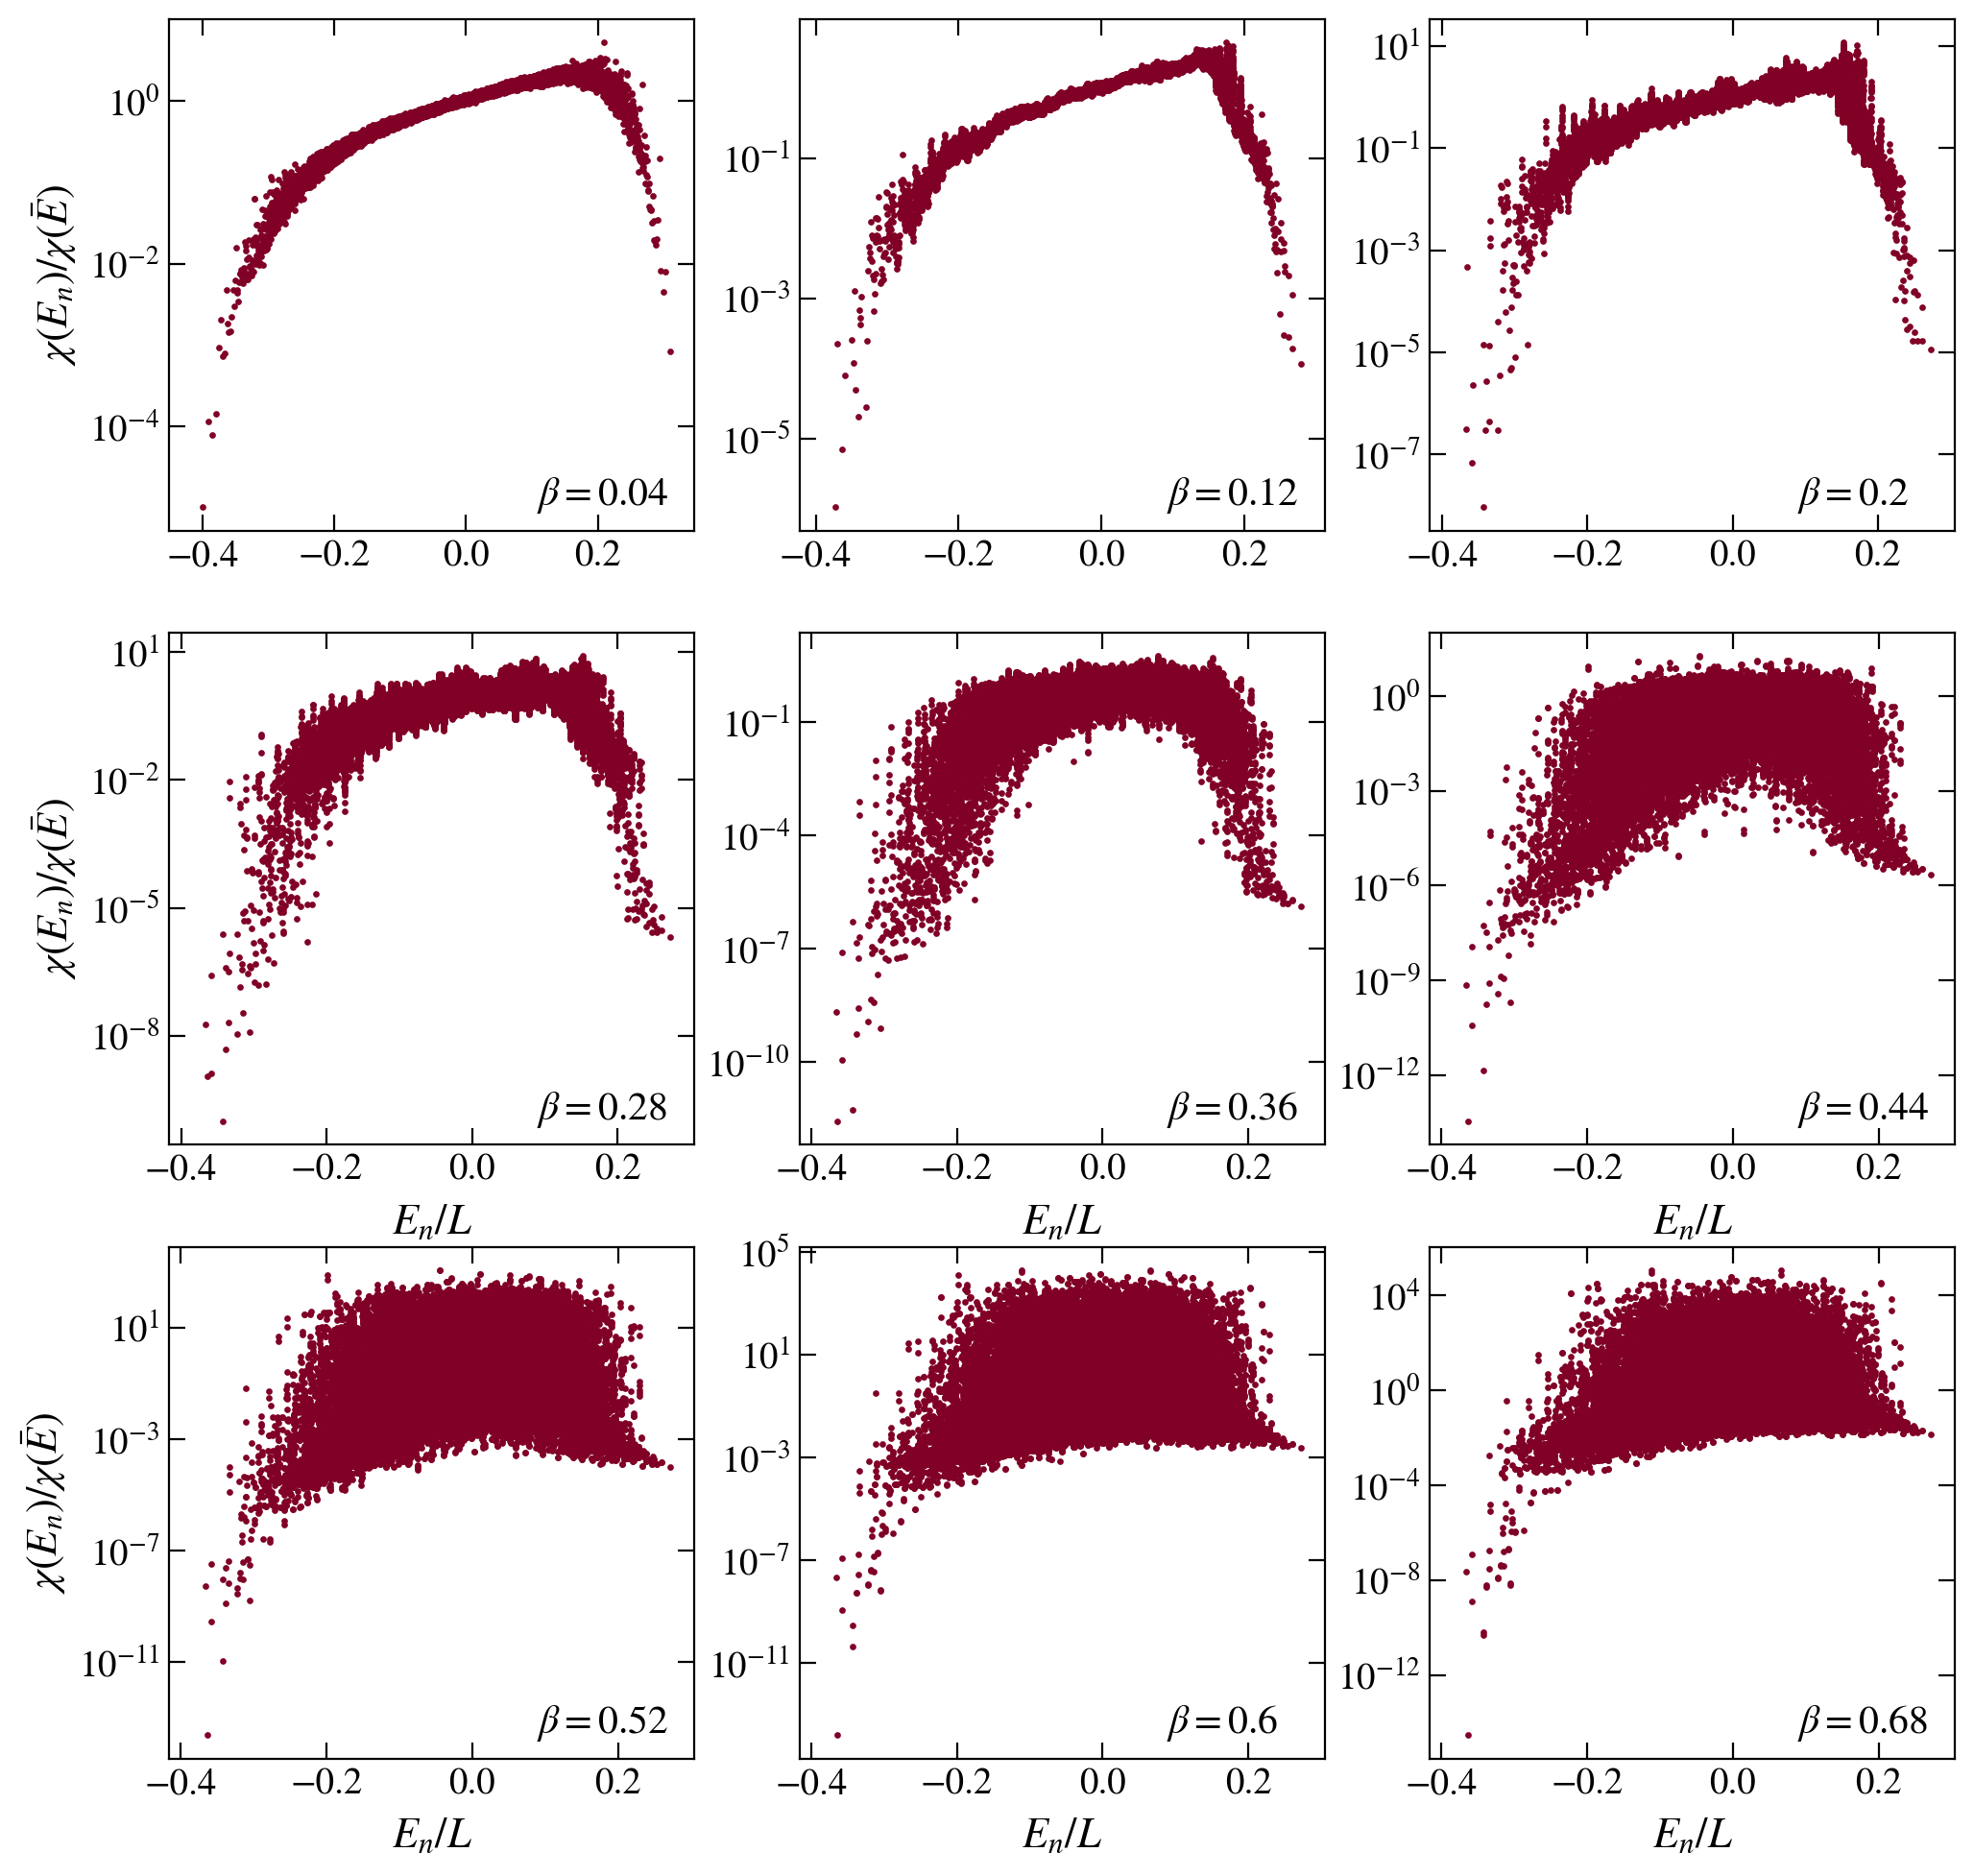

In [444]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0

BC = 0

prefix = '../results_fgr/disorder/OBC/Spectrals_SzSz/' if BC else '../results_fgr/disorder/PBC/Spectrals_SzSz/'
# prefix = '../results/disorder/OBC/Spectrals_SzSz/' if BC else '../results/disorder/PBC/Spectrals_SzSz/'

sizes = np.arange(18, 19, 2)
norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes) )


# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m_L = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m_L.set_array([])

r_idx = 5
corr = 0
gx = 1.5
window = 40

L = 15
eps = 0.5

beta_vals = np.arange(0.04, 0.69, 0.08)
dim = 2**L
fig, axis = plt.subplots( nrows=3, ncols=3, figsize=(12,12), dpi = 200)
axis = axis.flatten()
for ii, wx in enumerate(beta_vals):
    eta = 2 / (2-gx) if gx >= 1 else 2
    for L in sizes[::-1]:
        dim = int( binom(L, L//2) )
        col = s_m.to_rgba(L)
        name = prefix + info_dis(L=L, J1=J, delta1=0.55, w=wx, hz=hz) + '.hdf5'
        if exists(name):
            with h5py.File(name, "r") as file:
                R = np.array(file.get('realisations'))
                En = np.array(file.get('average energies'))
                chin = np.array(file.get('susc_r')) / R
                # print(chin.shape)
                # print(dim, En.size, dim//2, chin.size)
                chin = chin/ chin[dim//2]
                axis[ii].scatter(En / L, chin, color=col, s=2)
        else:
            print(name)
    fig_help.set_plot_elements(axis[ii], ylabel=r"$\chi(E_n)/\chi(\bar{E})$" if ii%3==0 else "", xlabel=r"$E_n/L$" if ii > 2 else "", font_size=14, set_legend=False, xscale='linear', yscale='log')
    axis[ii].annotate(r"$\beta=%g$"%wx,  fontsize=15, xy=(0.7, 0.05), xycoords='axes fraction')

## DIAGONAL MATRIX ELEMENTS

No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


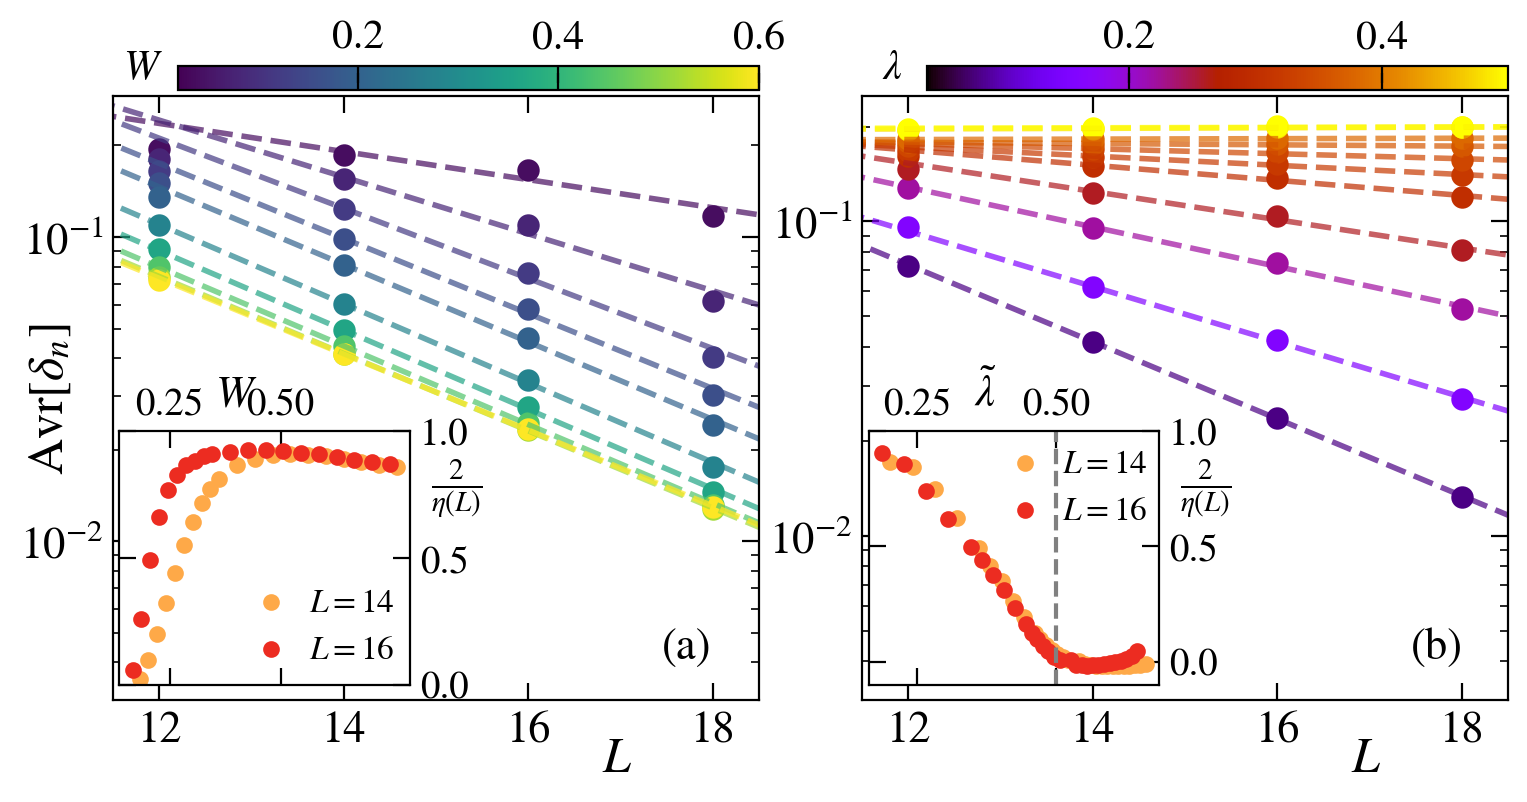

In [179]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0

BC = 0

prefix = '../results_fgr/disorder/OBC/Spectrals_SzSz/' if BC else '../results_fgr/disorder/PBC/Spectrals_SzSz/'
hz = 0
pref1 = '../results_fgr/disorder/OBC/Spectrals_SzSz/' if BC else '../results_fgr/disorder/PBC/Spectrals_SzSz/'
pref2 = '../results/disorder/OBC/Spectrals_SzSz/' if BC else '../results/disorder/PBC/Spectrals_SzSz/'

sizes = np.arange(12, 19, 2)
norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes) )


# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m_L = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m_L.set_array([])

r_idx = 5
corr = 0
gx = 1.5
window = 40

L = 15
eps = 0.5

def exp_fit_kurwa(x, a, xi):
    """Exponential function to fit and find decay rate"""
    return a * 2**(-x * xi)
    # return 1 - 1 / (1 + a * 2**(-x * xi))


DIM = 1
fig, ax = plt.subplots( nrows=1, ncols=2, figsize=(9,4), dpi = 200)
axis = [ax[1], ax[0]]

for iipref, prefix in enumerate([pref1, pref2]):
    # sizes = np.arange(12, 17, 2) if iipref else np.arange(12, 19, 2)
    inset = axis[iipref].inset_axes([0.01, 0.026, 0.45, 0.42])
    
    wx_vals = np.arange(0.04, 0.51, 0.04) if BC else np.sort( np.array([*np.arange(0.04, 0.51, 0.04), *np.arange(0.22, 0.51, 0.04), *np.arange(0.31, 0.51, 0.02)]) )
    if iipref:
        wx_vals = np.array([ *np.arange(0.02, 0.21, 0.02), *np.arange(0.24, 0.61, 0.04)])
    # wx_vals = np.arange(0.36, 0.61, 0.02)

    norm = matplotlib.colors.Normalize(
            vmin=min(wx_vals),
            vmax=max(wx_vals))
    s_m = matplotlib.cm.ScalarMappable(cmap='viridis' if iipref else 'gnuplot', norm=norm)
    s_m.set_array([])

    etas = []
    etas_fit = []
    dims = binom(sizes, sizes//2)
    for ibsifusdf, wx in enumerate(wx_vals):
        col = s_m.to_rgba(wx)
        
        e_to_e_fluct = np.zeros(sizes.shape)
        realis = np.zeros(sizes.shape)
        # ------------------------------------------------------------ ROZENZWEIG-PORTER
        for iiL, L in enumerate(sizes):
            dim = int( binom(L, L//2) )
            counter = 0
            r = 0#np.zeros((45))
            
            name = prefix + info_dis(L=L, J1=J, delta1=0.55, w=wx, hz=hz) + '.hdf5'
            if exists(name):
                with h5py.File(name, "r") as file:
                    Ex = np.array(file.get('energy_density'))
                    DOS = np.array(file.get('DOS'))
                    idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
                    
                    realis[iiL] = np.array(file.get('realisations'))
                    e_to_e_fluct[iiL] = np.array(file.get('e_to_e_fluct'))[-2] if L < 20 else np.array(file.get('e_to_e_fluct'))[-1]
                    
            else:
                print(name)
        
        # print(wx, realis, gap_ratio)
        yy = e_to_e_fluct
        # print(gx, sizes, yy)
        if yy[-1] > yy[-2] and yy[-2] > yy[-3]:
            etas_fit.append(np.nan)
        else:
            parsolo, pconv, fit_info, msg, _ = fit(exp_fit_kurwa,
                            xdata = sizes[1:],
                            ydata = yy[1:],
                            full_output=True, maxfev=10000)
            A = parsolo[0]
            eta_fit = 1 / parsolo[1]
            if eta_fit > 1e6:
                eta_fit = np.nan
            etas_fit.append(eta_fit)
            # if (iig == 0 and gx > 1.0) or (iig and gx < 4):
            z = np.linspace(min(sizes)-1, max(sizes)+1, 1000)
            if ibsifusdf%2:
                axis[iipref].plot(z, exp_fit_kurwa(z, *parsolo), color=col, ls='--', lw=2, alpha=0.7)
                axis[iipref].scatter(sizes, yy, color=col, s=50)
        
        etax = -1 / (np.diff( np.log(e_to_e_fluct) ) / np.diff(np.log(dims)))
        eta = (etax[1:] + etax[:-1])/2
        etas.append(eta)
    # inset.scatter(wx_vals, eta)
    
    # if iipref==0:
    etas = np.transpose( np.array(etas) )
    for iiL, L in enumerate( sizes[1:-1] ):
        col = s_m_L.to_rgba(L)
        inset.scatter(wx_vals + np.log(L) / (2 * np.log(binom(L, L//2))), 2/etas[iiL], color=col, s=25, label=r"$L=%d$"%(L))
        
    cbar_ax = axis[iipref].inset_axes([0.1, 1.01, 0.9, 0.04])
    # fig.colorbar(im, cax=cbar_ax)
    cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'horizontal')
    cbar.set_label(r"$W$" if iipref else r"$\lambda$", fontsize=15)
    cbar_ax.xaxis.set_ticks_position('top')
    cbar_ax.xaxis.set_label_position('top')
    cbar_ax.tick_params(axis='both', which='major', direction="in",length=6, labelsize=15, bottom=True, top=True, left=True, right=True)
    cbar_ax.xaxis.set_label_coords(-0.06, 0.5)
    
    etas_fit = np.array(etas_fit)
    etas = np.transpose(np.array(etas))

    norm = matplotlib.colors.Normalize(vmin=min(sizes[1:]), vmax=max(sizes[1:]) )

    # create a ScalarMappable and initialize a data structure
    upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
    colors = np.vstack((upper))  
    mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)


    s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
    s_m.set_array([])
    for iiL, L in enumerate(sizes[1:-1]):
        col = s_m.to_rgba(L)
        # axis[1].scatter(2**(-L*wx_vals), np.abs(etas[iiL]), color=col, marker='o', facecolor=col, alpha=0.7)  
    #     axis[1].scatter(wx_vals, (etas[iiL]), color=col, marker='o', facecolor=col, alpha=0.7)  

    # axis[1].scatter(wx_vals, np.abs(etas_fit), color='k', marker='s', facecolor='None')


    axis[iipref].set_xlim(min(sizes)-0.5, max(sizes)+0.5)

    # cbar_ax = axis[1].inset_axes([1.01, 0.0, 0.03, 1])
    # # fig.colorbar(im, cax=cbar_ax)
    # cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'vertical')
    # cbar.set_label(r"$L$", fontsize=16)

    # axis[1].axvline(x=0.5, ls='--', color='gray', lw=2)
    
    fig_help.set_plot_elements(axis[1], ylabel=r"${\rm Avr}[\delta_n]$", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='log')
    fig_help.set_plot_elements(axis[0], ylabel=r"", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='log')
    # fig_help.set_plot_elements(axis[1], ylabel=r"$\bar{r} - r_{\rm PE}$", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='log')
    # fig_help.set_plot_elements(axis[1], ylabel=r"$\eta(L)$", xlabel=r"$\beta$", font_size=16, set_legend=1, xscale='linear', yscale='log')
    axis[0].set_ylim(3e-3, 2.5e-1)
    axis[1].set_ylim(3e-3, 2.9e-1)
    axis[iipref].xaxis.set_label_coords(0.78, -0.06)
    axis[1].yaxis.set_label_coords(-0.06, 0.5)
    
    inset.xaxis.set_label_position("top")
    inset.xaxis.set_label_coords(.4, 1.1)
    inset.xaxis.tick_top()

    inset.yaxis.set_label_position("right")
    # inset.yaxis.set_label_coords(1.24, 0.59)
    inset.yaxis.tick_right()
    fig_help.set_plot_elements(inset, ylabel=r"$2/\eta(L)$", xlabel=r"$\tilde{\lambda}$" if iipref==0 else r"$W$", font_size=14, set_legend=0, xscale='linear', yscale='linear')
    if iipref: fig_help.set_legend(inset, fontsize=12, loc='lower right', anchor=(1.05, -0.04), frameon=False)
    else:      fig_help.set_legend(inset, fontsize=12, loc='upper right', anchor=(1.065, 1.05), frameon=False)
    inset.set_ylabel(r"$\frac{2}{\eta(L)}$", fontsize=15, rotation=0)
    inset.yaxis.set_label_coords(1.16, 0.9)
    inset.set_ylim(0 if iipref else -0.1, 1)
    # inset.axvline(x=0.39, ls='-', color='gray')
    inset.set_xticks([0.25, 0.5])
    if iipref==0:
        inset.axvline(x=0.5, ls='--', color='gray', lw=1.5)
    
ax[0].annotate(r"(a)", fontsize=16, xy=(0.85, 0.07), xycoords='axes fraction')
ax[1].annotate(r"(b)", fontsize=16, xy=(0.85, 0.07), xycoords='axes fraction')
fig.subplots_adjust(wspace = 0.16, hspace=0.02)
fig.savefig("PLOTS_FADING/Fig_Onn.pdf", bbox_inches = 'tight', pad_inches=0.02)

No handles with labels found to put in legend.
No handles with labels found to put in legend.


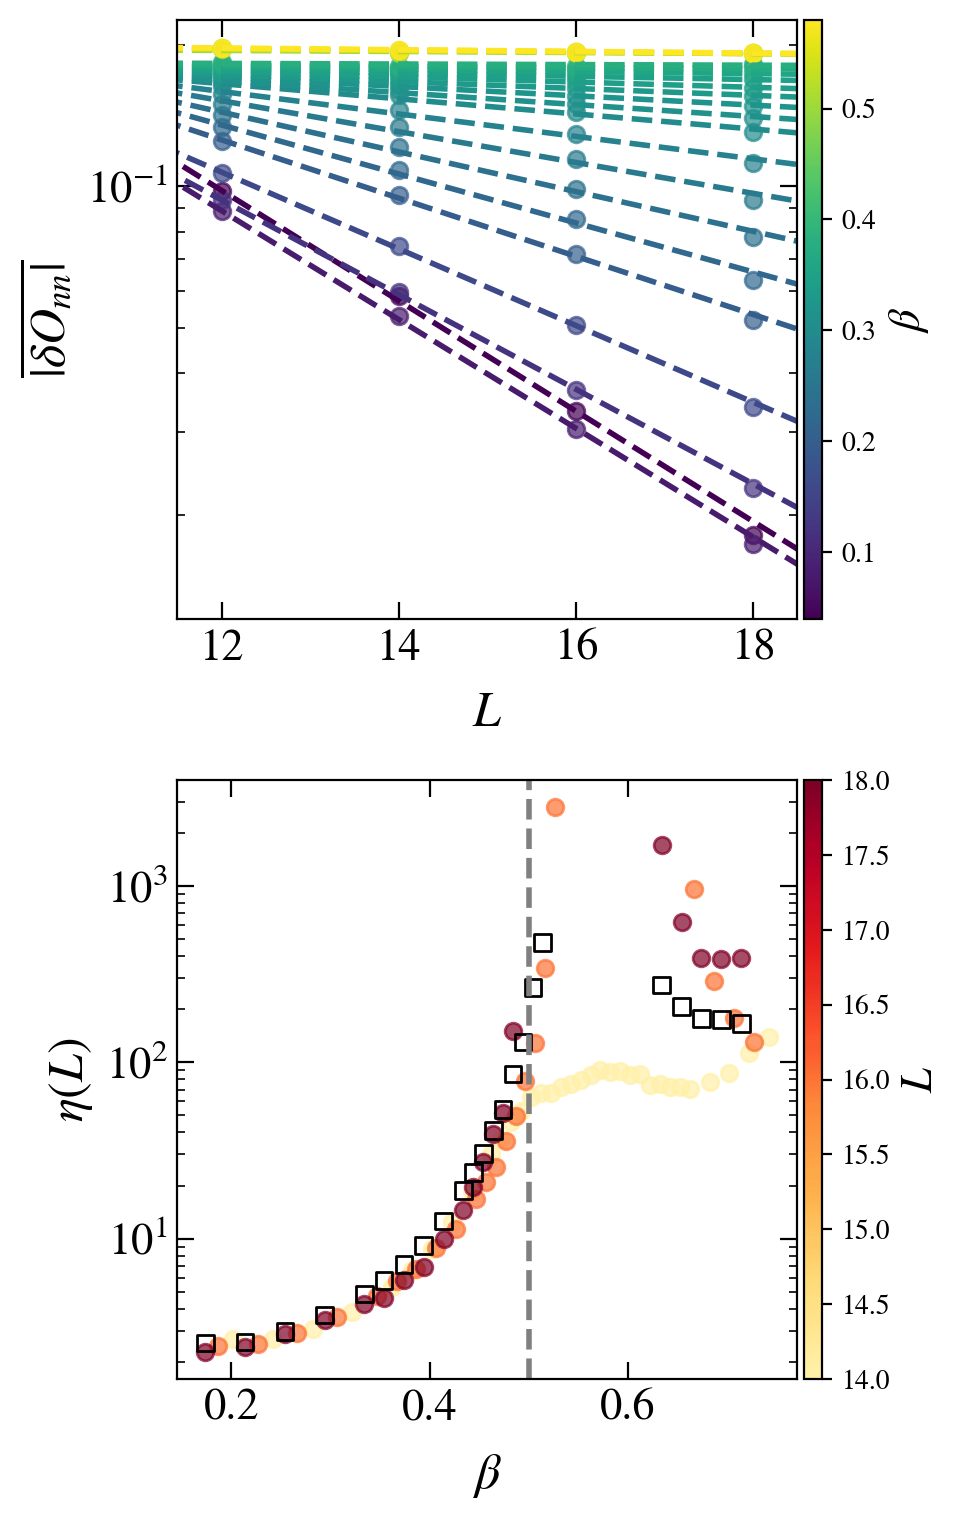

In [182]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0

BC = 0

prefix = '../results_fgr/disorder/OBC/Spectrals_SzSz/' if BC else '../results_fgr/disorder/PBC/Spectrals_SzSz/'
# prefix = '../results/disorder/OBC/Spectrals_SzSz/' if BC else '../results/disorder/PBC/Spectrals_SzSz/'

hz = 0

sizes = np.arange(12, 19, 2)

DIM = 1
fig, axis = plt.subplots( nrows=2, ncols=1, figsize=(4,9), dpi = 200)


r_idx = 5
corr = 0
gx = 1.5
window = 40

L = 15
eps = 0.5

def exp_fit_kurwa(x, a, xi):
    """Exponential function to fit and find decay rate"""
    return a * 2**(-x * xi)
    # return a * x**(-xi)
    # return 1 - 1 / (1 + a * 2**(-x * xi))

wx_vals = np.arange(0.04, 0.71, 0.04) if BC else np.sort( np.array([*np.arange(0.04, 0.6, 0.04), *np.arange(0.22, 0.61, 0.04), *np.arange(0.31, 0.51, 0.02)]) )
# wx_vals = np.arange(0.04, 1.21, 0.04)

# wx_vals = np.arange(0.36, 0.61, 0.02)

norm = matplotlib.colors.Normalize(
        vmin=min(wx_vals),
        vmax=max(wx_vals))
s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])

etas = []
etas_fit = []
for ibsifusdf, wx in enumerate(wx_vals):
    col = s_m.to_rgba(wx)
    
    e_to_e_fluct = np.zeros(sizes.shape)
    realis = np.zeros(sizes.shape)
    DOS = np.zeros(sizes.shape)
    # ------------------------------------------------------------ ROZENZWEIG-PORTER
    for iiL, L in enumerate(sizes):
        dim = int( binom(L, L//2) )
        counter = 0
        r = 0#np.zeros((45))
        
        name = prefix + info_dis(L=L, J1=J, delta1=0.55, w=wx, hz=hz) + '.hdf5'
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energy_density'))
                DOS[iiL] = max(np.array(file.get('DOS')))
                idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
                
                realis[iiL] = np.array(file.get('realisations'))
                e_to_e_fluct[iiL] = np.array(file.get('e_to_e_fluct'))[-1] if L < 20 else np.array(file.get('e_to_e_fluct'))[-1]
                
        else:
            print(name)
    
    # print(wx, realis, gap_ratio)
    yy = e_to_e_fluct
    # print(gx, sizes, yy)
    if yy[-1] > yy[-2] and yy[-2] > yy[-3]:
        etas_fit.append(np.nan)
    else:
        parsolo, pconv, fit_info, msg, _ = fit(exp_fit_kurwa,
                        xdata = sizes,
                        ydata = yy,
                        full_output=True, maxfev=10000)
        A = parsolo[0]
        eta_fit = 1 / parsolo[1]
        if eta_fit > 1e6:
            eta_fit = np.nan
        etas_fit.append(eta_fit)
        # if (iig == 0 and gx > 1.0) or (iig and gx < 4):
        z = np.linspace(min(sizes)-1, max(sizes)+1, 1000)
        axis[0].plot(z, exp_fit_kurwa(z, *parsolo), color=col, ls='--', lw=2)
        axis[0].scatter(sizes, yy, color=col, alpha=0.7)
    
    eta = -1 / (np.diff( np.log(e_to_e_fluct) ) / np.diff(sizes) / np.log(2))
    etas.append(eta)
    
cbar_ax = axis[0].inset_axes([1.01, 0.0, 0.03, 1])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'vertical')
cbar.set_label(r"$\beta$", fontsize=16)
# cbar_ax.xaxis.set_ticks_position('top')
# cbar_ax.xaxis.set_label_position('top')

etas_fit = np.array(etas_fit)
etas = np.transpose(np.array(etas))

norm = matplotlib.colors.Normalize(vmin=min(sizes[1:]), vmax=max(sizes[1:]) )

# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)


s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])
for iiL, L in enumerate(sizes[1:]):
    col = s_m.to_rgba(L)
    # axis[1].scatter(2**(-L*wx_vals), np.abs(etas[iiL]), color=col, marker='o', facecolor=col, alpha=0.7)  
    axis[1].scatter(wx_vals + np.log(L) / (2*np.log(binom(L, L//2))), (etas[iiL]), color=col, marker='o', facecolor=col, alpha=0.7)  

axis[1].scatter(wx_vals + np.log(L) / (2*np.log(binom(L, L//2))), np.abs(etas_fit), color='k', marker='s', facecolor='None')


axis[0].set_xlim(min(sizes)-0.5, max(sizes)+0.5)

cbar_ax = axis[1].inset_axes([1.01, 0.0, 0.03, 1])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'vertical')
cbar.set_label(r"$L$", fontsize=16)

axis[1].axvline(x=0.5, ls='--', color='gray', lw=2)
# axis[1].axvline(x=0.39, ls=':', color='k', lw=2)
# ax.set_ylim(0, 1.05)

# z = np.linspace(1.0, 3.01, 1000)
# ax.plot(z, 2/np.abs(2 - z), ls='-.', color='blue')
# ax.set_ylim(1, 3e2)
# z = np.linspace(0.5, 1.0, 1000)
# ax.plot(z, [1]*z.size, ls='-.', color='blue')
# # ax[1].scatter(gamma_vals, 1/(etas_NE / np.log(2)), color='red', marker='s', facecolor='None')

fig_help.set_plot_elements(axis[0], ylabel=r"$\overline{|\delta O_{nn}|}$", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='log')
# fig_help.set_plot_elements(axis[1], ylabel=r"$\bar{r} - r_{\rm PE}$", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis[1], ylabel=r"$\eta(L)$", xlabel=r"$\beta$", font_size=16, set_legend=1, xscale='linear', yscale='log')


fig.subplots_adjust(wspace = 0.27, hspace=0.27)

## SPECTRAL STATISTICS

No handles with labels found to put in legend.


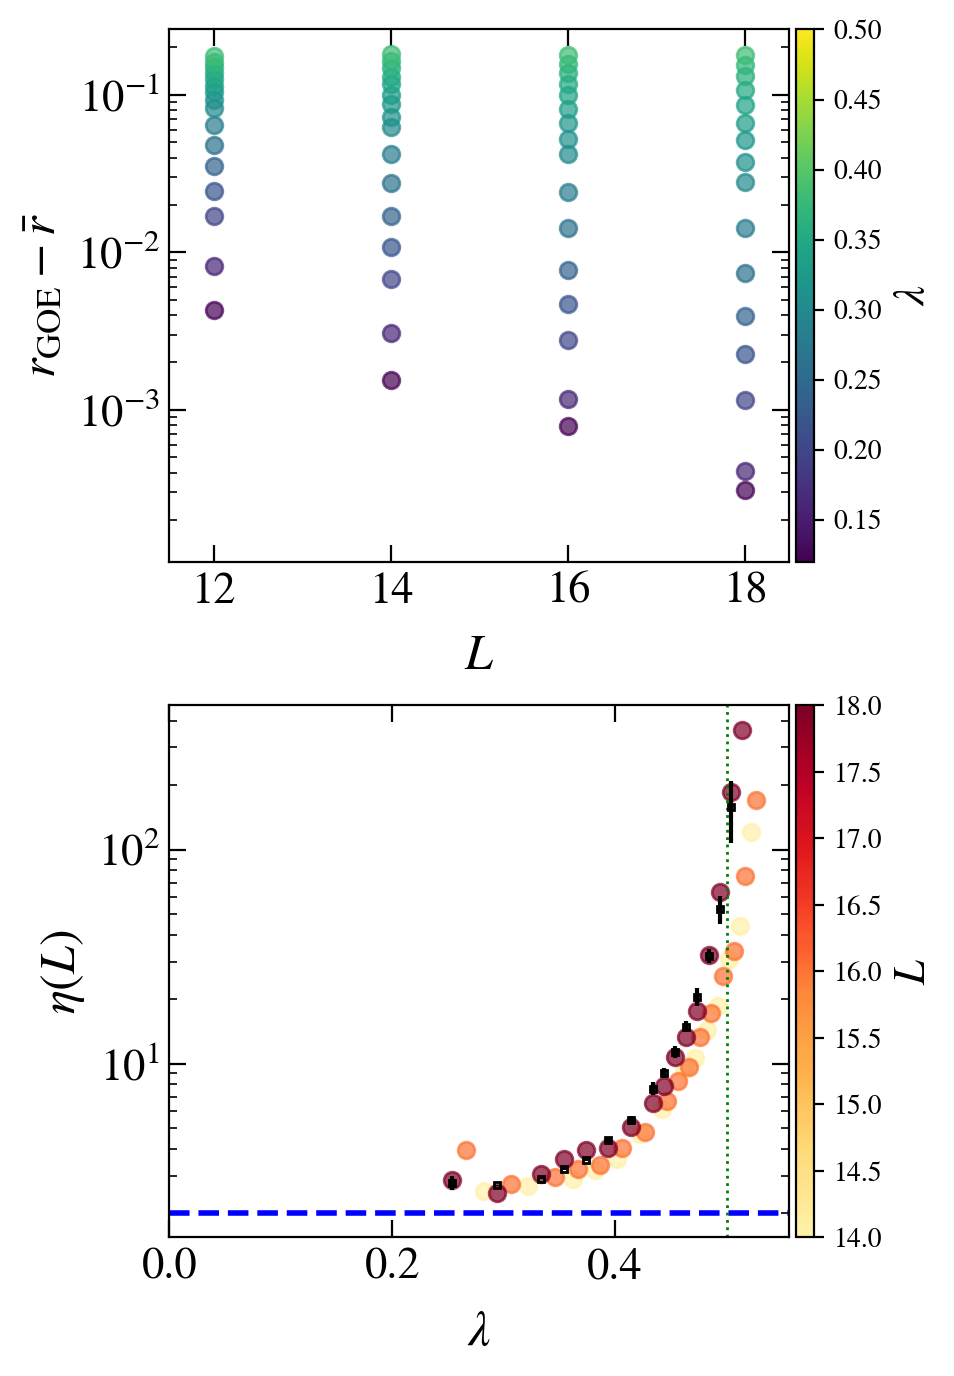

In [183]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0

use_gap_or_weight = 1
BC = 0

prefix = '../results_fgr/disorder/OBC/Spectrals_SzSz/' if BC else '../results_fgr/disorder/PBC/Spectrals_SzSz/'
hz = 0
if not BC: use_gap_or_weight = 1

sizes = np.arange(12, 19, 2)

DIM = 1
fig, axis = plt.subplots( nrows=2, ncols=1, figsize=(4,8), dpi = 200)


r_idx = 5
corr = 0
gx = 1.5
window = 40

L = 15
eps = 0.5

def exp_fit_kurwa(D, a, xi):
    """Exponential function to fit and find decay rate"""
    return a * D**(-2 / xi)
    # return 1 - 1 / (1 + a * 2**(-x * xi))

wx_vals = np.arange(0.12, 0.53, 0.04) if BC else np.sort( np.array([*np.arange(0.12, 0.51, 0.04), *np.arange(0.22, 0.51, 0.04), *np.arange(0.31, 0.51, 0.02)]) )

norm = matplotlib.colors.Normalize(
        vmin=min(wx_vals),
        vmax=max(wx_vals))
s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])

etas = []
etas_fit = []
etas_fit_err = []
for ibsifusdf, wx in enumerate(wx_vals):
    col = s_m.to_rgba(wx)
    
    dims = binom(sizes, sizes//2)
    gap_ratio = np.zeros(sizes.shape)
    realis = np.zeros(sizes.shape)
    # ------------------------------------------------------------ ROZENZWEIG-PORTER
    for iiL, L in enumerate(sizes):
        dim = int( binom(L, L//2) )
        counter = 0
        r = 0#np.zeros((45))
        
        name = prefix + info_dis(L=L, J1=J, delta1=0.55, w=wx, hz=hz) + '.hdf5'
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('average energies'))
                Eav = np.mean(Ex)
                idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - Eav))
                # num = min([dim//10, 500])
                num = int(dim//2)
                # gap_ratio[iiL] = np.mean( np.array(file.get('gap_ratios'))[idx - num//2 : idx + num//2]) if use_gap_or_weight else np.mean( np.array(file.get('weight_ratios'))[idx - num//2 : idx + num//2])
                gap_ratio[iiL] = np.mean( np.array(file.get('gap_ratios'))) if use_gap_or_weight else np.mean( np.array(file.get('weight_ratios')))
                
                realis[iiL] = np.array(file.get('realisations'))
        else:
            print(name)
    
    # print(wx, realis, gap_ratio)
    yy = 0.5307 - gap_ratio if use_gap_or_weight else gap_ratio - 0.8100699350 # if wx <= 0.5 else gap_ratio - (2*np.log(2) - 1)
    # print(gx, sizes, yy)
    if yy[-1] > yy[-2] and yy[-2] > yy[-3]:
        oj = np.zeros((sizes.size-1)); oj.fill(np.nan)
        etas.append(oj)
        etas_fit.append(np.nan)
        etas_fit_err.append(np.nan)
    else:
        parsolo, pconv, fit_info, msg, _ = fit(exp_fit_kurwa,
                        xdata = dims[sizes<20],
                        ydata = yy[sizes<20],
                        full_output=True, maxfev=20000)
        A = parsolo[0]
        eta_fit = parsolo[1]
        if eta_fit > 1e6:
            eta_fit = np.nan
        etas_fit.append(eta_fit)
        perr = np.sqrt(np.diag(pconv))
        etas_fit_err.append(perr[1])
        
        # if (iig == 0 and gx > 1.0) or (iig and gx < 4):
        z = np.linspace(min(sizes)-1, max(sizes)+1, 1000)
        z = binom(z,z/2)
        axis[0].plot(z, exp_fit_kurwa(z, *parsolo), color=col, ls='--', lw=2)
        axis[0].scatter(sizes, yy, color=col, alpha=0.7)
    
        eta = -2 / (np.diff( np.log(yy) ) / np.diff(np.log(dims)) )
        etas.append(eta)
    
cbar_ax = axis[0].inset_axes([1.01, 0.0, 0.03, 1])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'vertical')
cbar.set_label(r"$\lambda$", fontsize=16)
# cbar_ax.xaxis.set_ticks_position('top')
# cbar_ax.xaxis.set_label_position('top')

etas_fit = np.array(etas_fit)
etas = np.transpose(np.array(etas))

norm = matplotlib.colors.Normalize(vmin=min(sizes[1:]), vmax=max(sizes[1:]) )

# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])
for iiL, L in enumerate(sizes[1:]):
    col = s_m.to_rgba(L)
    axis[1].scatter(wx_vals + np.log(L) / (2*np.log(binom(L, L//2))), (etas[iiL]), color=col, marker='o', facecolor=col, alpha=0.7)  

# axis[1].scatter(wx_vals, (etas_fit), color='k', marker='s', facecolor='None')
axis[1].errorbar(x=wx_vals + np.log(L) / (2*np.log(binom(L, L//2))), y=etas_fit, yerr=etas_fit_err, fmt='s', color='k', label=r"$\eta^*$", zorder=10, markerfacecolor='none', markersize=2)
axis[1].axhline(y=2, ls='--', color='blue', lw=2)
axis[1].axvline(x=0.5, ls=':', color='green', lw=1)

beta_c = 0.5
zz = np.linspace(0, beta_c-0.01, 1000)
# axis[1].plot(zz, 2 / (1 - zz / beta_c), ls='-.', color='red')

axis[0].set_xlim(min(sizes)-0.5, max(sizes)+0.5)
axis[1].set_xlim(0, None)
cbar_ax = axis[1].inset_axes([1.01, 0.0, 0.03, 1])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'vertical')
cbar.set_label(r"$L$", fontsize=16)

# ax.set_ylim(0, 1.05)

# z = np.linspace(1.0, 3.01, 1000)
# ax.plot(z, 2/np.abs(2 - z), ls='-.', color='blue')
# ax.set_ylim(1, 3e2)
# z = np.linspace(0.5, 1.0, 1000)
# ax.plot(z, [1]*z.size, ls='-.', color='blue')
# # ax[1].scatter(gamma_vals, 1/(etas_NE / np.log(2)), color='red', marker='s', facecolor='None')

fig_help.set_plot_elements(axis[0], ylabel=r"$r_{\rm GOE}-\bar{r}$" if use_gap_or_weight else r"$\bar{q} - q_{\rm GOE}$", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='log')
# fig_help.set_plot_elements(axis[1], ylabel=r"$\bar{r} - r_{\rm PE}$", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis[1], ylabel=r"$\eta(L)$", xlabel=r"$\lambda$", font_size=16, set_legend=0, xscale='linear', yscale='log')


fig.subplots_adjust(wspace = 0.27, hspace=0.27)

(43, 40) (43, 40) (40, 43)


Text(0.5, 1.0, '$\\langle r\\rangle$')

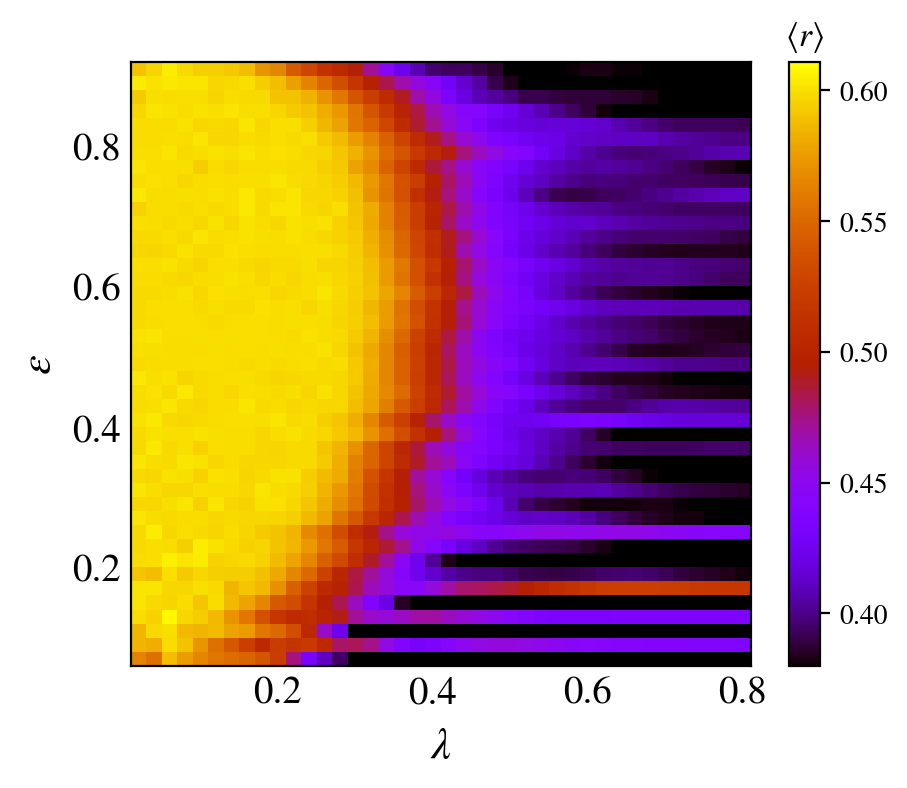

In [252]:

markers = itertools.cycle(markers_ls)


L = 16
w = 2
J = 1
delta=0.55
op=0
hz=0

ADD_CURRENT = 1

use_gap_or_weight = 1
BC = 0

prefix = '../results_fgr/disorder/OBC/Spectrals_SzSz/' if BC else '../results_fgr/disorder/PBC/Spectrals_SzSz/'
if ADD_CURRENT: prefix = '../results_fgr2/disorder/PBC/Spectrals_SzSz/'


# wx_vals2 = np.arange(0.04, 0.81, 0.04)
wx_vals2 = np.arange(0.04, 0.76, 0.04)
if ADD_CURRENT: wx_vals2 = np.arange(0.02, 0.81, 0.02)

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,4), dpi = 200)

norm = matplotlib.colors.Normalize(vmin=min(sizes), vmax=max(sizes) )

# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])


energy_density = None
gap_ratio_density = []
for ii, wx in enumerate(wx_vals2):
    name = prefix + info_dis(L=L, J1=J, delta1=delta, w=wx, hz=hz) + '.hdf5'
    if exists(name):
        with h5py.File(name, "r") as file:
            # gap_ratio = np.array(file.get('gap_ratio density'))
            E = np.array(file.get('energy_density'))
            E = E[1:-1]
            gap_ratio = np.array(file.get('gap_ratio_density'))[1:-1] if use_gap_or_weight else np.array(file.get('weight_density'))[1:-1]
            # gap_ratio = (gap_ratio - 0.3867) / (0.5307 - 0.3867)
            gap_ratio_density.append(gap_ratio if use_gap_or_weight else 1-gap_ratio)
            energy_density = E
    else:
        print(name)

energy_density = np.array(energy_density)
gap_ratio_density = np.array(gap_ratio_density)

interaction = np.array([wx_vals2 for _ in energy_density])

#white = plt.get_cmap('seismic', 100)(0.5*np.ones(1))
upper = plt.get_cmap('gnuplot', 100)(np.linspace(0.0, 1.0, 100))
colors = np.vstack((upper))  

mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

X, Y = np.meshgrid(wx_vals2, energy_density)

print(X.shape, Y.shape, gap_ratio_density.shape)
if use_gap_or_weight: p = axis.pcolormesh(X, Y, np.transpose(gap_ratio_density), shading='nearest', cmap=mymap, vmin=0.3867 if BC else 0.38, vmax=0.6109, rasterized=True)
else:                 p = axis.pcolormesh(X, Y, np.transpose(gap_ratio_density), shading='nearest', cmap=mymap, vmax=1-0.8100699350, vmin=0, rasterized=True)
# p = axis.pcolormesh(X, Y, np.transpose(gap_ratio_density), shading='nearest')
fig_help.set_plot_elements(axis, ylabel=r"$\epsilon$", xlabel=r"$\lambda$", font_size=14, set_legend=False)
# axis.set_title(r"$L=%d, N=%d, g_0=%.2f$"%(L, N, J), fontsize=16)

clb = fig.colorbar(p)
clb.solids.set_edgecolor("face")     # avoid white gridlines
clb.solids.set_rasterized(True)
clb.ax.set_title(r"$\langle r\rangle$" if use_gap_or_weight else r"$1-\langle q\rangle$")

# a = 1.05
# b = 0.45
# alfac = alfa_crit
# alfac = 1 / np.sqrt(2)
# x = np.linspace(0.04, 0.96, 1000)
# axis.plot(alfac * np.exp(a**2 * (x - 0.5)**2 / 4 / b*2), x, color='k', ls='-', lw=2, label=r"Eq. (B1)", rasterized=True)
# leg = fig_help.set_legend(axis, fontsize=14, loc='lower left', anchor=(0.0, 0.96), ncol=2)
# leg.set_rasterized(True)
# axis.set_ylim(0.05, 0.94)

# fig.savefig("plots_AGP/FigS2.pdf", bbox_inches = 'tight', pad_inches=0.02)
# fig.savefig("plots_AGP/FigS2.png", bbox_inches = 'tight', pad_inches=0.02)
# from PIL import Image
# fname = 'plots_AGP/FigS2.png'
# image = Image.open(fname).convert("L")
# arr = np.asarray(image)
# figura, ax_gray = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 200, sharex=True)
# ax_gray.set_axis_off()
# ax_gray.imshow(arr, cmap='gray', vmin=0, vmax=255)



No handles with labels found to put in legend.


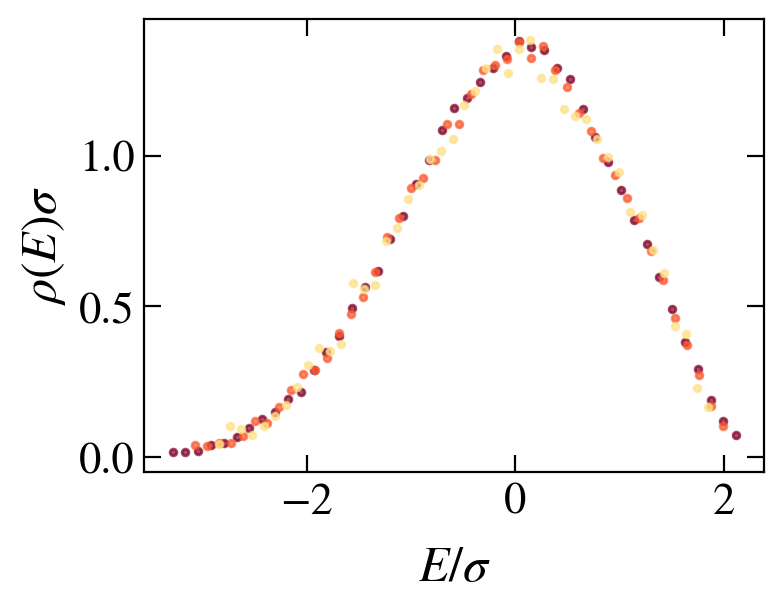

In [230]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0

BC = 1

prefix = '../results_fgr/disorder/OBC/Spectrals_SzSz/' if BC else '../results_fgr/disorder/PBC/Spectrals_SzSz/'
prefix = '../results_fgr2/disorder/PBC/energy_current/'
hz = 0

sizes = np.arange(12, 17, 2)

DIM = 1
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200, sharex=True, sharey=False)

L = 15
eps = 0.5


norm = matplotlib.colors.Normalize(vmin=min(sizes), vmax=max(sizes) )

# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.2, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])


wx = 0.2
for iiL, L in enumerate(sizes[::-1]):
    dim = int( binom(L, L//2) )

    col = s_m.to_rgba(L)
    
    omegas = np.nan
    spec_fun = np.nan
    name = prefix + info_dis(L=L, J1=J, delta1=0.55, w=wx, hz=hz) + '.hdf5'
    if exists(name):
        with h5py.File(name, "r") as file:
            Ex = np.array(file.get('energy_density')) * np.mean(np.array(file.get('bandwidth'))) + np.array(file.get('average energies'))[0]
            sig = np.mean(np.array(file.get('stddev')))
            Ex = Ex / sig
            DOS = np.array(file.get('DOS')) / dim / sig
            # print(Ex, DOS)
            axis.scatter(Ex, DOS, color=col, alpha=0.7, s=6)
    else:
        print(name)
    
    
fig_help.set_plot_elements(axis, ylabel=r"$\rho(E)\sigma$", xlabel=r"$E/\sigma$", font_size=16, set_legend=1, xscale='linear', yscale='linear')


fig.subplots_adjust(wspace = 0.02, hspace=0.02)

No handles with labels found to put in legend.


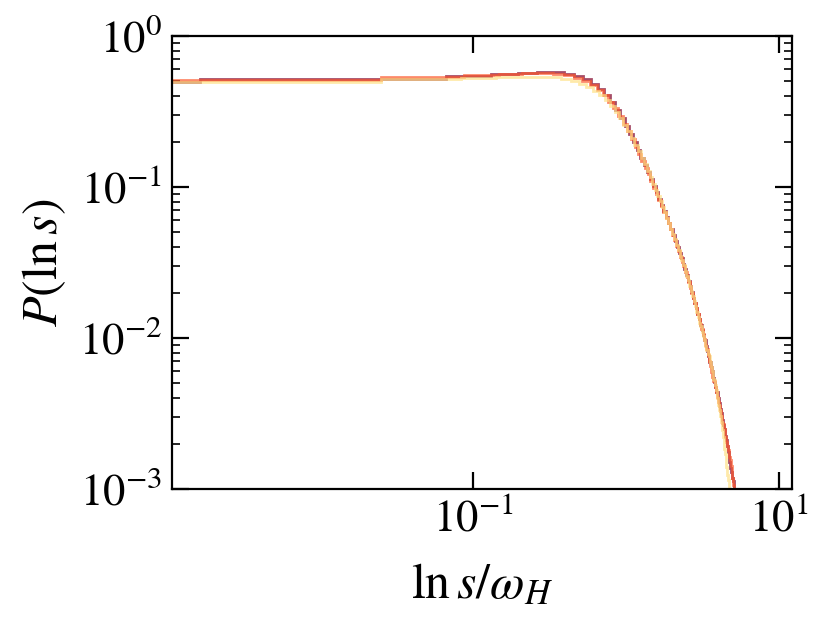

In [245]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0

BC = 1

prefix = '../results/disorder/OBC/Spectrals_SzSz/' if BC else '../results/disorder/PBC/Spectrals_SzSz/'
hz = 1 if BC else 0

sizes = np.arange(12, 17, 2)

DIM = 1
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200, sharex=True, sharey=False)

L = 15
eps = 0.5


norm = matplotlib.colors.Normalize(vmin=min(sizes), vmax=max(sizes) )

# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.2, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])


wx = 0.02
for iiL, L in enumerate(sizes[::-1]):
    dim = int( binom(L, L//2) )

    col = s_m.to_rgba(L)
    
    omegas = np.nan
    spec_fun = np.nan
    name = prefix + info_dis(L=L, J1=J, delta1=0.55, w=wx, hz=hz) + '.hdf5'
    if exists(name):
        with h5py.File(name, "r") as file:
            wH = (np.array(file.get('wH')))[0]
            lvl_space_dist = np.array(file.get('lvl_spacing/dist_log'))
            lvl_space_bins = np.array(file.get('lvl_spacing/bins_log')) - np.log(wH)
            # print(Ex, DOS)
            axis.stairs(lvl_space_dist, lvl_space_bins, color=col, alpha=0.7)
    else:
        print(name)
    
    
fig_help.set_plot_elements(axis, ylabel=r"$P(\ln{s})$", xlabel=r"$\ln{s/\omega_H}$", font_size=16, set_legend=1, xscale='log', yscale='log')
axis.set_ylim(1e-3, 1e0)

fig.subplots_adjust(wspace = 0.02, hspace=0.02)

No handles with labels found to put in legend.
No handles with labels found to put in legend.


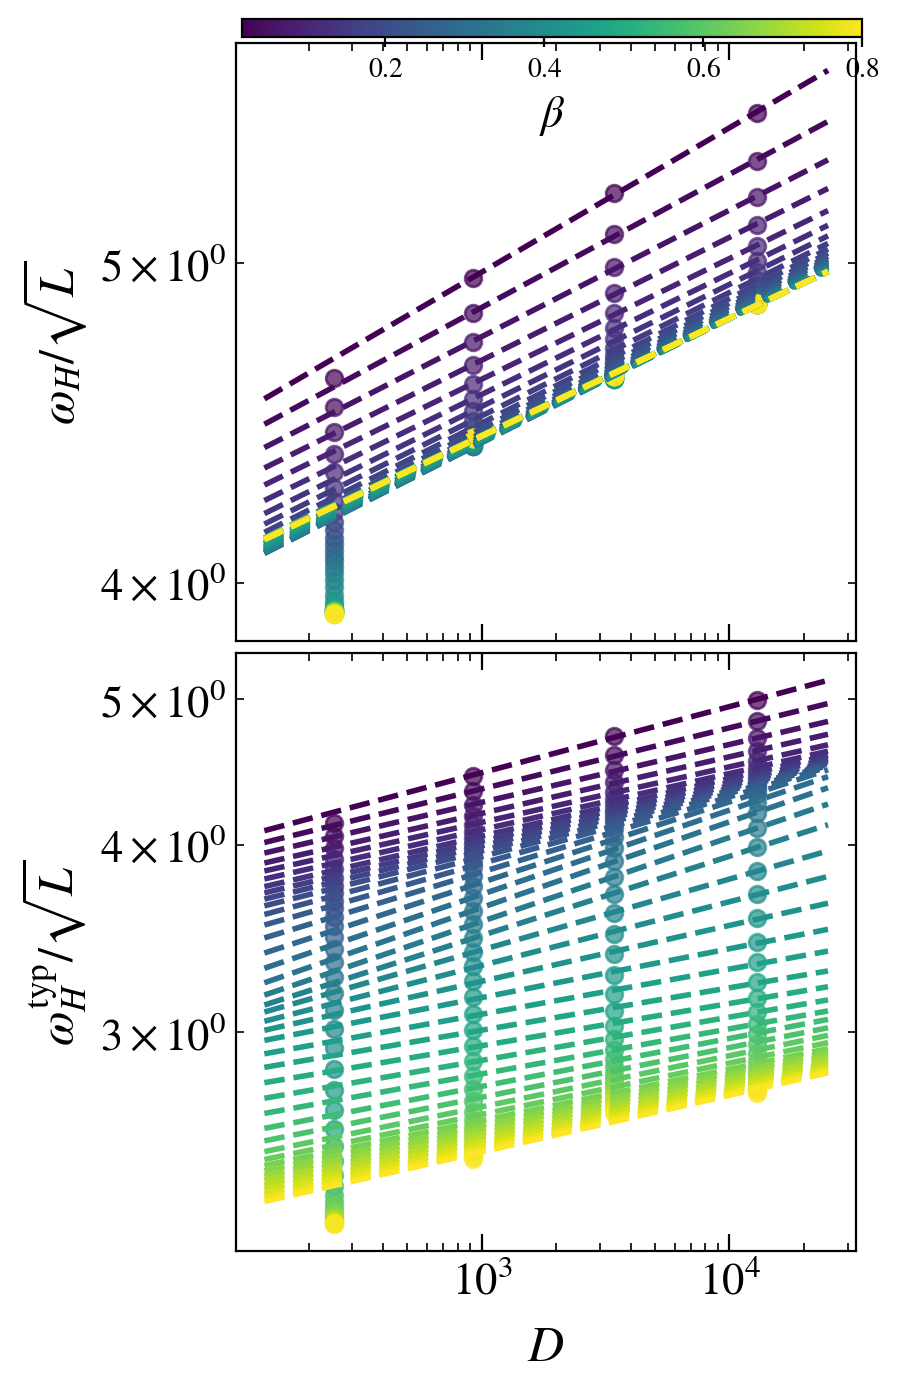

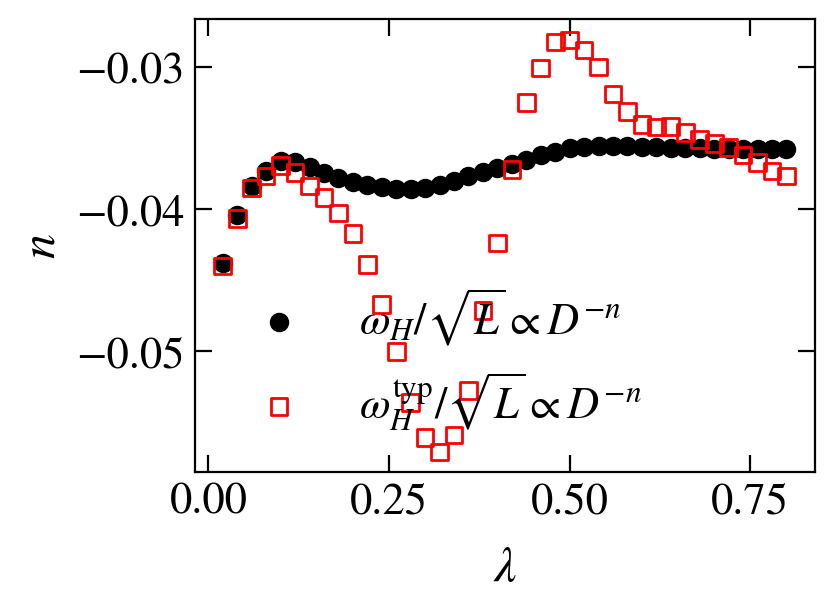

In [274]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0

ADD_CURRENT = 1

use_gap_or_weight = 0
BC = 0

prefix = '../results_fgr/disorder/OBC/Spectrals_SzSz/' if BC else '../results_fgr/disorder/PBC/Spectrals_SzSz/'
if ADD_CURRENT: prefix = '../results_fgr2/disorder/PBC/Spectrals_SzSz/'

hz = 0
if not BC: use_gap_or_weight = 1

sizes = np.arange(12, 21, 2)
if ADD_CURRENT: sizes = np.arange(10, 17, 2)

DIM = 1
fig, axis = plt.subplots( nrows=2, ncols=1, figsize=(4,8), dpi = 200, sharex=True)
fig2, axis2 = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200, sharex=True)

r_idx = 5
corr = 0
gx = 1.5
window = 40

L = 15
eps = 0.5

def exp_fit_kurwa(x, a, xi):
    """Exponential function to fit and find decay rate"""
    return a * 2**(-x * xi)
    # return 1 - 1 / (1 + a * 2**(-x * xi))

# wx_vals = np.sort( np.array([*np.arange(0.04, 0.99, 0.04), *np.arange(0.22, 0.61, 0.04), *np.arange(0.31, 0.51, 0.02)]) )
wx_vals = np.sort( np.array([*np.arange(0.04, 0.51, 0.04), *np.arange(0.22, 0.51, 0.04), *np.arange(0.31, 0.51, 0.02)]) )
if ADD_CURRENT: wx_vals = np.arange(0.02, 0.81, 0.02)

norm = matplotlib.colors.Normalize(
        vmin=min(wx_vals),
        vmax=max(wx_vals))
s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])


def maj_fit(D, a, b):
    return a * D**(-b)
    
n_wH = []
n_wH_typ = []

dims = binom(sizes, sizes//2)
for ibsifusdf, wx in enumerate(wx_vals):
    col = s_m.to_rgba(wx)
    
    wH = np.zeros(sizes.shape)
    wH_typ = np.zeros(sizes.shape)
    realis = np.zeros(sizes.shape)
    # ------------------------------------------------------------ ROZENZWEIG-PORTER
    for iiL, L in enumerate(sizes):
        dim = int( binom(L, L//2) )
        counter = 0
        r = 0#np.zeros((45))
        
        name = prefix + info_dis(L=L, J1=J, delta1=0.55, w=wx, hz=hz) + '.hdf5'
        if exists(name):
            with h5py.File(name, "r") as file:
                wH[iiL] = np.array(file.get('wH'))[-2] *dim#/ L**0.5
                wH_typ[iiL] = np.array(file.get('wH_typ'))[-2]*dim# / L**0.5
                
                realis[iiL] = np.array(file.get('realisations'))
        else:
            print(name)
    
    for iiy, yy in enumerate([wH, wH_typ]):
        parsolo, pconv, fit_info, msg, _ = fit(maj_fit,
                        xdata = dims[1:],
                        ydata = yy[1:],
                        full_output=True, maxfev=20000)
        A = parsolo[0]
        n = parsolo[1]
        
        if iiy == 0: n_wH.append(n)
        else:        n_wH_typ.append(n)
        
        z = np.linspace(min(sizes)-1, max(sizes)+1, 1000)
        z = binom(z, z/2)
        axis[iiy].plot(z, maj_fit(z, *parsolo), color=col, ls='--', lw=2)
        axis[iiy].scatter(dims, yy, color=col, alpha=0.7)
    
cbar_ax = axis[0].inset_axes([0.01, 1.01, 1, 0.03])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'horizontal')
cbar.set_label(r"$\beta$", fontsize=16)


axis2.scatter(wx_vals, n_wH, color='black', marker='o', label=r'$\omega_H/\sqrt{L}\propto D^{-n}$')
axis2.scatter(wx_vals, n_wH_typ, color='red', marker='s', facecolor='None', label=r'$\omega_H^{\rm typ}/\sqrt{L}\propto D^{-n}$')

fig_help.set_plot_elements(axis[0], ylabel=r"$\omega_H/\sqrt{L}$", xlabel="", font_size=16, set_legend=1, xscale='log', yscale='log')
fig_help.set_plot_elements(axis[1], ylabel=r"$\omega_H^{\rm typ}/\sqrt{L}$", xlabel=r"$D$", font_size=16, set_legend=1, xscale='log', yscale='log')
fig_help.set_plot_elements(axis2, ylabel=r"$n$", xlabel=r"$\lambda$", font_size=16, set_legend=1, xscale='linear', yscale='linear')


fig.subplots_adjust(wspace = 0.02, hspace=0.02)

In [ ]:
##

## LDOS AND FRACTAITY

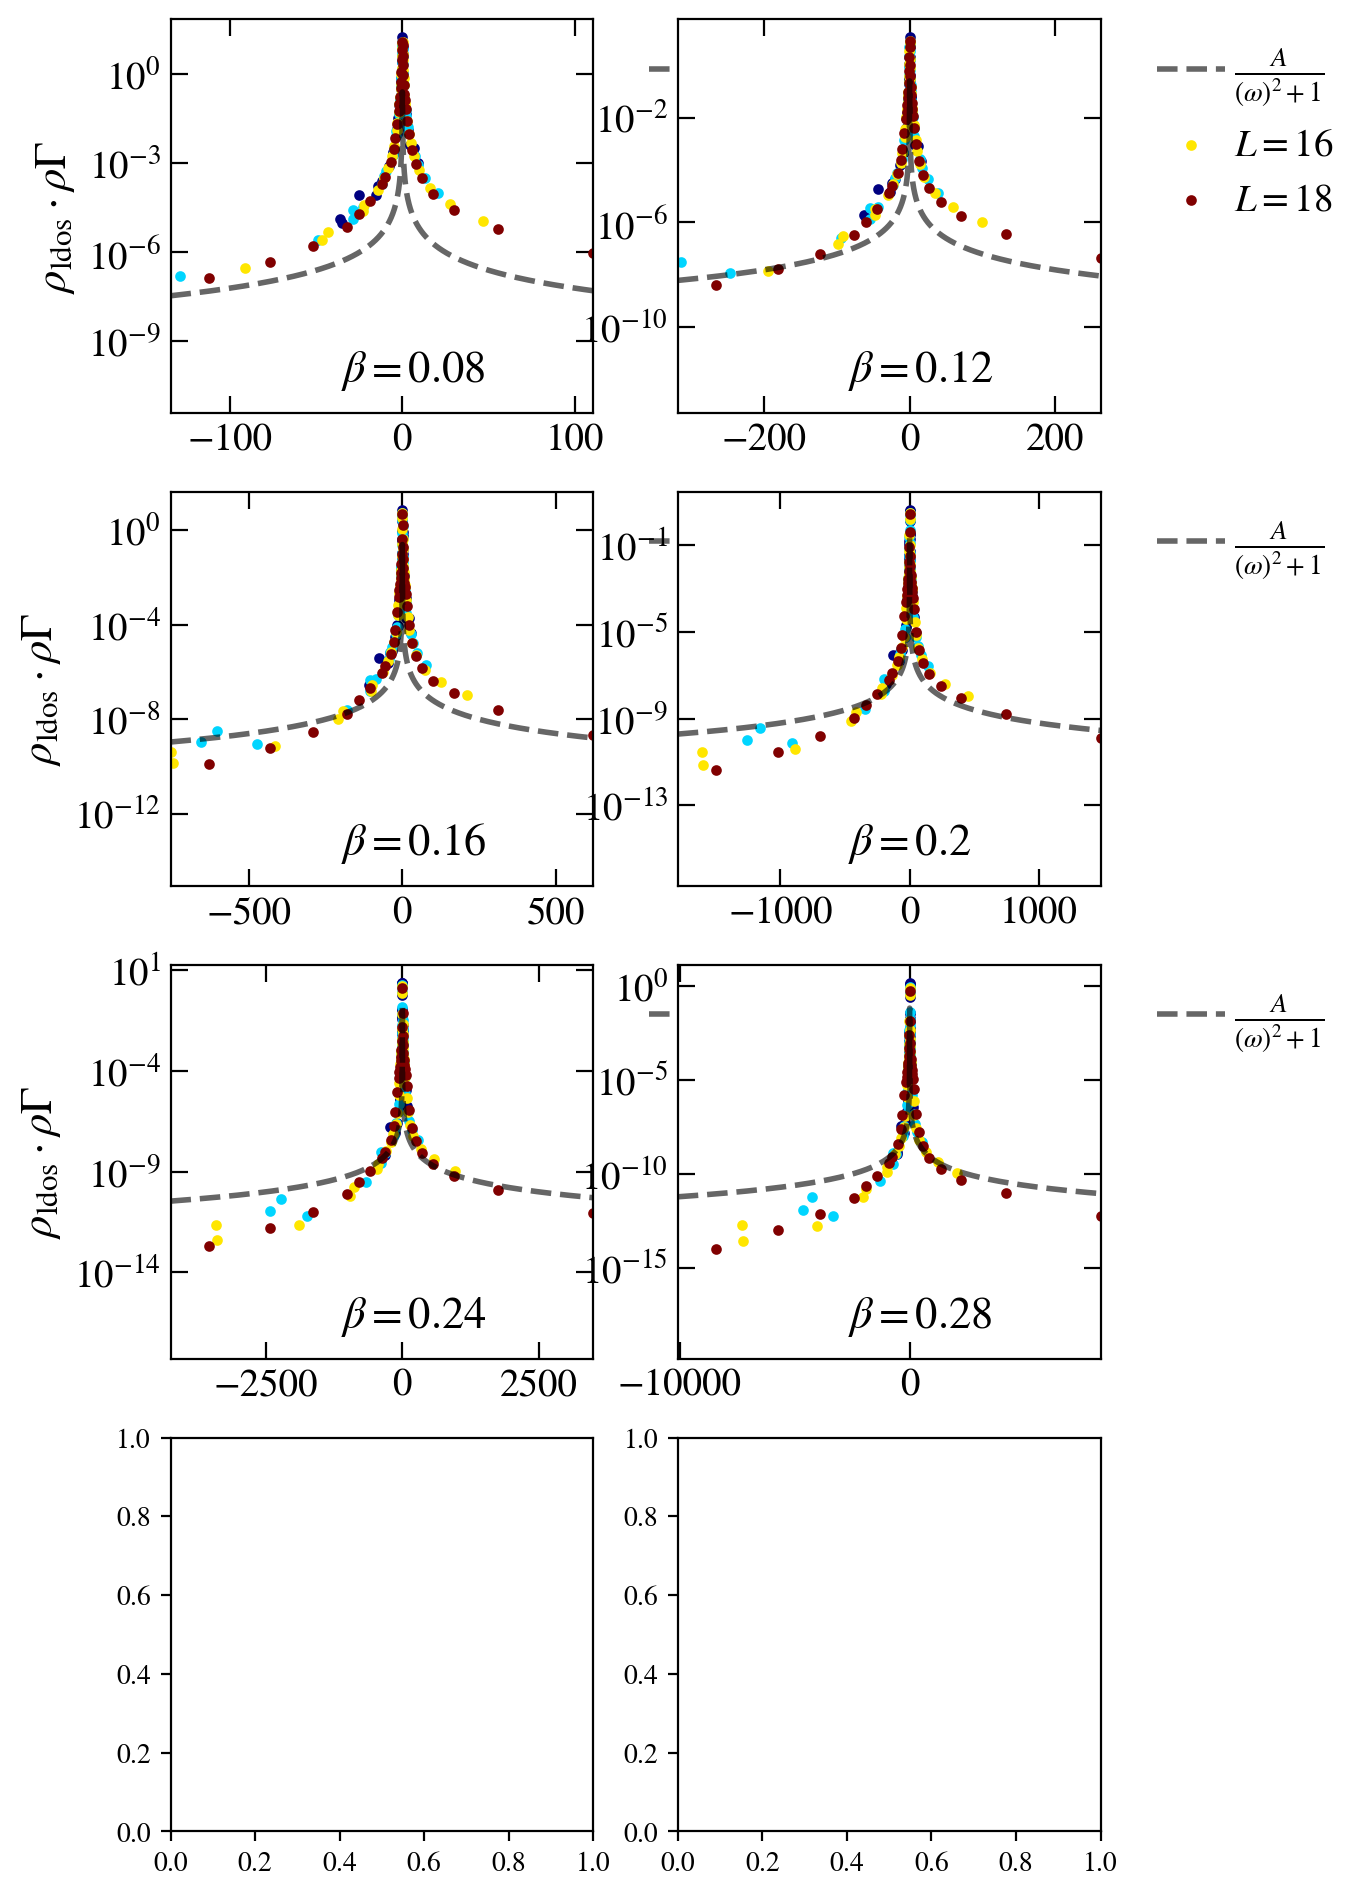

In [17]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0

use_gap_or_weight = 0
BC = 0

prefix = '../results_fgr/disorder/OBC/' if BC else '../results_fgr/disorder/PBC/'
hz = 0
if not BC: use_gap_or_weight = 1

sizes = np.arange(12, 19, 2)

DIM = 1
fig, axis = plt.subplots( nrows=4, ncols=2, figsize=(6,12), dpi = 200, sharex=False, sharey=False)
axis = axis.flatten()

def lorenz(x, A, sig, G):
    return A / G / np.pi / ( (x / G)**2 + 1) * np.exp(-x**2 / (2*sig**2) ) /np.sqrt(2*np.pi*sig**2)
    # return A / np.sqrt(2*np.pi*sig**2) * np.exp(-x**2 / (2*sig**2))

norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])


L = 15
eps = 0.5
gamma_c = 2


gx = 1.2

dim = 2**L

betas = np.arange(0.08, 0.31, 0.04)

for iig, wx in enumerate(betas):
    for ii, L in enumerate(sizes):
        dim = binom(L, L//2)   
        col = s_m.to_rgba(L)
        num = min([100, dim//50])
        name = prefix + 'Fractality/' + info_dis(L=L, J1=J, delta1=0.55, w=wx, hz=hz) + '.hdf5'
        if exists(name):
            with h5py.File(name, "r") as file:
                dE = np.mean(np.array(file.get('dE')))
                E0 = np.mean(np.array(file.get('E0')))
                energy_density = np.array(file.get('energy_density'))
                energy_density = (energy_density[1:] + energy_density[:-1]) / 2.
                # energy_density = -2*(energy_density-0.5)
                # energy_density = 2*(0.5 - energy_density)
                energy_density = ( (energy_density) * dE + E0)
                # energy_density = (E0 + dE/2) - ( (energy_density) * dE + E0)
                # ldos = np.exp( np.mean(np.log(np.array(file.get('LDOS'))), axis=1) )
                ldos = ( np.mean((np.array(file.get('LDOS'))), axis=1) )
                # ldos = np.array(file.get('LDOS'))[:,num//2]
                # print(L, gx, np.sum(ldos))
                
                sig = np.sqrt(1 + dim**(1.0-gx))
                # DOS = dim / np.sqrt(2*np.pi*sig**2) * np.exp(-energy_density**2 / (2*sig**2))
                # DOS = DOS + DOS * 4 * dim**(2-gx) / sig**2 * (2*np.sqrt(2) * energy_density / sig * dawson(energy_density / np.sqrt(2) / sig) - 1)
                DOS = np.array(file.get('DOS0'))
                HSnorm = 1
                G = np.pi * dim**(-2*wx) * HSnorm * (DOS) / (dim - 1.0)# if gx >= 1 else DOS * sig * HSnorm
                
                xx = energy_density / G# * np.sqrt(dim)
                yy = ldos  * G * DOS# / dim# / G
                
                if iig == 0 and ii < 2: axis[iig].scatter( xx, yy, color=col, label=r"$L=%d$"%L, s=8)
                elif iig == 1 and ii > 1: axis[iig].scatter( xx, yy, color=col, label=r"$L=%d$"%L, s=8)
                else:                     axis[iig].scatter( xx, yy, color=col, s=8)
        else:
            print(name)
        

    z = np.linspace(min(xx), max(xx), 100000)
    G = 0.05
    yy = G / 80 / ( z**2 + G**2)
    axis[iig].plot(z, yy, ls='--', color='k', lw=2, alpha=0.6, label=r"$\frac{A}{(\omega)^2+1}$")
    # axis.plot(np.nan, np.nan, ls='--', color='k', label=r"$\frac{A}{(\omega/\Gamma)^2+1}e^{-\frac{E^2}{(2\sigma^2)}}$")
    axis[iig].annotate(r" $\beta=%g$"%wx, fontsize=16, xy=(0.38, 0.08), xycoords='axes fraction')
    fig_help.set_plot_elements(axis[iig], ylabel=r"$\rho_{\rm ldos}\cdot\rho\Gamma$" if iig%2==0 else "", xlabel=r"$\epsilon^{(0)}/\Gamma$" if iig > len(axis)-3 else "", font_size=14, set_legend=1, xscale='linear', yscale='log')
    fig_help.set_legend(axis[iig], fontsize=14, loc='upper left', anchor=(1.05, 1.02), ncol=1)

    xx = xx[~np.isinf(xx)]
    axis[iig].set_xlim(min(xx)/20, max(xx))
    # axis[iig].set_xscale('symlog', linthresh=10)# `linthresh` controls the linear region near zero
    # axis[iig].xaxis.set_minor_locator(MaxNLocator(nbins=24))
    # axis[iig].xaxis.set_major_locator(MaxNLocator(nbins=12))

No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


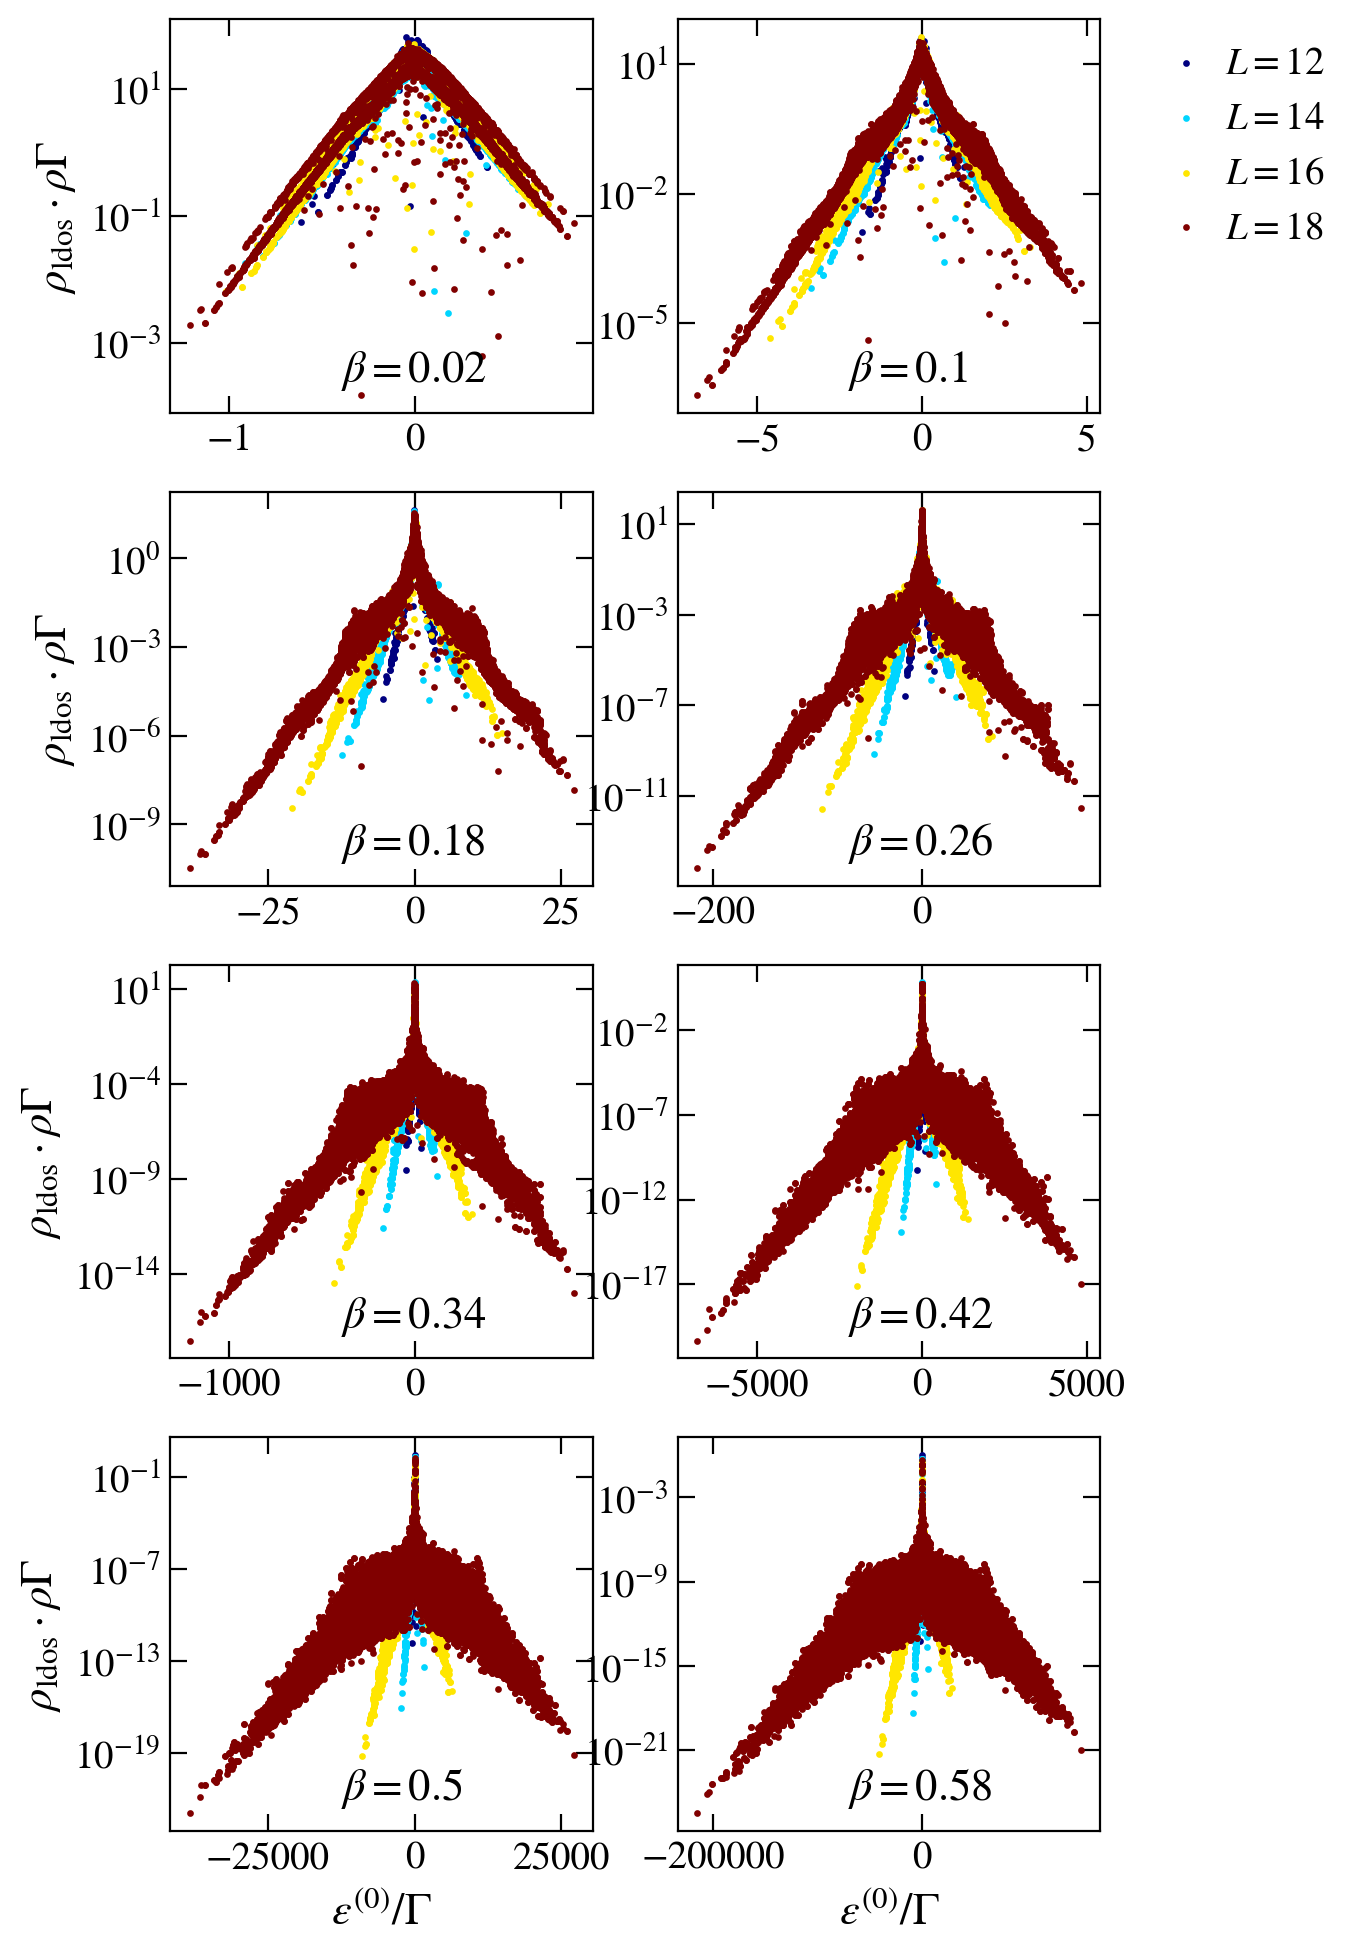

In [368]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0

use_gap_or_weight = 0
BC = 0

prefix = '../results_fgr/disorder/OBC/' if BC else '../results_fgr/disorder/PBC/'
hz = 0
if not BC: use_gap_or_weight = 1

sizes = np.arange(12, 19, 2)

DIM = 1
fig, axis = plt.subplots( nrows=4, ncols=2, figsize=(6,12), dpi = 200, sharex=False, sharey=False)
axis = axis.flatten()

def lorenz(x, A, sig, G):
    return A / G / np.pi / ( (x / G)**2 + 1) * np.exp(-x**2 / (2*sig**2) ) /np.sqrt(2*np.pi*sig**2)
    # return A / np.sqrt(2*np.pi*sig**2) * np.exp(-x**2 / (2*sig**2))

norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])


L = 15
eps = 0.5
gamma_c = 2


gx = 1.2

dim = 2**L

betas = np.arange(0.02, 0.59, 0.08)

for iig, wx in enumerate(betas):
    for ii, L in enumerate(sizes):
        dim = binom(L, L//2)   
        col = s_m.to_rgba(L)
        num = min([100, dim//50])
        name = prefix + 'Fractality/' + info_dis(L=L, J1=J, delta1=0.55, w=wx, hz=hz) + '.hdf5'
        if exists(name):
            with h5py.File(name, "r") as file:
                DOS = max( np.array(file.get('DOS0')) )
                HSnorm = 1
                G = np.pi * dim**(-2*wx) * HSnorm * DOS / (dim - 1.0)
                
                E = (np.array(file.get('mean energies0'))) / G
                Cn = np.mean(np.array(file.get('coeff')),axis=0) * G * DOS
                # print(E, Cn)
                
                if iig == 1: axis[iig].scatter( E, Cn, color=col, label=r"$L=%d$"%L, s=2)
                else:        axis[iig].scatter( E, Cn, color=col, s=2)
        else:
            print(name)
        

    # z = np.linspace(min(xx), max(xx), 100000)
    # G = 1#0.05
    # yy = G / 80 / ( z**2 + G**2)
    # axis[iig].plot(z, yy, ls='--', color='k', lw=2, alpha=0.6, label=r"$\frac{A}{(\omega)^2+1}$")
    # axis.plot(np.nan, np.nan, ls='--', color='k', label=r"$\frac{A}{(\omega/\Gamma)^2+1}e^{-\frac{E^2}{(2\sigma^2)}}$")
    axis[iig].annotate(r" $\beta=%g$"%wx, fontsize=16, xy=(0.38, 0.08), xycoords='axes fraction')
    fig_help.set_plot_elements(axis[iig], ylabel=r"$\rho_{\rm ldos}\cdot\rho\Gamma$" if iig%2==0 else "", xlabel=r"$\epsilon^{(0)}/\Gamma$" if iig > len(axis)-3 else "", font_size=14, set_legend=1, xscale='linear', yscale='log')
    fig_help.set_legend(axis[iig], fontsize=14, loc='upper left', anchor=(1.05, 1.02), ncol=1)


13.858912037037037

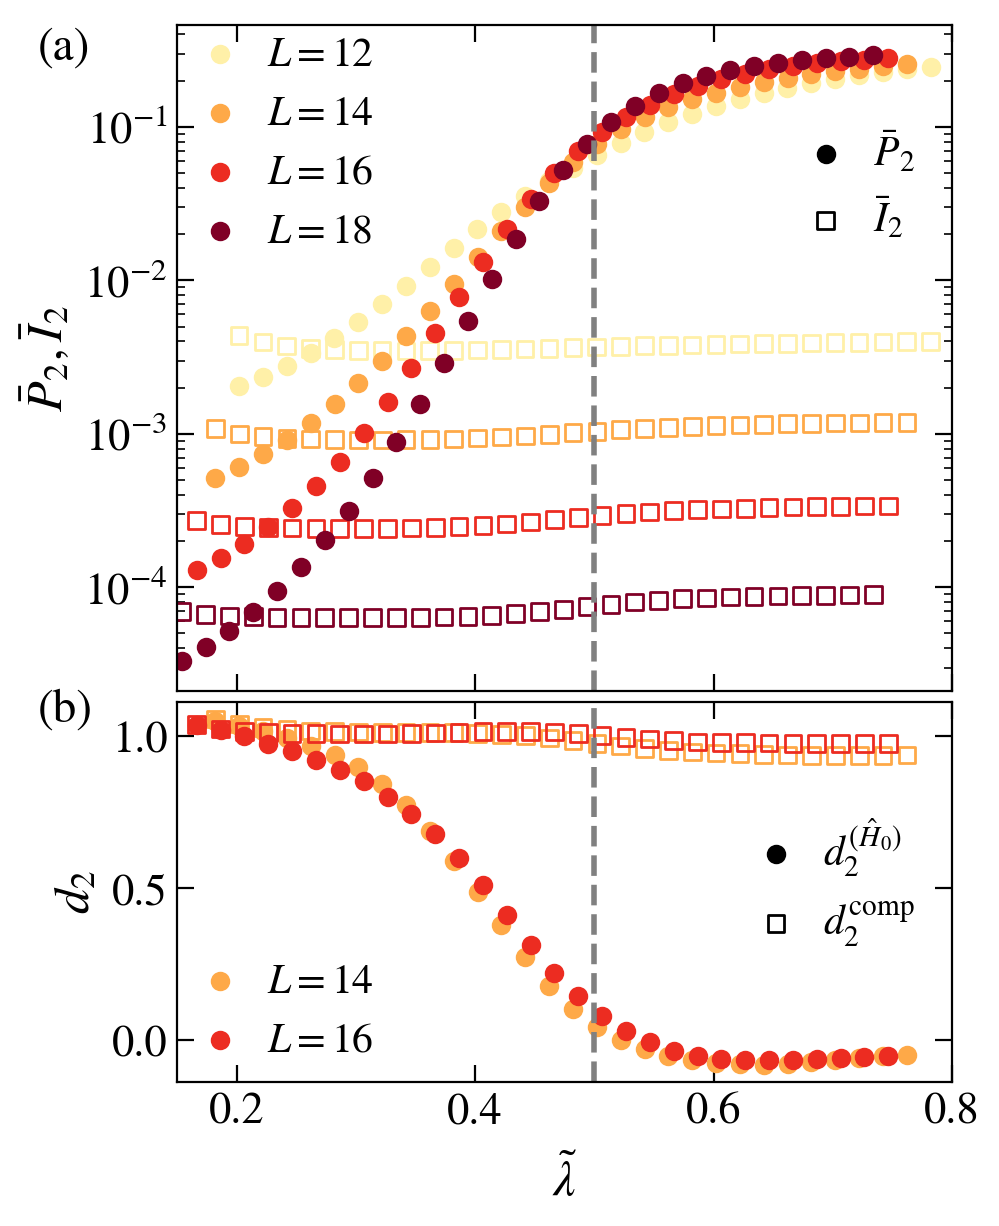

In [189]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0

use_gap_or_weight = 0
BC = 0

prefix = '../results_fgr/disorder/OBC/' if BC else '../results_fgr/disorder/PBC/'
hz = 0
if not BC: use_gap_or_weight = 1

sizes = np.arange(12, 19, 2)

# norm = matplotlib.colors.Normalize(
#         vmin=min(sizes),
#         vmax=max(sizes) )


# # create a ScalarMappable and initialize a data structure
# upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
# colors = np.vstack((upper))  
# mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

# s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
# s_m.set_array([])

# fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5, 3), dpi = 200, sharex=True)
fig = plt.figure(figsize=(5,7), dpi = 200)
fig.subplots_adjust(hspace=0.0)
gs = GridSpec(2, 1, height_ratios = [7, 4]) 
# gs1 = GridSpec(1,1)
# gs.update(top=0.98, bottom=0.48, hspace=0.02)
# gs1.update(top=0.4, bottom=0.02)
ax = fig.add_subplot(gs[0])
axis = fig.add_subplot(gs[1])

beta_c = 0.5


q = 2

def _fun_pr(D, a, d2):
    return a * D**(-d2)
q_list = [0.5, 1.2, 1.5, 2.4, 3.0]
norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))

# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])
# col = s_m.to_rgba(q)
betas = np.arange(0.02, 0.61, 0.02)
d2 = np.zeros( (betas.size))
d2_comp = np.zeros( (betas.size) )

d2_L = []
d2_comp_L = []
pr_L = []
pr_comp_L = []
for ii, wx in enumerate(betas):
    
    pr       = np.zeros((sizes.size));                  pr.fill(np.nan)
    Sinfo    = np.zeros((sizes.size));                  Sinfo.fill(np.nan)
    pr_comp       = np.zeros((sizes.size));             pr_comp.fill(np.nan)
    Sinfo_comp    = np.zeros((sizes.size));             Sinfo_comp.fill(np.nan)
    
    dims = binom(sizes, sizes//2)
    for iiL, L in enumerate(sizes):
        col = s_m.to_rgba(L)
        dim = binom(L, L//2)
        name = prefix + 'Fractality/' + info_dis(L=L, J1=J, delta1=0.55, w=wx, hz=hz) + '.hdf5'
        
        if exists(name):
            with h5py.File(name, "r") as file:
                # q = 2
                qs = np.array(file.get('qs'))
                iddx = np.argmin(np.abs(qs - q))
                # print(q, qs[iddx])
                pr[iiL] = np.mean(np.array(file.get('Pr'))[iddx])
                Sinfo[iiL] = np.mean(np.array(file.get('InfoPr'))[iddx])
                
                X = np.array(file.get('Pr_comp'))[iddx]
                # print(X.shape)
                X = X[~np.isnan(X)]
                pr_comp[iiL] = np.mean(X)
                Sinfo_comp[iiL] = np.mean(np.array(file.get('InfoPr_comp'))[iddx])
                # print(np.array(file.get('InfoPr_comp'))[iddx].shape)
        else:
            print(name)
    pr_L.append(pr)
    pr_comp_L.append(pr_comp)
    
    a = -np.diff(np.log(pr_comp)) / np.diff(np.log(dims))
    d2_comp_L.append( (a[1:] + a[:-1]) / 2)
    a = -np.diff(np.log(pr)) / np.diff(np.log(dims))
    d2_L.append( (a[1:] + a[:-1]) / 2)
    
    pars, pconv, fit_info, msg, _ = fit(_fun_pr,
                        xdata = dims,
                        ydata = pr_comp,
                        full_output=True, maxfev=20000)
    d2_comp[ii] = pars[-1] / (q - 1)
    
    pars, pconv, fit_info, msg, _ = fit(_fun_pr,
                        xdata = dims,
                        ydata = pr,
                        full_output=True, maxfev=20000)
    d2[ii] = pars[-1] / (q - 1)
    # n = parsolo[1]

# axis.scatter(betas, d2, color='k')
# axis.scatter(betas, d2_comp, color='k', marker='s', facecolor='None')

handles = []
d2_L = np.transpose(np.array(d2_L))
d2_comp_L = np.transpose(np.array(d2_comp_L))
for iiL, L in enumerate( sizes[1:-1] ):
    col = s_m.to_rgba(L)
    sc = axis.scatter(betas + np.log(L) / (2*np.log(binom(L, L//2))), d2_L[iiL], color=col, label = r"$L=%d$"%L); handles.append(sc)
    axis.scatter(betas + np.log(L) / (2*np.log(binom(L, L//2))), d2_comp_L[iiL], color=col, marker='s', facecolor='None')
sc = axis.scatter(np.nan, np.nan, color='k', label=r"$d_2^{(\hat{H}_0)}$"); handles.append(sc)
sc = axis.scatter(np.nan, np.nan, color='k', marker='s', facecolor='None', label=r"$d_2^{\rm comp}$"); handles.append(sc)
    
axis.set_xlim(0.15, 0.8)
ax.set_xlim(0.15, 0.8)

fig_help.set_plot_elements(axis, ylabel=r"$d_2$", xlabel=r"$\tilde{\lambda}$", font_size=16, set_legend=1, xscale='linear', yscale='linear')

leg = fig_help.set_legend(axis, loc='upper right', fontsize=15, anchor=(1.0, 0.8), handles = handles[-2:])
fig_help.set_legend(axis, loc='lower left', fontsize=15, anchor=(-0.04, -0.04), handles = handles[:-2])
fig.add_artist(leg)

handles = []
pr_L = np.transpose(np.array(pr_L))
pr_comp_L = np.transpose(np.array(pr_comp_L))
for iiL, L in enumerate( sizes ):
    col = s_m.to_rgba(L)
    sc = ax.scatter(betas + np.log(L) / (2*np.log(binom(L, L//2))), pr_L[iiL], color=col, label = r"$L=%d$"%L); handles.append(sc)
    ax.scatter(betas + np.log(L) / (2*np.log(binom(L, L//2))), pr_comp_L[iiL], color=col, marker='s', facecolor='None')

sc = ax.scatter(np.nan, np.nan, color='k', label=r"$\bar{P}_2$"); handles.append(sc)
sc = ax.scatter(np.nan, np.nan, color='k', marker='s', facecolor='None', label=r"$\bar{I}_2$"); handles.append(sc)

axis.axvline(x=0.5, ls='--', color='gray', lw=2)
ax.axvline(x=0.5, ls='--', color='gray', lw=2)

fig_help.set_plot_elements(ax, ylabel=r"$\bar{P}_2,\bar{I}_2$", xlabel=r"$\tilde{\lambda}$", font_size=16, set_legend=1, xscale='linear', yscale='log')

leg = fig_help.set_legend(ax, loc='upper right', fontsize=15, anchor=(1.0, 0.9), handles = handles[-2:])
fig_help.set_legend(ax, loc='upper left', fontsize=15, anchor=(-0.04, 1.04), handles = handles[:-2])
fig.add_artist(leg)

fig.subplots_adjust(wspace = 0.02, hspace=0.02)
# fig_help.set_plot_elements(axis[2], ylabel=r"$d_2$", xlabel=r"$\alpha$", font_size=16, set_legend=1, xscale='linear', yscale='linear')
ax.set_xticklabels(["", "", "", ""])

axis.annotate(r"(b)", fontsize=17, xy=(-0.18, 0.95), xycoords='axes fraction')
ax.annotate(r"(a)", fontsize=17, xy=(-0.18, 0.95), xycoords='axes fraction')
fig.savefig("PLOTS_FADING/Fig_ipr.pdf", bbox_inches = 'tight', pad_inches=0.02)

Text(-0.18, 0.95, '(a)')

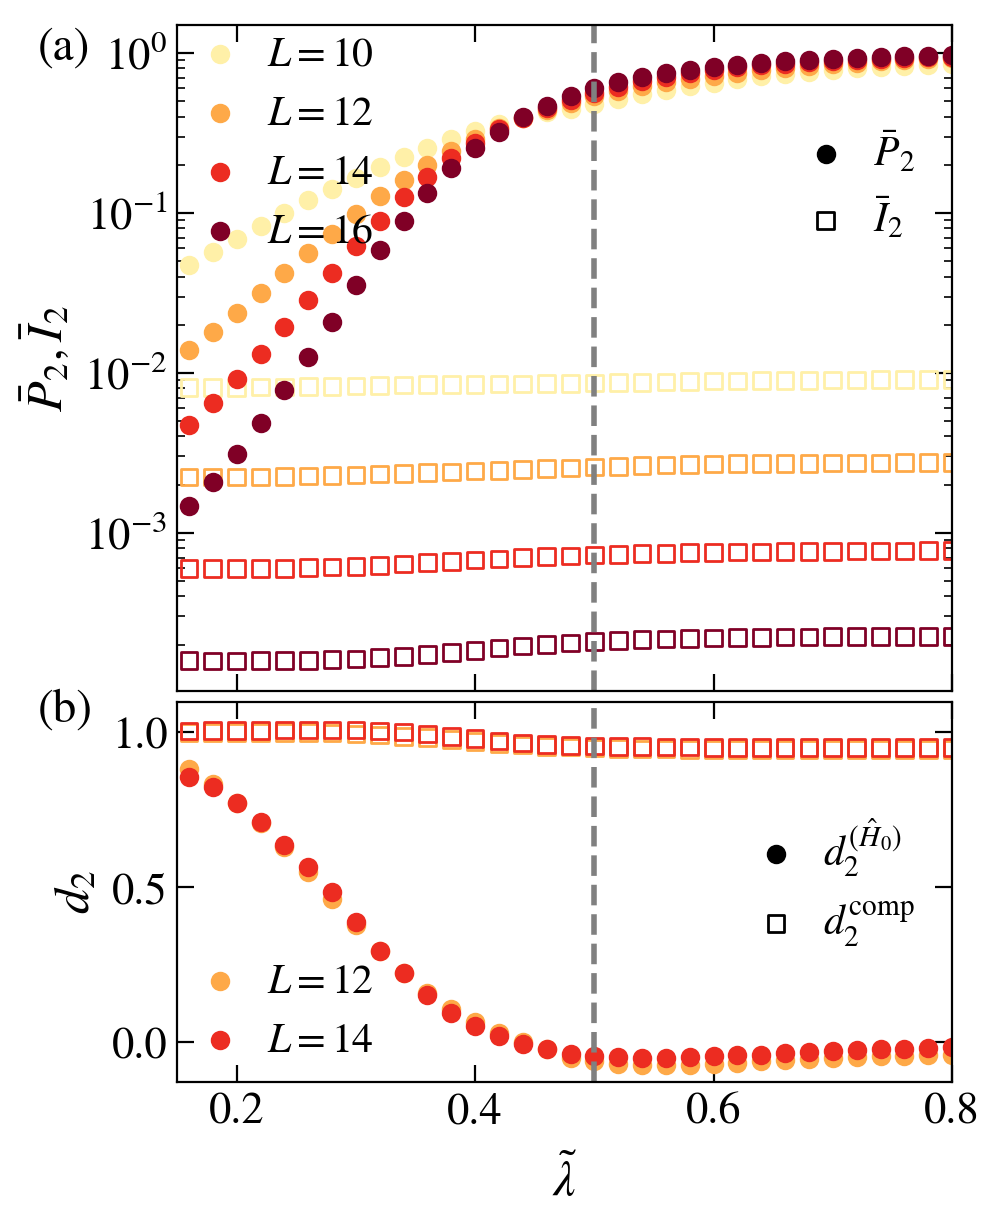

In [295]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0

ADD_CURRENT = 1

use_gap_or_weight = 0
BC = 0

prefix = '../results_fgr2/disorder/PBC/Spectrals_SzSz/'


sizes = np.arange(10, 17, 2)

# fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5, 3), dpi = 200, sharex=True)
fig = plt.figure(figsize=(5,7), dpi = 200)
fig.subplots_adjust(hspace=0.0)
gs = GridSpec(2, 1, height_ratios = [7, 4]) 
# gs1 = GridSpec(1,1)
# gs.update(top=0.98, bottom=0.48, hspace=0.02)
# gs1.update(top=0.4, bottom=0.02)
ax = fig.add_subplot(gs[0])
axis = fig.add_subplot(gs[1])

beta_c = 0.5


q = 2

def _fun_pr(D, a, d2):
    return a * D**(-d2)
q_list = [0.5, 1.2, 1.5, 2.4, 3.0]
norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))

# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])
# col = s_m.to_rgba(q)

betas = np.arange(0.02, 0.81, 0.02)
d2 = np.zeros( (betas.size))
d2_comp = np.zeros( (betas.size) )

d2_L = []
d2_comp_L = []
pr_L = []
pr_comp_L = []
for ii, wx in enumerate(betas):
    
    pr       = np.zeros((sizes.size));                  pr.fill(np.nan)
    Sinfo    = np.zeros((sizes.size));                  Sinfo.fill(np.nan)
    pr_comp       = np.zeros((sizes.size));             pr_comp.fill(np.nan)
    Sinfo_comp    = np.zeros((sizes.size));             Sinfo_comp.fill(np.nan)
    
    dims = binom(sizes, sizes//2)
    for iiL, L in enumerate(sizes):
        col = s_m.to_rgba(L)
        dim = binom(L, L//2)
        name = prefix + info_dis(L=L, J1=J, delta1=0.55, w=wx, hz=hz) + '.hdf5'
        
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('average energies'))
                
                Eav = np.mean(Ex)
                idx = int( min(range(len(Ex)), key=lambda i: abs(Ex[i] - Eav)) )
                num = int( min([500, dim//10]) )
                
                # print(idx, idx - num//2)
                pr[iiL] = np.mean(np.array(file.get('Pr'))[idx - num//2 : idx + num//2])
                
                X = np.array(file.get('Pr_comp'))[idx - num//2 : idx + num//2]
                # print(X.shape)
                X = X[~np.isnan(X)]
                pr_comp[iiL] = np.mean(X)
                # print(np.array(file.get('InfoPr_comp'))[iddx].shape)
        else:
            print(name)
    pr_L.append(pr)
    pr_comp_L.append(pr_comp)
    
    a = -np.diff(np.log(pr_comp)) / np.diff(np.log(dims))
    d2_comp_L.append( (a[1:] + a[:-1]) / 2)
    a = -np.diff(np.log(pr)) / np.diff(np.log(dims))
    d2_L.append( (a[1:] + a[:-1]) / 2)
    
    pars, pconv, fit_info, msg, _ = fit(_fun_pr,
                        xdata = dims,
                        ydata = pr_comp,
                        full_output=True, maxfev=20000)
    d2_comp[ii] = pars[-1] / (q - 1)
    
    pars, pconv, fit_info, msg, _ = fit(_fun_pr,
                        xdata = dims,
                        ydata = pr,
                        full_output=True, maxfev=20000)
    d2[ii] = pars[-1] / (q - 1)
    # n = parsolo[1]

# axis.scatter(betas, d2, color='k')
# axis.scatter(betas, d2_comp, color='k', marker='s', facecolor='None')

handles = []
d2_L = np.transpose(np.array(d2_L))
d2_comp_L = np.transpose(np.array(d2_comp_L))
for iiL, L in enumerate( sizes[1:-1] ):
    col = s_m.to_rgba(L)
    sc = axis.scatter(betas, d2_L[iiL], color=col, label = r"$L=%d$"%L); handles.append(sc)
    axis.scatter(betas, d2_comp_L[iiL], color=col, marker='s', facecolor='None')
sc = axis.scatter(np.nan, np.nan, color='k', label=r"$d_2^{(\hat{H}_0)}$"); handles.append(sc)
sc = axis.scatter(np.nan, np.nan, color='k', marker='s', facecolor='None', label=r"$d_2^{\rm comp}$"); handles.append(sc)
    
axis.set_xlim(0.15, 0.8)
ax.set_xlim(0.15, 0.8)

fig_help.set_plot_elements(axis, ylabel=r"$d_2$", xlabel=r"$\tilde{\lambda}$", font_size=16, set_legend=1, xscale='linear', yscale='linear')

leg = fig_help.set_legend(axis, loc='upper right', fontsize=15, anchor=(1.0, 0.8), handles = handles[-2:])
fig_help.set_legend(axis, loc='lower left', fontsize=15, anchor=(-0.04, -0.04), handles = handles[:-2])
fig.add_artist(leg)

handles = []
pr_L = np.transpose(np.array(pr_L))
pr_comp_L = np.transpose(np.array(pr_comp_L))
for iiL, L in enumerate( sizes ):
    col = s_m.to_rgba(L)
    sc = ax.scatter(betas, pr_L[iiL], color=col, label = r"$L=%d$"%L); handles.append(sc)
    ax.scatter(betas, pr_comp_L[iiL], color=col, marker='s', facecolor='None')

sc = ax.scatter(np.nan, np.nan, color='k', label=r"$\bar{P}_2$"); handles.append(sc)
sc = ax.scatter(np.nan, np.nan, color='k', marker='s', facecolor='None', label=r"$\bar{I}_2$"); handles.append(sc)

axis.axvline(x=0.5, ls='--', color='gray', lw=2)
ax.axvline(x=0.5, ls='--', color='gray', lw=2)

fig_help.set_plot_elements(ax, ylabel=r"$\bar{P}_2,\bar{I}_2$", xlabel=r"$\tilde{\lambda}$", font_size=16, set_legend=1, xscale='linear', yscale='log')

leg = fig_help.set_legend(ax, loc='upper right', fontsize=15, anchor=(1.0, 0.9), handles = handles[-2:])
fig_help.set_legend(ax, loc='upper left', fontsize=15, anchor=(-0.04, 1.04), handles = handles[:-2])
fig.add_artist(leg)

fig.subplots_adjust(wspace = 0.02, hspace=0.02)
# fig_help.set_plot_elements(axis[2], ylabel=r"$d_2$", xlabel=r"$\alpha$", font_size=16, set_legend=1, xscale='linear', yscale='linear')
ax.set_xticklabels(["", "", "", ""])

axis.annotate(r"(b)", fontsize=17, xy=(-0.18, 0.95), xycoords='axes fraction')
ax.annotate(r"(a)", fontsize=17, xy=(-0.18, 0.95), xycoords='axes fraction')
# fig.savefig("PLOTS_FADING/Fig_ipr.pdf", bbox_inches = 'tight', pad_inches=0.02)

12 0.31192476052551005 3.743097126306121 1.0805390667378767
14 0.2780257200989501 3.892360081385301 1.0402769893213808
16 0.25134534666222125 4.02152554659554 1.005381386648885
18 0.2298590945104965 4.137463701188937 0.9752095466746294


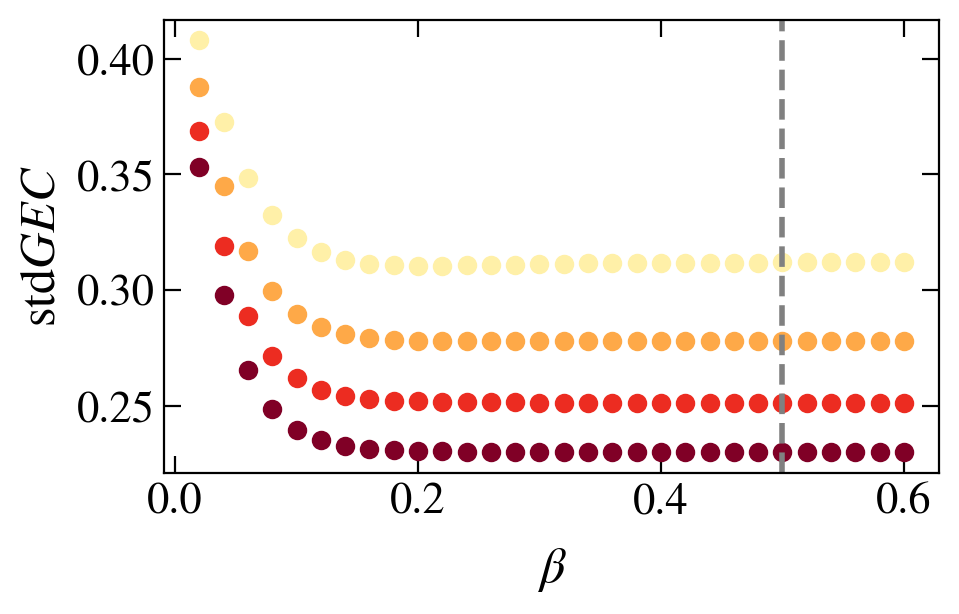

In [3]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0

use_gap_or_weight = 0
BC = 0

prefix = '../results_fgr/disorder/OBC/' if BC else '../results_fgr/disorder/PBC/'
hz = 0
if not BC: use_gap_or_weight = 1

sizes = np.arange(12, 19, 2)

# norm = matplotlib.colors.Normalize(
#         vmin=min(sizes),
#         vmax=max(sizes) )


# # create a ScalarMappable and initialize a data structure
# upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
# colors = np.vstack((upper))  
# mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

# s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
# s_m.set_array([])

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5, 3), dpi = 200, sharex=True)

beta_c = 0.5


q = 2

def _fun_pr(D, a, d2):
    return a * D**(-d2)
q_list = [0.5, 1.2, 1.5, 2.4, 3.0]

norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))

# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])

# for q in q_list:

betas = np.arange(0.02, 0.61, 0.02)
d2 = np.zeros( (betas.size))
d2_comp = np.zeros( (betas.size) )
for iiL, L in enumerate(sizes):
    col = s_m.to_rgba(L)
    dim = binom(L, L//2)
    var_gec = np.zeros((betas.size));
    for ii, wx in enumerate(betas):
        name = prefix + 'Fractality/' + info_dis(L=L, J1=J, delta1=0.55, w=wx, hz=hz) + '.hdf5'
        if exists(name):
            with h5py.File(name, "r") as file:
                # q = 2
                gec = np.array(file.get('gec'))
                gec2 = np.array(file.get('gec2'))
                
                var_gec[ii] = (np.mean(gec2) - np.mean(gec)**2)*dim**2
        else:
            print(name)

    axis.scatter(betas, var_gec, color=col)
    print(L, np.mean(var_gec[-10:]), L * np.mean(var_gec[-10:]), np.sqrt(L) * np.mean(var_gec[-10:]))
    # axis.axhline(y=1/np.sqrt(L), ls='--', color=col, lw=2)

axis.axvline(x=beta_c, ls='--', color='gray', lw=2)

fig_help.set_plot_elements(axis, ylabel=r"${\rm std}{GEC}$", xlabel=r"$\beta$", font_size=16, set_legend=0, xscale='linear', yscale='linear')
# fig_help.set_plot_elements(axis[2], ylabel=r"$d_2$", xlabel=r"$\alpha$", font_size=16, set_legend=1, xscale='linear', yscale='linear')

## SPECTRAL FUNCTIONS

No handles with labels found to put in legend.


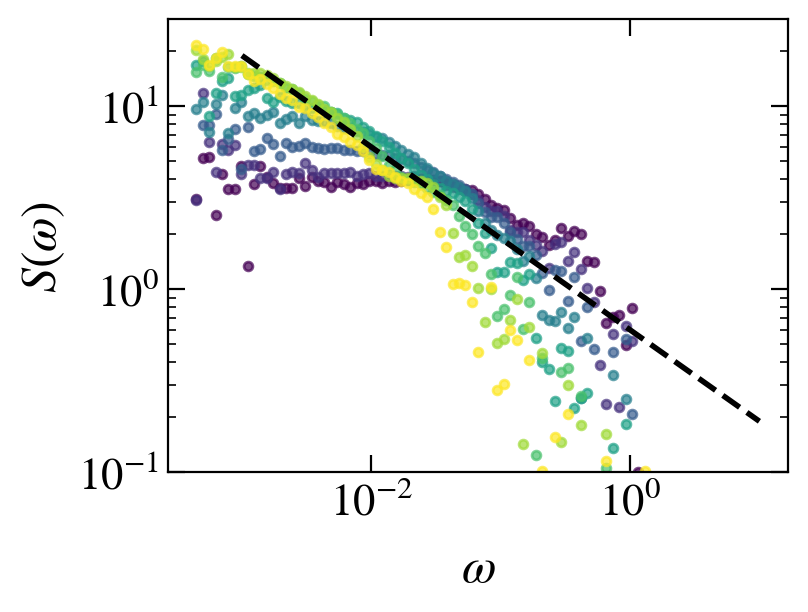

In [266]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0

BC = 0

prefix = '../results_fgr/disorder/OBC/Spectrals_SzSz/' if BC else '../results_fgr/disorder/PBC/Spectrals_SzSz/'
# prefix = '../results/disorder/OBC/Spectrals_SzSz/' if BC else '../results/disorder/PBC/Spectrals_SzSz/'
prefix = '../results_fgr2/disorder/PBC/Spectrals_SzSz/'
# prefix = '../results/disorder/OBC/Spectrals_energy_current/'
# prefix = '../results/disorder/OBC/Spectrals_Sz0/'
# prefix = '../results_fgr/disorder/ABC/Spectrals_kinetic/'
hz = 0

sizes = np.arange(12, 15, 2)

DIM = 1
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200, sharex=True, sharey=False)

L = 14
eps = 0.5

# wx_vals = np.arange(0.04, 0.71, 0.04)
wx_vals = np.arange(0.02, 0.61, 0.08)

norm = matplotlib.colors.Normalize(
        vmin=min(wx_vals),
        vmax=max(wx_vals))
s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])


L=10
wx = 0.2
# for iiL, L in enumerate(sizes):
for iiL, wx in enumerate(wx_vals):
    dim = int( binom(L, L//2) )

    col = s_m.to_rgba(wx)
    
    omegas = np.nan
    spec_fun = np.nan
    name = prefix + info_dis(L=L, J1=J, delta1=0.55, w=wx, hz=hz) + '.hdf5'
    if exists(name):
        with h5py.File(name, "r") as file:
            Ex = np.array(file.get('energy_density'))
            idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
            DOS = np.array(file.get('DOS'))[idx]
            wH = np.array(file.get('wH'))[0]
            
            G = 1#dim**(1-2*w) * L**2
            # spec_fun = np.array(file.get('spec_fun'))[idx]# - np.array(file.get('spec_fun0'))[idx]
            spec_fun = np.array(file.get('spec_fun_all')) - np.array(file.get('spec_fun_all0'))
            spec_fun = spec_fun * DOS * G
            # spec_fun0 = np.array(file.get('int_spec_fun0'))[idx]
            # spec_fun0 = (spec_fun0 - spec_fun0[0]) / (spec_fun0[-1] - spec_fun0[0])
            # spec_fun = np.array(file.get('int_spec_fun'))[idx]
            # spec_fun = (spec_fun - spec_fun[0]) / (spec_fun[-1] - spec_fun[0])
            omegas = np.array(file.get('omegas'))[1:] / G
            
            realis = np.array(file.get('realisations'))
            axis.scatter(omegas, spec_fun * omegas**0, color=col, alpha=0.7, s=10)
    else:
        print(name)
    
    
fig_help.set_plot_elements(axis, ylabel=r"$S(\omega)$", xlabel=r"$\omega$", font_size=16, set_legend=1, xscale='log', yscale='log')

z = np.logspace(-3, 1, 1000)
# axis.plot(z, 0.02/z, ls=':', color='k', lw=2)
axis.plot(z, 6e-1/z**0.5, ls='--', color='k', lw=2)
# axis.plot(z, 200*z**2, ls='-.', color='red', lw=2)

axis.set_ylim(1e-1, 3e1)

fig.subplots_adjust(wspace = 0.02, hspace=0.02)

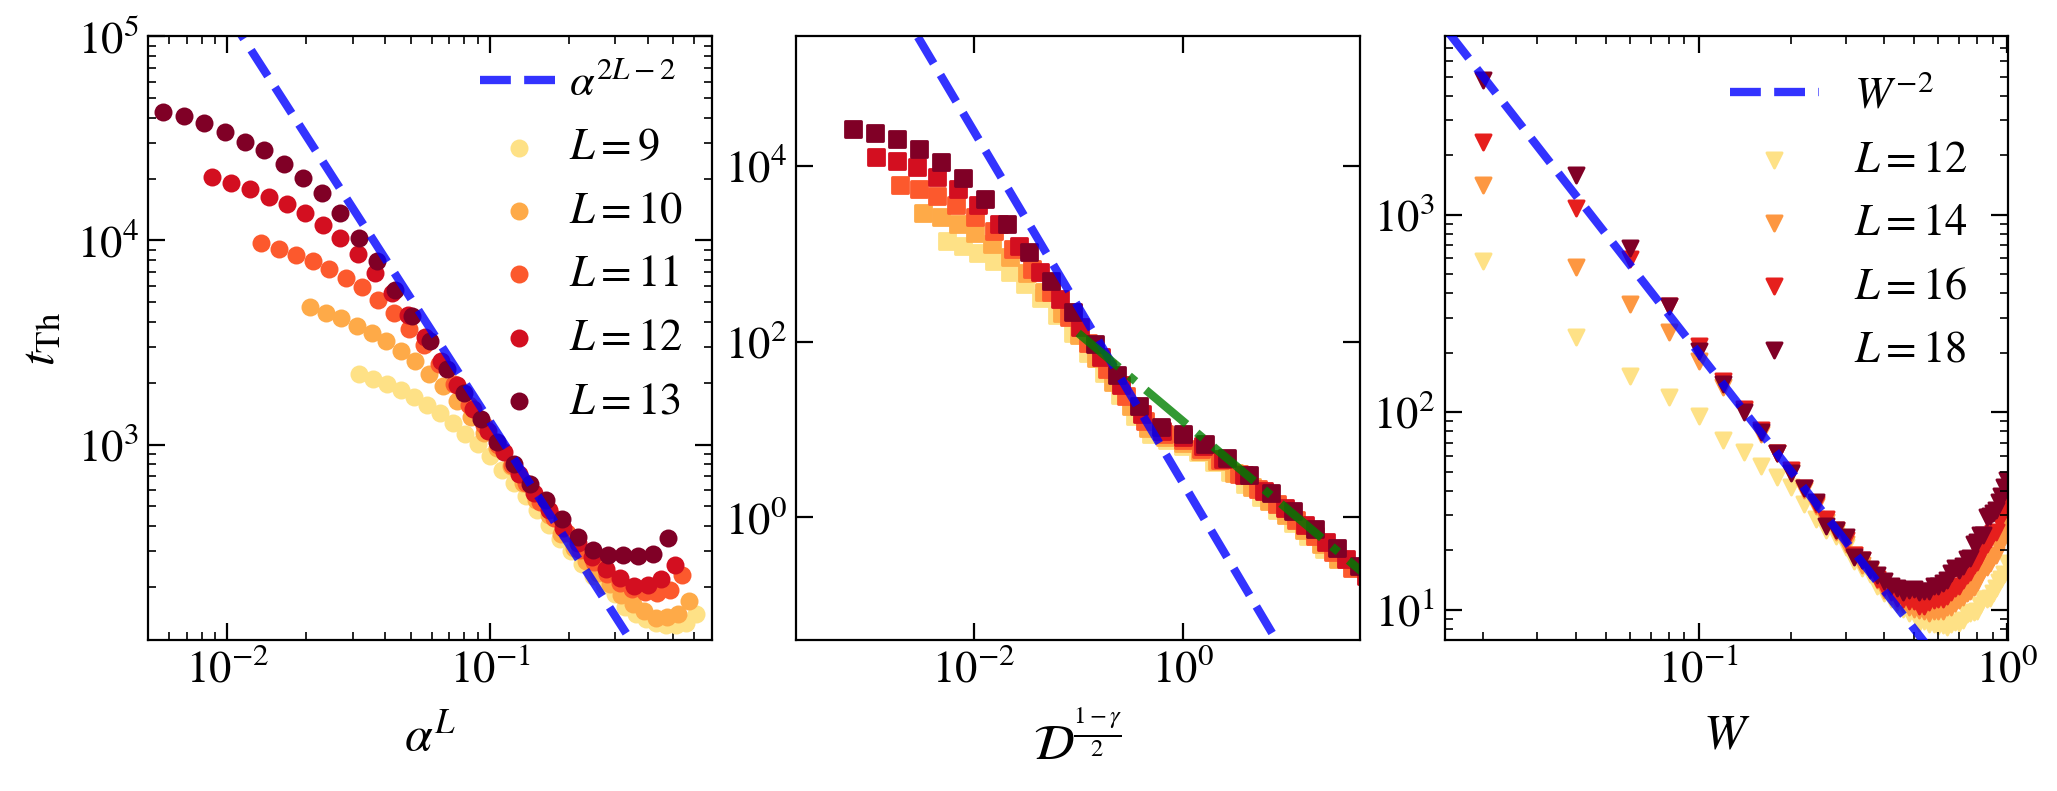

In [133]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

fig, axis = plt.subplots( nrows=1, ncols=3, figsize=(12,4), dpi = 200)#, sharex=True, sharey=False)

def L_colormap(siz):
    norm = matplotlib.colors.Normalize(
        vmin=min(siz),
        vmax=max(siz))
    # create a ScalarMappable and initialize a data structure
    upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.2, 1.0, 100))
    colors = np.vstack((upper))  
    mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)
    s_m_L = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
    s_m_L.set_array([])
    return s_m_L
# ------------------------------------------------------------ Quantum Sun Model
L_total=16
N=3
J=1
alfa=1.0
h=1.0
w=0.5
zeta=0.2
gamma=1.0
ini_ave=1
L = L_total - N
scaled_disorder=0

folder = f'/Users/rafal.swietek/Projects/CODES/QHamSolver/QuantumSun/Jupyter_Python/thouless time/'
sizes = np.arange(12, 17,1)
s_m_L = L_colormap(sizes)
for Ltot in sizes:
    col = s_m_L.to_rgba(Ltot)
    L = Ltot - N
    name_out = folder + f'_L={L},N={N},J={J},w={w},ini_ave={ini_ave}.hdf5'
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            alfa_vals  = np.array(file.get('interaction'))
            tH         = np.array(file.get('heisenberg time'))
            tH_typ     = np.array(file.get('typical heisenberg time'))
            t_Th       = np.array(file.get('thouless time')) * tH_typ
            axis[0].scatter(alfa_vals**(L-1), t_Th, color=col, s=30, marker='o', label=r"$L=%d$"%L)
            # axis[0].scatter(alfa_vals, t_Th/L**2, color=col, s=30, marker='o', label=r"$L=%d$"%L)
    else:
        print(name_out)
        
z = np.linspace(0.01, 0.5, 1000)
axis[0].plot(z, 13/z**2, ls='--', color='blue', lw=3, alpha=0.8, label=r"$\alpha^{2L-2}$")
fig_help.set_plot_elements(axis[0], ylabel=r"$t_{\rm Th}$", xlabel=r"$\alpha^L$", font_size=16, set_legend=1, xscale='log', yscale='log')
fig_help.set_legend(axis[0], loc='upper right')
axis[0].set_ylim(1.1e2, 1e5)
axis[0].set_xlim(5e-3, 0.7)
# ------------------------------------------------------------ Rosenzweig Porter model
sizes = np.arange(10, 15, 1)
s_m_L = L_colormap(sizes)
for L in sizes:
    dim = 2**L
    col = s_m_L.to_rgba(L)
    name_out = f'/Users/rafal.swietek/Projects/CODES/QHamSolver/Quadratic/Jupyter_Python/thouless time/_L=%d.hdf5'%L
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            gx  = np.array(file.get('interaction'))
            tH         = np.array(file.get('heisenberg time'))
            tH_typ     = np.array(file.get('typical heisenberg time'))
            t_Th       = np.array(file.get('thouless time')) * tH_typ#dim / np.sqrt(1 + dim**(1-gx))# * tH_typ
            axis[1].scatter( dim**( (1-gx) / 2. ), t_Th/L**0, color=col, s=30, marker='s', label=r"$L=%d$"%L)
    else:
        print(name_out)

z = np.logspace(-4, 2, 1000)
axis[1].plot(z, np.sqrt(2*np.pi) / z**2, ls='--', color='blue', lw=3, alpha=0.8, label=r"$\mathcal{D}^{1-\gamma}$")
z = np.logspace(-1, 2, 1000)
axis[1].plot(z, (4*np.pi) / (z) / dim**0, ls='-.', color='green', lw=3, alpha=0.8, label=r"$\sigma_E^{-1}$")

axis[1].set_ylim(4e-2 / L**0, 3e5/L**0)
axis[1].set_xlim(2e-4, 50)
fig_help.set_plot_elements(axis[1], ylabel=r"", xlabel=r"$\mathcal{D}^{\frac{1-\gamma}{2}}$", font_size=16, set_legend=0, xscale='log', yscale='log')
# ------------------------------------------------------------ XXZ Chain
fname = "ThoulessTime_XXZ_vs_w.hdf5"
with h5py.File(fname, "r") as f:
    siz = np.array(f.get('sizes'))
    s_m_L = L_colormap(siz)
    for iiL, L in enumerate(siz):
        taus = np.array(f.get('taus'))[iiL]
        dis = np.array(f.get('disorder'))[iiL]
        axis[2].scatter(dis, taus, color=s_m_L.to_rgba(L), s=30, marker='v', label=r"$L=%d$"%L, zorder=0)
    

z = np.linspace(0.0, 0.8, 1000)
axis[2].plot(z, 2/z**2, ls='--', color='blue', lw=3, alpha=0.8, label=r"$W^{-2}$", zorder=10)
fig_help.set_plot_elements(axis[2], ylabel=r"", xlabel=r"$W$", font_size=16, set_legend=1, xscale='log', yscale='log')
axis[2].set_xlim(0.015, 1.01)
axis[2].set_ylim(7e0, 8e3)

fig.subplots_adjust(wspace = 0.15, hspace=0.02)


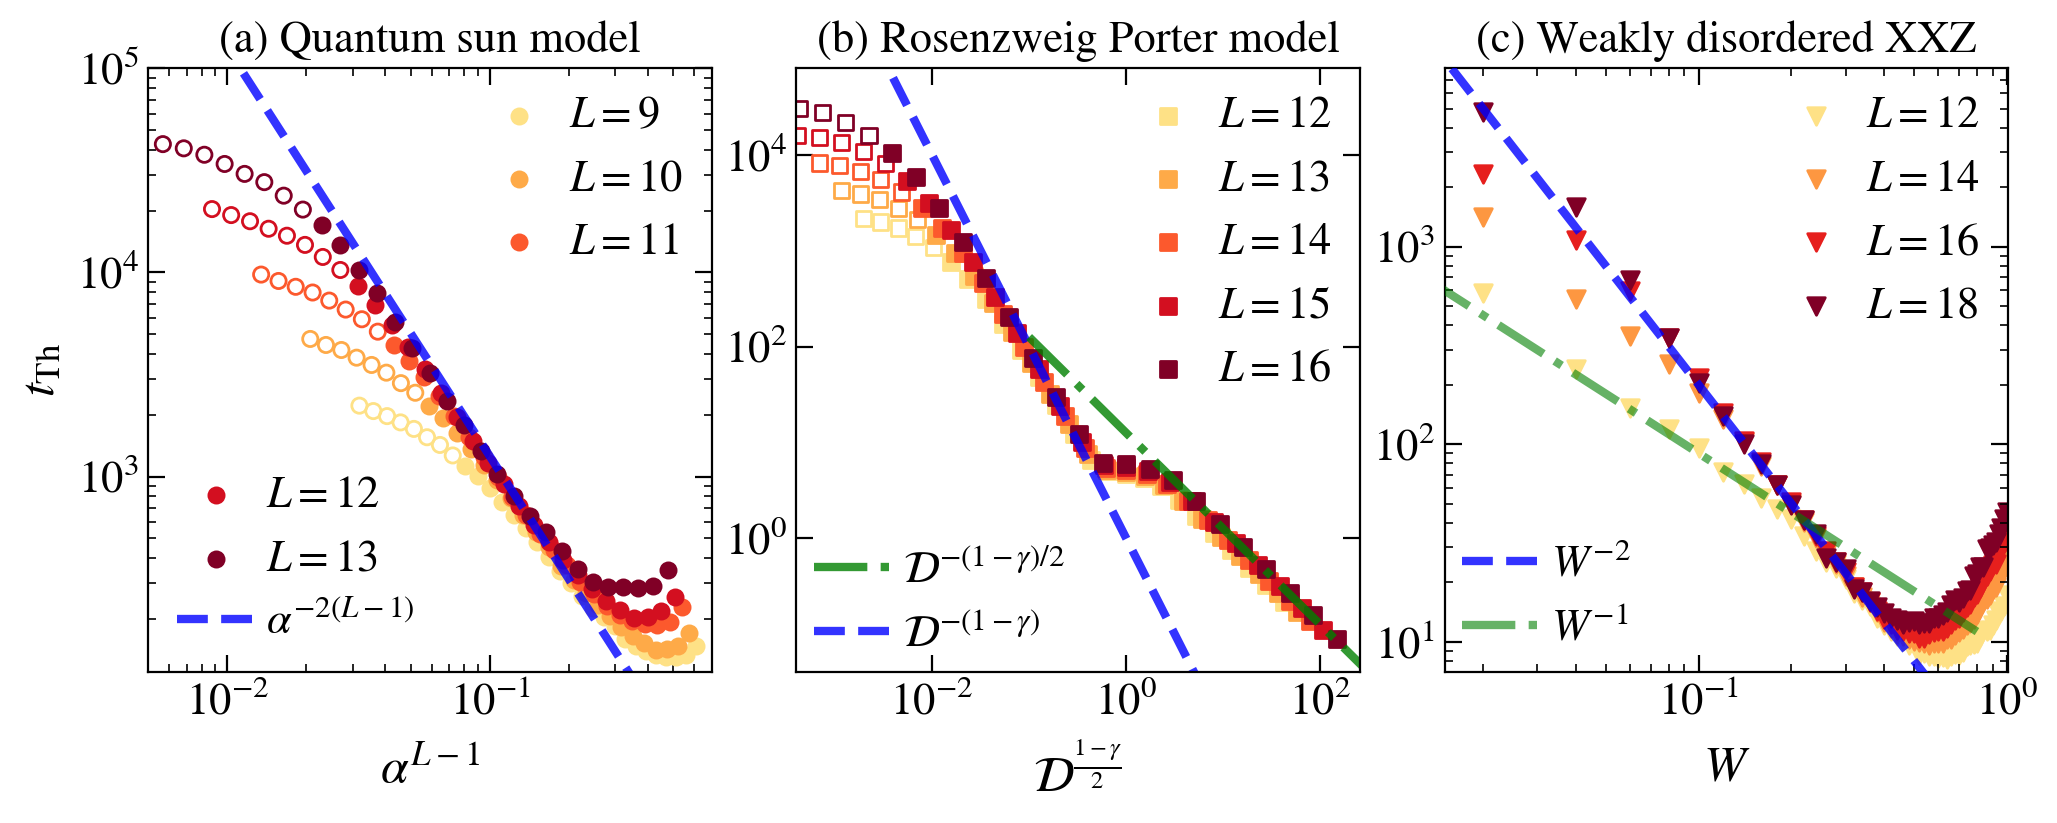

In [167]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

fig, axis = plt.subplots( nrows=1, ncols=3, figsize=(12,4), dpi = 200)#, sharex=True, sharey=False)

def L_colormap(siz):
    norm = matplotlib.colors.Normalize(
        vmin=min(siz),
        vmax=max(siz))
    # create a ScalarMappable and initialize a data structure
    upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.2, 1.0, 100))
    colors = np.vstack((upper))  
    mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)
    s_m_L = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
    s_m_L.set_array([])
    return s_m_L
# ------------------------------------------------------------ Quantum Sun Model
L_total=16
N=3
J=1
alfa=1.0
h=1.0
w=0.5
zeta=0.2
gamma=1.0
ini_ave=1
L = L_total - N
scaled_disorder=0
alfa_c = 0.73

folder = f'/Users/rafal.swietek/Projects/CODES/QHamSolver/QuantumSun/Jupyter_Python/thouless time/'
sizes = np.arange(12, 17,1)
s_m_L = L_colormap(sizes)
handles = []
for Ltot in sizes:
    col = s_m_L.to_rgba(Ltot)
    L = Ltot - N
    name_out = folder + f'_L={L},N={N},J={J},w={w},ini_ave={ini_ave}.hdf5'
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            alfa_vals  = np.array(file.get('interaction'))
            # print(alfa_vals)
            tH         = np.array(file.get('heisenberg time'))
            tH_typ     = np.array(file.get('typical heisenberg time'))
            t_Th       = np.array(file.get('thouless time')) * tH_typ
            
            indices = alfa_vals >= alfa_c
            sc = axis[0].scatter(alfa_vals[indices]**(L-1), t_Th[indices], color=col, s=30, marker='o', label=r"$L=%d$"%L)
            handles.append(sc)
            # rate = 2*np.pi / ( 1 + (alfa_vals**(2*L+2) - alfa_vals**2) / (alfa_vals**2 - 1) / 16 + L/4 * (1+1/12) )
            # axis[0].plot(alfa_vals[indices]**(L-1), rate[indices], color=col, ls='-', lw=2)
            # print(rate)
            indices = alfa_vals < alfa_c
            sc = axis[0].scatter(alfa_vals[indices]**(L-1), t_Th[indices], color=col, s=30, marker='o', label=r"$L=%d$"%L, facecolor='None')
            
    else:
        print(name_out)
        
z = np.logspace(-6, 1, 1000)
line, = axis[0].plot(z, 4*np.pi/z**2, ls='--', color='blue', lw=3, alpha=0.8, label=r"$\alpha^{-2(L-1)}$")
handles.append(line)
fig_help.set_plot_elements(axis[0], ylabel=r"$t_{\rm Th}$", xlabel=r"$\alpha^{L-1}$", font_size=16, set_legend=1, xscale='log', yscale='log')
leg = fig_help.set_legend(axis[0], loc='upper right', handles=handles[:3])
fig_help.set_legend(axis[0], loc='lower left', handles=handles[3:])
fig.add_artist(leg)

axis[0].set_ylim(1.1e2, 1e5)
axis[0].set_xlim(5e-3, 0.7)
axis[0].set_title(r"(a) Quantum sun model", fontsize=16)
# ------------------------------------------------------------ Rosenzweig Porter model
eps = 0.5
sizes = np.arange(12, 17, 1)
s_m_L = L_colormap(sizes)

handles = []
for L in sizes:
    dim = 2**L
    col = s_m_L.to_rgba(L)
    # name_out = f'/Users/rafal.swietek/Projects/CODES/QHamSolver/Quadratic/Jupyter_Python/thouless energy/GAUSSIAN/_L={L}_eps={eps}.hdf5'
    # if exists(name_out):
    #     with h5py.File(name_out, "r") as file:
    #         gx         = np.array(file.get('interaction'))
    #         tH         = 2*np.pi / np.array(file.get('heisenberg energy'))
    #         tH_typ     = 2*np.pi / np.array(file.get('typical heisenberg energy'))
    #         t_Th       = 2*np.pi / np.array(file.get('thouless energy'))
            
    #         indices = gx <= 2
    #         sc = axis[1].scatter( dim**( (1-gx[indices])/2 ), t_Th[indices], color=col, s=30, marker='s', label=r"$L=%d$"%L)
    #         handles.append(sc)
    #         indices = gx > 2
    #         sc = axis[1].scatter( dim**( (1-gx[indices])/2 ), t_Th[indices], color=col, s=30, marker='s', label=r"$L=%d$"%L, facecolor='None')
    # else:
    #     print(name_out)
    name_out = f'/Users/rafal.swietek/Projects/CODES/QHamSolver/Quadratic/Jupyter_Python/thouless time/_L=%d.hdf5'%L
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            gx         = np.array(file.get('interaction'))
            indices = gx > 0.
            gx = gx[indices]
            tH         = np.array(file.get('heisenberg time'))[indices]
            tH_typ     = np.array(file.get('typical heisenberg time'))[indices]
            t_Th       = np.array(file.get('thouless time'))[indices] * tH#dim / np.sqrt(1 + dim**(1-gx))# * tH_typ
            
            indices = gx <= 2
            sc = axis[1].scatter( dim**( (1-gx[indices]) / 2. ), t_Th[indices], color=col, s=30, marker='s', label=r"$L=%d$"%L)
            handles.append(sc)
            indices = gx > 2
            sc = axis[1].scatter( dim**( (1-gx[indices])/2 ), t_Th[indices], color=col, s=30, marker='s', label=r"$L=%d$"%L, facecolor='None')
    else:
        print(name_out)
z = np.logspace(-6, 3, 1000)
line, = axis[1].plot(z, 1 / z**2 / dim**0, ls='--', color='blue', lw=3, alpha=0.8, label=r"$\mathcal{D}^{-(1-\gamma)}$")
z = np.logspace(-1, 3, 1000)
# line2, = axis[1].plot(z, (2*np.pi) / np.sqrt(1+z**2) / dim**0, ls='-.', color='green', lw=3, alpha=0.8, label=r"$\sigma_E^{-1}$")
line2, = axis[1].plot(z, (4*np.pi) / (z) / dim**0, ls='-.', color='green', lw=3, alpha=0.8, label=r"$\mathcal{D}^{-(1-\gamma)/2}$")
# line2, = axis[1].plot(z, (4*np.pi) / np.sqrt(1 + z**2) / dim**0, ls='-.', color='green', lw=3, alpha=0.8, label=r"$\mathcal{D}^{-(1-\gamma)/2}$")
handles.append(line2)
handles.append(line)
axis[1].set_ylim(4e-2, 8e4)
axis[1].set_xlim(4e-4/dim**0., dim**0.5)
fig_help.set_plot_elements(axis[1], ylabel=r"", xlabel=r"$\mathcal{D}^{\frac{1-\gamma}{2}}$", font_size=16, set_legend=0, xscale='log', yscale='log')
leg = fig_help.set_legend(axis[1], loc='upper right', handles=handles[:5])
fig_help.set_legend(axis[1], loc='lower left', handles=handles[5:], anchor=(-0.04, -0.04))
fig.add_artist(leg)
axis[1].set_title(r"(b) Rosenzweig Porter model", fontsize=16)
# ------------------------------------------------------------ XXZ Chain
fname = "ThoulessTime_XXZ_vs_w.hdf5"
handles = []
with h5py.File(fname, "r") as f:
    siz = np.array(f.get('sizes'))
    s_m_L = L_colormap(siz)
    for iiL, L in enumerate(siz):
        taus = np.array(f.get('taus'))[iiL]
        dis = np.array(f.get('disorder'))[iiL]
        r = np.array(f.get('gap_ratios'))[iiL]
        
        indices = r < 1.5305
        sc = axis[2].scatter(dis[indices], taus[indices], color=s_m_L.to_rgba(L), s=40, marker='v', label=r"$L=%d$"%L, zorder=0)
        handles.append(sc)
        # indices = r < 0.5305
        # axis[2].scatter(dis[indices], taus[indices], color=s_m_L.to_rgba(L), s=30, marker='v', zorder=0, facecolor='None')
    

z = np.linspace(0.0, 0.8, 1000)
line, = axis[2].plot(z, 2/z**2, ls='--', color='blue', lw=3, alpha=0.8, label=r"$W^{-2}$", zorder=10)
line2, = axis[2].plot(z, 9/z**1, ls='-.', color='green', lw=3, alpha=0.6, label=r"$W^{-1}$", zorder=10)
handles.append(line)
handles.append(line2)
fig_help.set_plot_elements(axis[2], ylabel=r"", xlabel=r"$W$", font_size=16, set_legend=0, xscale='log', yscale='log')
leg = fig_help.set_legend(axis[2], loc='upper right', handles=handles[:4])
fig_help.set_legend(axis[2], loc='lower left', handles=handles[4:], anchor=(-0.04, -0.03))
fig.add_artist(leg)

axis[2].set_xlim(0.015, 1.01)
axis[2].set_ylim(7e0, 8e3)
axis[2].set_title(r"(c) Weakly disordered XXZ", fontsize=16)

fig.subplots_adjust(wspace = 0.15, hspace=0.02)
fig.savefig("PLOTS_FADING/Fig_FGR.pdf", bbox_inches = 'tight', pad_inches=0.02)

0.18137691349228668
0.13065113298388564
0.09388697862749171
0.06734358953865457


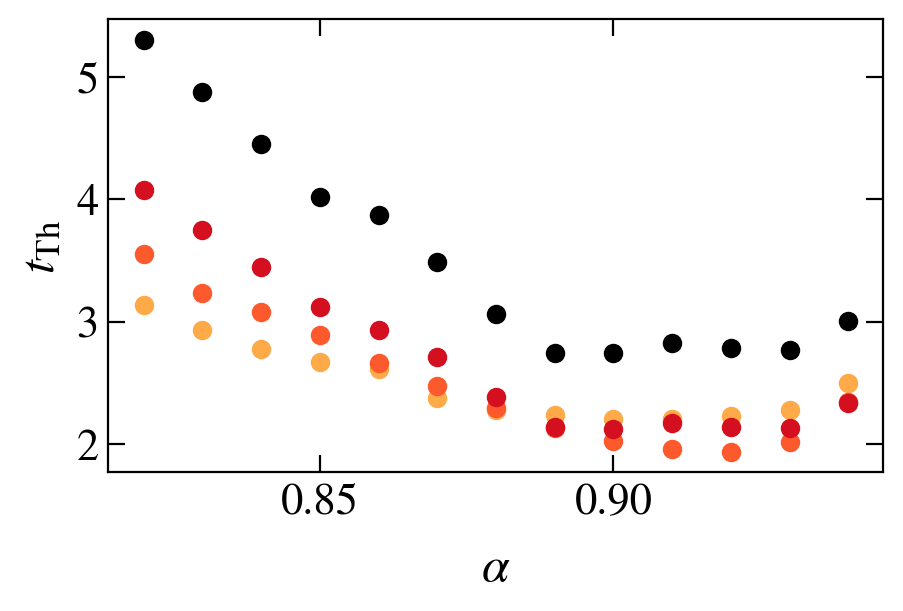

In [28]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,3), dpi = 200)#, sharex=True, sharey=False)


alfas = [0.8, 0.85, 0.9, 0.94]
alfas = np.arange(0.82, 0.95, 0.01)
norm = matplotlib.colors.Normalize(
        vmin=min(alfas),
        vmax=max(alfas))
s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])
# ------------------------------------------------------------ Quantum Sun Model
L_total=16
N=3
J=1
alfa=1.0
h=1.0
w=0.5
zeta=0.2
gamma=1.0
ini_ave=1
L = L_total - N
scaled_disorder=0
alfa_c = 0.73

folder = f'/Users/rafal.swietek/Projects/CODES/QHamSolver/QuantumSun/Jupyter_Python/thouless time/'
sizes = np.arange(8, 17,2)

xi = []
exp = []
all_taus = []
z = np.zeros( (alfas.size, sizes.size-2) )
for iia, alfa in enumerate(alfas):
    col = s_m.to_rgba(alfa)
    tau = np.zeros((sizes.size))
    for iiL, Ltot in enumerate(sizes):
        L = Ltot - N
        name_out = folder + f'_L={L},N={N},J={J},w={w},ini_ave={ini_ave}.hdf5'
        if exists(name_out):
            with h5py.File(name_out, "r") as file:
                alfa_vals  = np.array(file.get('interaction'))
                idx = np.argmin(np.abs(alfa_vals - alfa))
                tH         = np.array(file.get('heisenberg time'))[idx]
                tH_typ     = np.array(file.get('typical heisenberg time'))[idx]
                tau[iiL]  = np.array(file.get('thouless time'))[idx] * tH_typ
        else:
            print(name_out)

    # axis.scatter(sizes, tau / sizes**2, color=col)
    pars, pconv = fit(exp_fit,
                            xdata = sizes[2:],
                            ydata = tau[2:])
    xi.append(pars[0])

    pars, pconv = fit(power_law,
                        xdata = sizes[2:],
                        ydata = tau[2:])
    exp.append(pars[0])
    
    a = np.diff( np.log(tau) ) / np.diff( np.log(sizes - N) )
    z[iia] = (a[1:] + a[:-1])/2
    
axis.scatter(alfas, exp, color='k')

norm = matplotlib.colors.Normalize(
    vmin=min(sizes),
    vmax=max(sizes))
# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.2, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)
s_m_L = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m_L.set_array([])

z = np.transpose(z)
for iiL, L_total in enumerate( sizes[1:-1] ):
    col = s_m_L.to_rgba(L_total)
    axis.scatter(alfas, z[iiL], color=col)  
    
fig_help.set_plot_elements(axis, ylabel=r"$t_{\rm Th}$", xlabel=r"$\alpha$", font_size=16, set_legend=0, xscale='linear', yscale='linear')

for L in np.arange(12, 19, 2):
    print(binom(L, L//2)**(-0.25))

No handles with labels found to put in legend.
No handles with labels found to put in legend.


1.6451612903225805
2.550387596899225


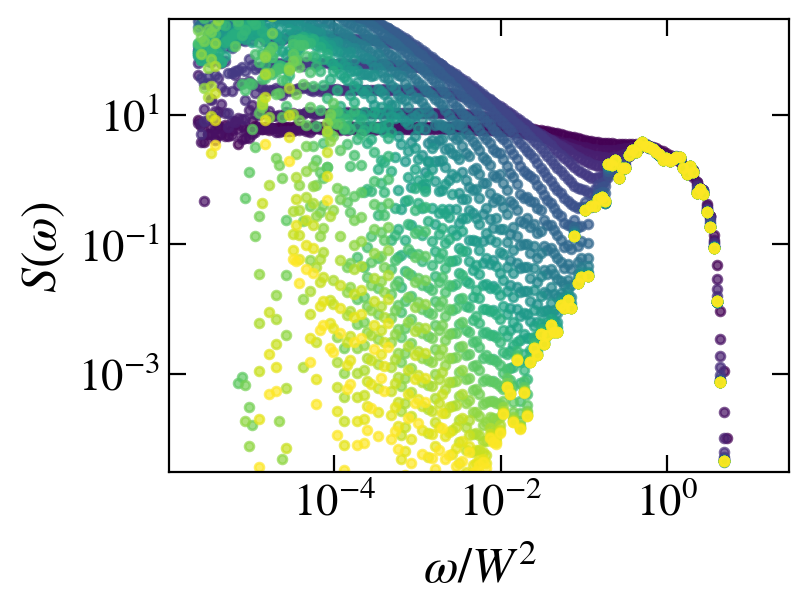

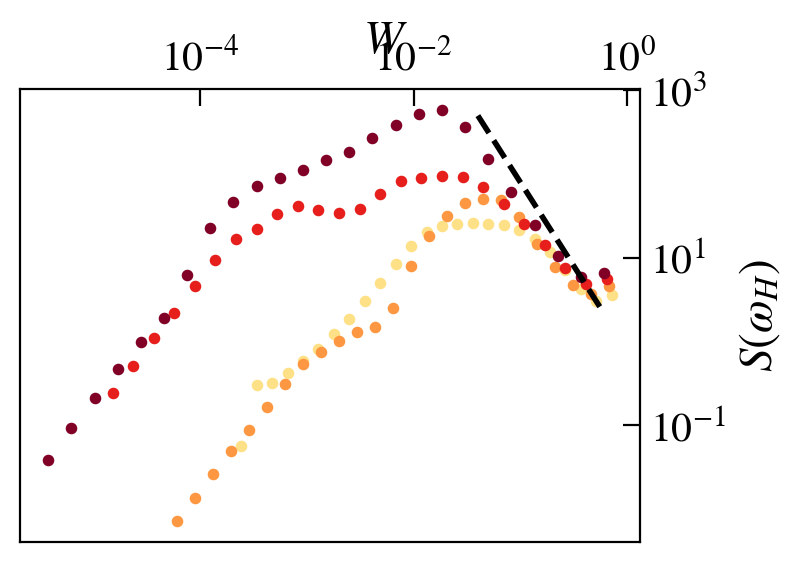

In [25]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0

BC = 0

prefix = '../results_fgr/disorder/OBC/Spectrals_SzSz/' if BC else '../results_fgr/disorder/PBC/Spectrals_SzSz/'
# prefix = '../results/disorder/OBC/Spectrals_energy_current/'
# prefix = '../results_fgr/disorder/ABC/Spectrals_kinetic/'
# prefix = '../results/disorder/OBC/Spectrals_SzSz/' if BC else '../results/disorder/PBC/Spectrals_SzSz/'
hz = 1 if BC else 0

sizes = np.arange(12, 19, 2)

DIM = 1

integrated = 0


fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200, sharex=True, sharey=False)
fig2, inset = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200, sharex=True, sharey=False)
# inset = axis.inset_axes([0.04, 0.04, 0.47, 0.5])

L = 16
eps = 0.5

wx_vals = np.arange(0.04, 1.01, 0.04)
# wx_vals = np.arange(0.2, 0.52, 0.05)


norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.2, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m_L = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m_L.set_array([])

norm = matplotlib.colors.Normalize(
        vmin=min(wx_vals),
        vmax=max(wx_vals))
s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])


wx = 0.2

for Lx in sizes:
    dim = 2**Lx
    f_w_height = np.zeros(wx_vals.shape)
    thouless = np.zeros(wx_vals.shape)
    for iiL, wx in enumerate(wx_vals):
        col = s_m.to_rgba(wx)
        
        omegas = np.nan
        spec_fun = np.nan
        name = prefix + info_dis(L=Lx, J1=J, delta1=0.55, w=wx, hz=hz) + '.hdf5'
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energy_density'))
                idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
                DOS = np.array(file.get('DOS'))[idx]
                wH = np.array(file.get('wH'))[0]
                
                G = 1#dim**(1-2*w) * L**2
                spec_fun = np.array(file.get('spec_fun'))[idx] * DOS * G
                omegas = np.array(file.get('omegas'))[1:]# / G
                
                omegas = omegas[~np.isnan(spec_fun)]
                spec_fun = spec_fun[~np.isnan(spec_fun)]
                
                idx_wH1 = np.argmin(np.abs( omegas - wH/2 ))
                idx_wH2 = np.argmin(np.abs( omegas - 2*wH ))
                f_w_height[iiL] = np.mean(spec_fun[idx_wH1 : idx_wH2])
                
                realis = np.array(file.get('realisations'))
                
                yy = integrate.cumulative_trapezoid(spec_fun, omegas)
                yy = (yy - yy[0]) / (yy[-1] - yy[0])
                thouless[iiL] = omegas[np.argmin( np.abs(yy - 0.5) )]
                if Lx == 18:
                    if integrated:
                        
                        axis.scatter(omegas[1:] / wx**2., yy, color=col, alpha=0.7, s=10)
                        # print(yy)
                    else:
                        axis.scatter(omegas, spec_fun, color=col, alpha=0.7, s=10)
        else:
            print(name)

    inset.scatter(dim**(-wx_vals), f_w_height * Lx**0, color=s_m_L.to_rgba(Lx), s=10)
    # inset.scatter(wx_vals, thouless * Lx**0, color=s_m_L.to_rgba(Lx), s=10, marker='s', facecolor='None')
    
    
fig_help.set_plot_elements(axis, ylabel=r"$S(\omega)$", xlabel=r"$\omega/W^2$", font_size=16, set_legend=1, xscale='log', yscale='linear' if integrated else 'log')
fig_help.set_plot_elements(inset, ylabel=r"$S(\omega_H)$", xlabel=r"$W$", font_size=15, set_legend=1, xscale='log', yscale='log')

if not integrated:
    z = np.linspace(0.04, 0.6, 100)
    # axis.plot(z, 0.02/z, ls=':', color='k', lw=2)
    inset.plot(z, 0.8/z**2, ls='--', color='k', lw=2)
    axis.set_ylim(3e-5, 3e2)


inset.xaxis.set_label_coords(0.59, 1.08)

inset.xaxis.set_ticks_position('top')
inset.xaxis.set_label_position('top')
inset.yaxis.set_ticks_position('right')
inset.yaxis.set_label_position('right')


fig.subplots_adjust(wspace = 0.02, hspace=0.02)

print(2.55 / 1.55)
print(1.645 / 0.645)

No handles with labels found to put in legend.
No handles with labels found to put in legend.


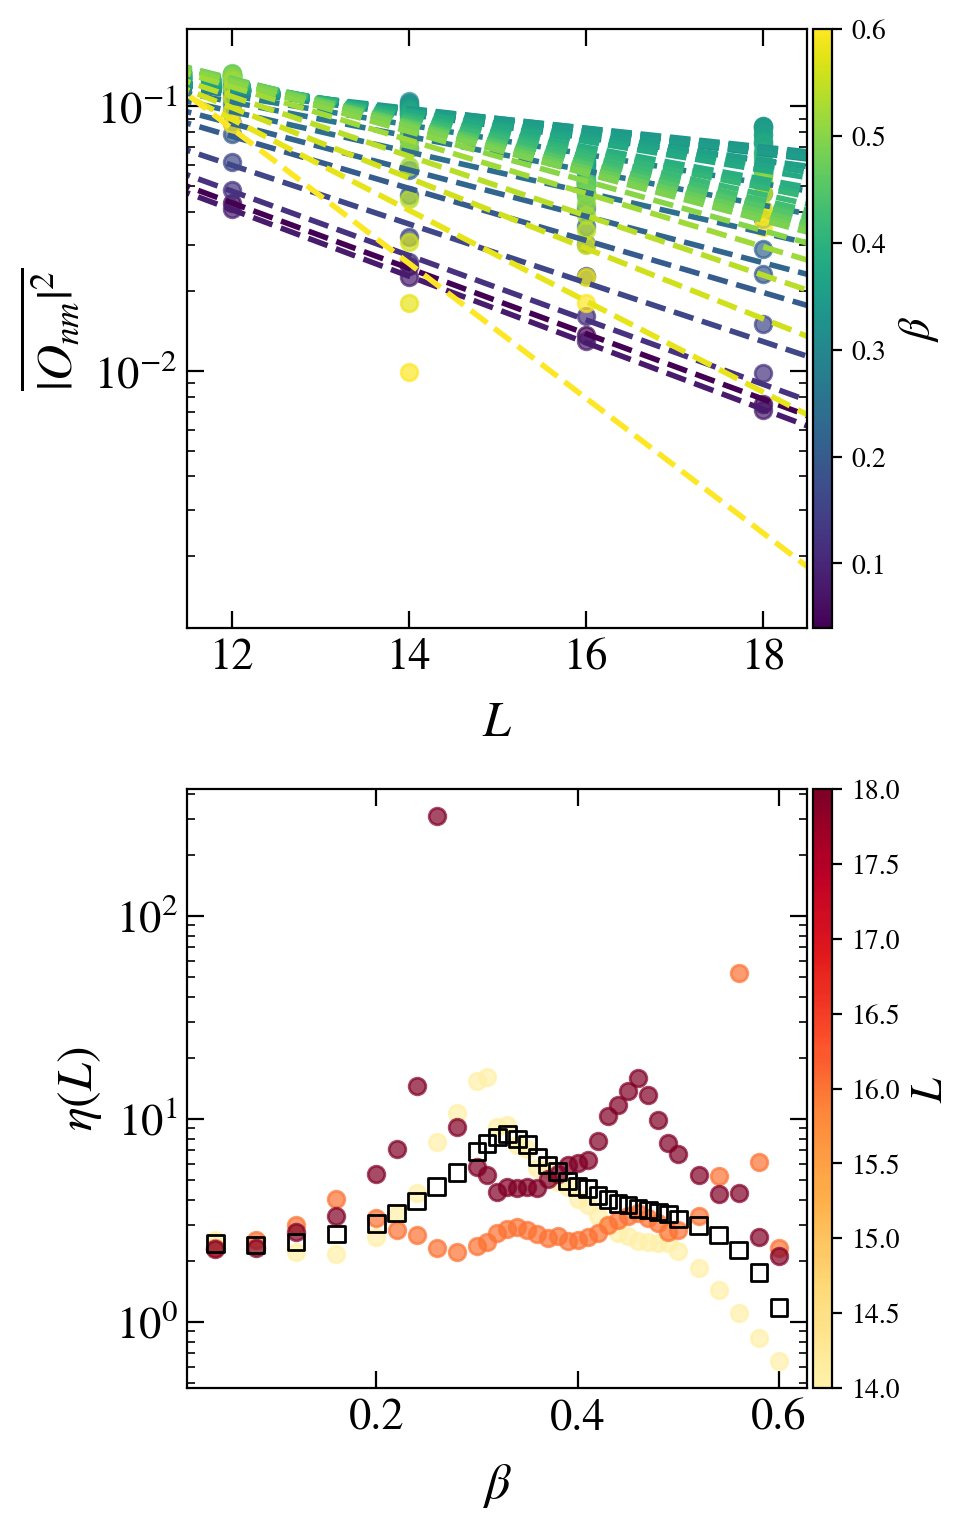

In [342]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0

BC = 0

prefix = '../results_fgr/disorder/OBC/Spectrals_SzSz/' if BC else '../results_fgr/disorder/PBC/Spectrals_SzSz/'
hz = 0

sizes = np.arange(12, 19, 2)

DIM = 1
fig, axis = plt.subplots( nrows=2, ncols=1, figsize=(4,9), dpi = 200)


r_idx = 5
corr = 0
gx = 1.5
window = 40

L = 15
eps = 0.5

def exp_fit_kurwa(x, a, xi):
    """Exponential function to fit and find decay rate"""
    return a * 2**(-x * xi)
    # return 1 - 1 / (1 + a * 2**(-x * xi))

wx_vals = np.arange(0.04, 0.51, 0.04) if BC else np.sort( np.array([*np.arange(0.04, 0.61, 0.04), *np.arange(0.22, 0.61, 0.04), *np.arange(0.31, 0.51, 0.02)]) )

norm = matplotlib.colors.Normalize(
        vmin=min(wx_vals),
        vmax=max(wx_vals))
s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])

etas = []
etas_fit = []
for ibsifusdf, wx in enumerate(wx_vals):
    col = s_m.to_rgba(wx)
    
    spec_fun_at_wh = np.zeros(sizes.shape)
    realis = np.zeros(sizes.shape)
    # ------------------------------------------------------------ ROZENZWEIG-PORTER
    for iiL, L in enumerate(sizes):
        dim = int( binom(L, L//2) )
        counter = 0
        r = 0#np.zeros((45))
        
        name = prefix + info_dis(L=L, J1=J, delta1=0.55, w=wx, hz=hz) + '.hdf5'
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energy_density'))
                idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
                DOS = np.array(file.get('DOS'))[idx]
                wH = np.array(file.get('wH'))[0]
                
                spec_fun = np.array(file.get('spec_fun'))[idx]
                omegas = np.array(file.get('omegas'))[1:]
                realis[iiL] = np.array(file.get('realisations'))
                
                idx_wH1 = np.argmin(np.abs( omegas - wH/10 ))
                idx_wH2 = np.argmin(np.abs( omegas - wH/2 ))
                spec_fun_at_wh[iiL] = np.mean( np.sqrt(spec_fun[idx_wH1 : idx_wH2]) )
        else:
            print(name)
    
    # print(wx, realis, gap_ratio)
    yy = spec_fun_at_wh
    # print(gx, sizes, yy)
    parsolo, pconv, fit_info, msg, _ = fit(exp_fit_kurwa,
                    xdata = sizes,
                    ydata = yy,
                    full_output=True, maxfev=10000)
    A = parsolo[0]
    eta_fit = 1 / parsolo[1]
    if eta_fit > 1e6:
        eta_fit = np.nan
    etas_fit.append(eta_fit)
    # if (iig == 0 and gx > 1.0) or (iig and gx < 4):
    z = np.linspace(min(sizes)-1, max(sizes)+1, 1000)
    axis[0].plot(z, exp_fit_kurwa(z, *parsolo), color=col, ls='--', lw=2)
    axis[0].scatter(sizes, yy, color=col, alpha=0.7)
    
    eta = 1 / (np.diff( np.log(spec_fun_at_wh) ) / np.diff(sizes) / np.log(2))
    etas.append(eta)
    
cbar_ax = axis[0].inset_axes([1.01, 0.0, 0.03, 1])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'vertical')
cbar.set_label(r"$\beta$", fontsize=16)
# cbar_ax.xaxis.set_ticks_position('top')
# cbar_ax.xaxis.set_label_position('top')

etas_fit = np.array(etas_fit)
etas = np.transpose(np.array(etas))

norm = matplotlib.colors.Normalize(vmin=min(sizes[1:]), vmax=max(sizes[1:]) )

# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])
for iiL, L in enumerate(sizes[1:]):
    col = s_m.to_rgba(L)
    axis[1].scatter(wx_vals, np.abs(etas[iiL]), color=col, marker='o', facecolor=col, alpha=0.7)  

axis[1].scatter(wx_vals, np.abs(etas_fit), color='k', marker='s', facecolor='None')


axis[0].set_xlim(min(sizes)-0.5, max(sizes)+0.5)

cbar_ax = axis[1].inset_axes([1.01, 0.0, 0.03, 1])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'vertical')
cbar.set_label(r"$L$", fontsize=16)

# ax.set_ylim(0, 1.05)

# z = np.linspace(1.0, 3.01, 1000)
# ax.plot(z, 2/np.abs(2 - z), ls='-.', color='blue')
# ax.set_ylim(1, 3e2)
# z = np.linspace(0.5, 1.0, 1000)
# ax.plot(z, [1]*z.size, ls='-.', color='blue')
# # ax[1].scatter(gamma_vals, 1/(etas_NE / np.log(2)), color='red', marker='s', facecolor='None')

fig_help.set_plot_elements(axis[0], ylabel=r"$\overline{|O_{nm}|^2}$", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='log')
# fig_help.set_plot_elements(axis[1], ylabel=r"$\bar{r} - r_{\rm PE}$", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis[1], ylabel=r"$\eta(L)$", xlabel=r"$\beta$", font_size=16, set_legend=1, xscale='linear', yscale='log')


fig.subplots_adjust(wspace = 0.27, hspace=0.27)

In [357]:
print(923**(-0.92) - 924**(-0.92))

1.862726524227542e-06


## TIME EVOLUTION

No handles with labels found to put in legend.


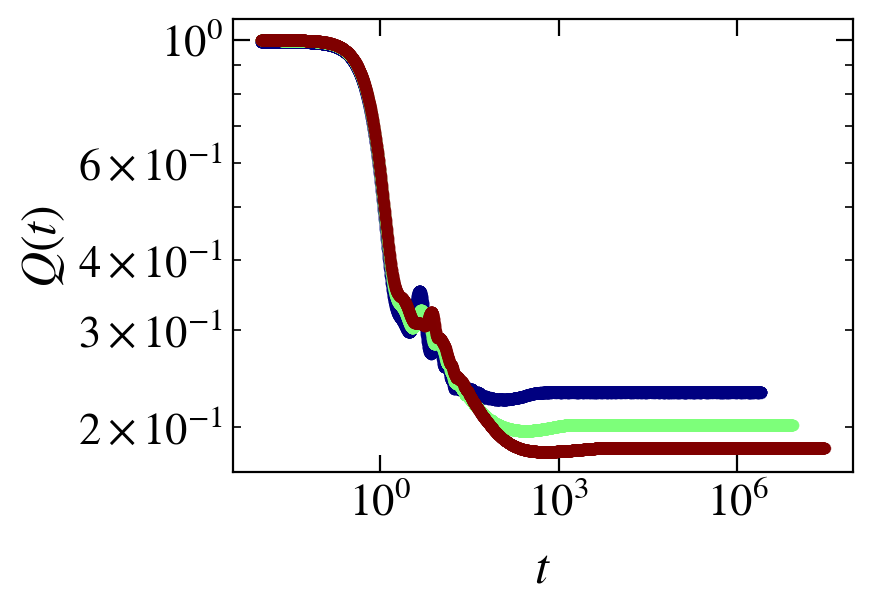

In [269]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'

BC = 0
ADD_CURRENT = 1

prefix = '../results_fgr/disorder/OBC/Spectrals_SzSz/' if BC else '../results_fgr/disorder/PBC/Spectrals_SzSz/'
# prefix = '../results/disorder/OBC/Spectrals_energy_current/'
if ADD_CURRENT: prefix = '../results_fgr2/disorder/PBC/Spectrals_SzSz/'
hz = 1 if BC else 0

sizes = np.arange(10, 16, 2)

DIM = 1
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200, sharex=True, sharey=False)

L = 15
eps = 0.5

wx_vals = np.arange(0.02, 0.81, 0.02)



norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])


wx = 0.2
for iiL, L in enumerate(sizes):
    dim = int( binom(L, L//2) )

    col = s_m.to_rgba(L)
    
    omegas = np.nan
    spec_fun = np.nan
    name = prefix + info_dis(L=L, J1=J, delta1=0.55, w=wx, hz=hz) + '.hdf5'
    if exists(name):
        with h5py.File(name, "r") as file:
            Ex = np.array(file.get('energy_density'))
            idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
            DOS = np.array(file.get('DOS'))[idx]
            
            G = 1#dim**(1-2*w) * L**2
            spec_fun = np.array(file.get('quench'))
            omegas = np.array(file.get('times')) / G
            
            realis = np.array(file.get('realisations'))
            
            # DE = np.array(file.get('diagonal ensemble abs'))
            # axis.axhline(y=DE, color=col, ls='-')
            
            # MC = np.array(file.get('microcanonical ensemble abs'))
            # axis.axhline(y=MC, color=col, ls='--')
    else:
        print(name)
    
    axis.scatter(omegas, spec_fun, color=col, alpha=0.7, s=10)
    
    
fig_help.set_plot_elements(axis, ylabel=r"$Q(t)$", xlabel=r"$t$", font_size=16, set_legend=1, xscale='log', yscale='log')

# axis.set_ylim(1e-3, 5e1)

fig.subplots_adjust(wspace = 0.02, hspace=0.02)

No handles with labels found to put in legend.
No handles with labels found to put in legend.


0.05 [0.19050617 0.10147535 0.0915793 ]
0.1 [0.18114847 0.10574655 0.08051417]
0.15000000000000002 [0.17558601 0.08491622 0.08960133]
0.2 [0.15993593 0.10128724 0.0813593 ]
0.25 [0.14882555 0.10740478 0.09294244]
0.3 [0.10810523 0.12353008 0.09052311]
0.35000000000000003 [0.09405878 0.12399081 0.09237815]
0.4 [0.09695782 0.14832232 0.09321462]
0.45 [0.09073152 0.1381472  0.03943431]
0.5 [0.10725607 0.15448515 0.1062437 ]


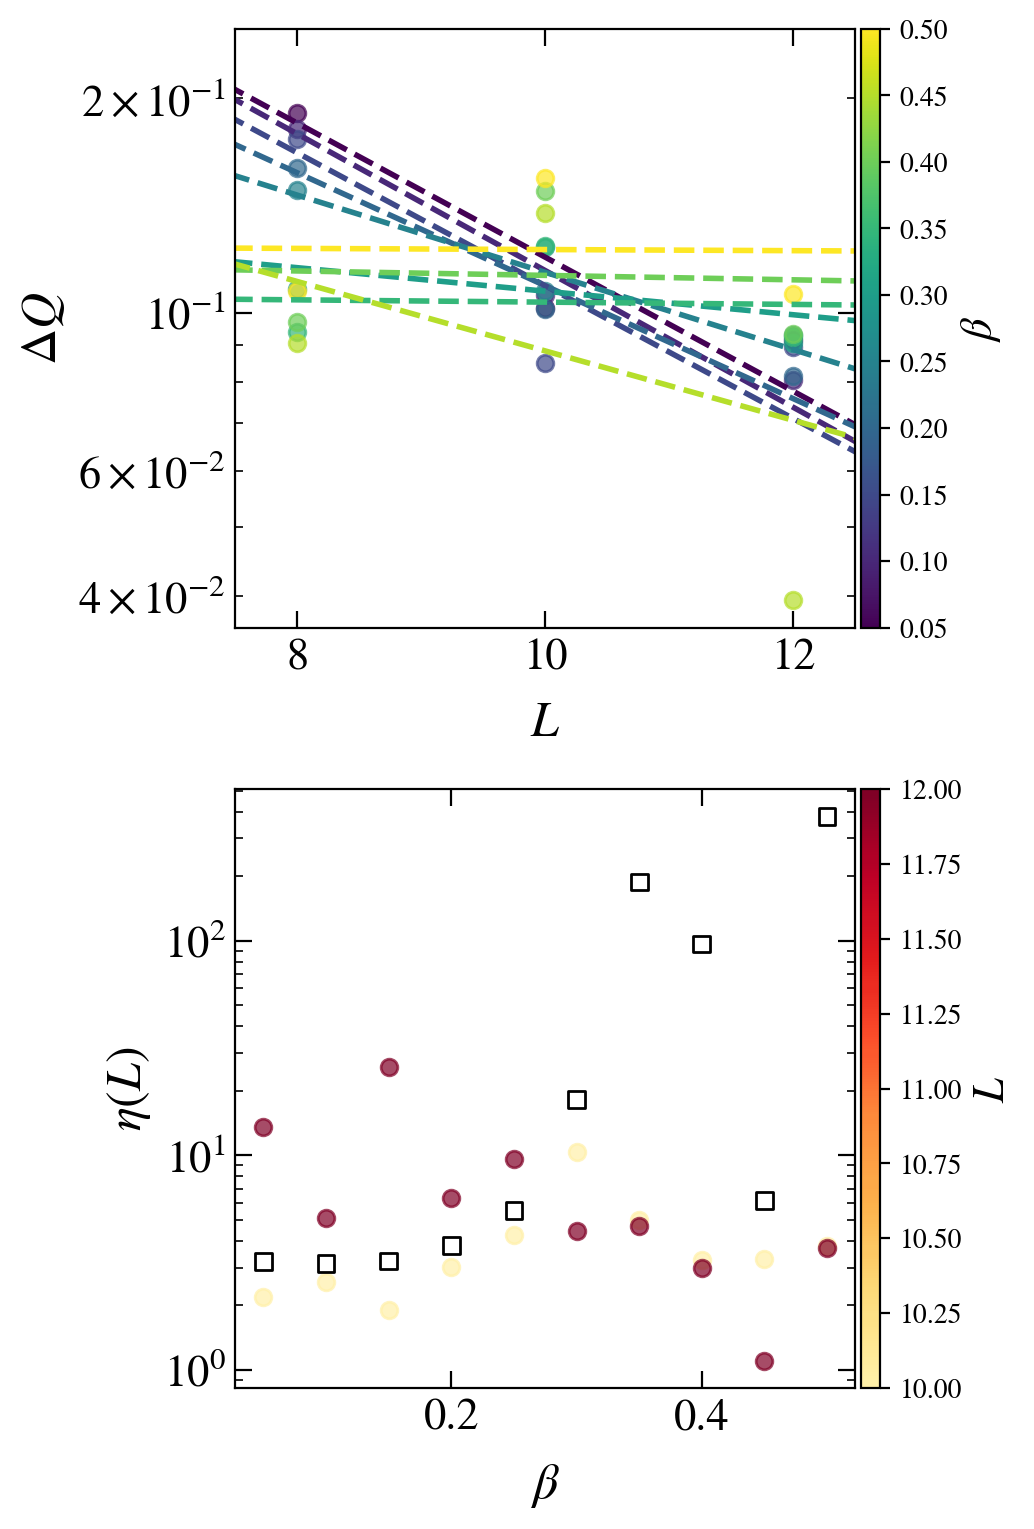

In [157]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0

BC = 0

prefix = '../results/disorder/OBC/Spectrals_SzSz/' if BC else '../results/disorder/PBC/Spectrals_SzSz/'
prefix = '../results_fgr/disorder/ABC/Spectrals_kinetic/'
hz = 1 if BC else 0

sizes = np.arange(8, 13, 2)

DIM = 1
fig, axis = plt.subplots( nrows=2, ncols=1, figsize=(4,9), dpi = 200)


r_idx = 5
corr = 0
gx = 1.5
window = 40

L = 15
eps = 0.5

def exp_fit_kurwa(x, a, xi):
    """Exponential function to fit and find decay rate"""
    return a * 2**(-x * xi)
    # return 1 - 1 / (1 + a * 2**(-x * xi))

wx_vals = np.arange(0.2, 0.51, 0.02) if BC else np.sort( np.array([*np.arange(0.04, 0.61, 0.04), *np.arange(0.22, 0.61, 0.04), *np.arange(0.31, 0.51, 0.02)]) )
wx_vals = np.arange(0.05, 0.51, 0.05)

norm = matplotlib.colors.Normalize(
        vmin=min(wx_vals),
        vmax=max(wx_vals))
s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])

etas = []
etas_fit = []
for ibsifusdf, wx in enumerate(wx_vals):
    col = s_m.to_rgba(wx)
    
    deltaQ = np.zeros(sizes.shape)
    realis = np.zeros(sizes.shape)
    # ------------------------------------------------------------ ROZENZWEIG-PORTER
    for iiL, L in enumerate(sizes):
        dim = int( binom(L, L//2) )
        counter = 0
        r = 0#np.zeros((45))
        
        name = prefix + info_dis(L=L, J1=J, delta1=0.55, w=wx, hz=hz) + '.hdf5'
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energy_density'))
                idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
                DOS = np.array(file.get('DOS'))[idx]
                wH = np.array(file.get('wH'))[0]
                
                deltaQ[iiL] = np.array(file.get('deltaQ'))
        else:
            print(name)
    print(wx, deltaQ)
    # print(wx, realis, gap_ratio)
    yy = deltaQ
    # print(gx, sizes, yy)
    parsolo, pconv, fit_info, msg, _ = fit(exp_fit_kurwa,
                    xdata = sizes,
                    ydata = yy,
                    full_output=True, maxfev=10000)
    A = parsolo[0]
    eta_fit = 1 / parsolo[1]
    if eta_fit > 1e6:
        eta_fit = np.nan
    etas_fit.append(eta_fit)
    # if (iig == 0 and gx > 1.0) or (iig and gx < 4):
    z = np.linspace(min(sizes)-1, max(sizes)+1, 1000)
    axis[0].plot(z, exp_fit_kurwa(z, *parsolo), color=col, ls='--', lw=2)
    axis[0].scatter(sizes, yy, color=col, alpha=0.7)
    
    eta = 1 / (np.diff( np.log(deltaQ) ) / np.diff(sizes) / np.log(2))
    etas.append(eta)
    
cbar_ax = axis[0].inset_axes([1.01, 0.0, 0.03, 1])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'vertical')
cbar.set_label(r"$\beta$", fontsize=16)
# cbar_ax.xaxis.set_ticks_position('top')
# cbar_ax.xaxis.set_label_position('top')

etas_fit = np.array(etas_fit)
etas = np.transpose(np.array(etas))

norm = matplotlib.colors.Normalize(vmin=min(sizes[1:]), vmax=max(sizes[1:]) )

# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])
for iiL, L in enumerate(sizes[1:]):
    col = s_m.to_rgba(L)
    axis[1].scatter(wx_vals, np.abs(etas[iiL]), color=col, marker='o', facecolor=col, alpha=0.7)  

axis[1].scatter(wx_vals, np.abs(etas_fit), color='k', marker='s', facecolor='None')


axis[0].set_xlim(min(sizes)-0.5, max(sizes)+0.5)

cbar_ax = axis[1].inset_axes([1.01, 0.0, 0.03, 1])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'vertical')
cbar.set_label(r"$L$", fontsize=16)

# ax.set_ylim(0, 1.05)

# z = np.linspace(1.0, 3.01, 1000)
# ax.plot(z, 2/np.abs(2 - z), ls='-.', color='blue')
# ax.set_ylim(1, 3e2)
# z = np.linspace(0.5, 1.0, 1000)
# ax.plot(z, [1]*z.size, ls='-.', color='blue')
# # ax[1].scatter(gamma_vals, 1/(etas_NE / np.log(2)), color='red', marker='s', facecolor='None')

fig_help.set_plot_elements(axis[0], ylabel=r"$\Delta Q$", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='log')
# fig_help.set_plot_elements(axis[1], ylabel=r"$\bar{r} - r_{\rm PE}$", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis[1], ylabel=r"$\eta(L)$", xlabel=r"$\beta$", font_size=16, set_legend=1, xscale='linear', yscale='log')


fig.subplots_adjust(wspace = 0.27, hspace=0.27)